# SENDAs Agreement 1 Update 2010-2022 (Prediction, step 2.4, DeepSurv-SHAP-informed models [sensitivity analysis])

Quarto-specific YAML/options are preserved in the first raw cell. Setup cells handle project-root detection, loading `pred21_ndp_2026_03_26.Rdata`, plot sizing, and optional `renv` repair.

This notebook mirrors `prediction22_converted_mod` but drives variable selection from the **DeepSurv** SHAP importance table (`ds63`) via the pre-specified fixed rule (`run_selection()`), as a sensitivity analysis to the primary XGBoost-SHAP-informed models.

In [1]:
# --- Force self-contained conda-env R setup ---
# Positron's ark kernel bypasses conda activation, so set env vars and library paths here.
conda_user_lib <- "C:/Users/homes/OneDrive/Escritorio/cons2025/.conda-env/Lib/R/user-library"
conda_system_lib <- "C:/Users/homes/OneDrive/Escritorio/cons2025/.conda-env/Lib/R/library"
dir.create(conda_user_lib, showWarnings = FALSE, recursive = TRUE)
Sys.setenv(
  R_LIBS_USER = conda_user_lib,
  RENV_CONFIG_AUTOLOADER_ENABLED = "FALSE",
  RENV_CONFIG_SANDBOX_ENABLED = "FALSE"
)
.libPaths(c(conda_user_lib, conda_system_lib))

.t0 <- proc.time()

# --- Setup: project root, data load, plot size/resolution, and renv activation ---

# adjust plot size and resolution for high-quality output

# --- Load pred21_ndp_2026_03_26.Rdata (simple, project-root aware, no functions) --- 
# 1) Locate the file anywhere under the project root (current WD with a trailing "/cons" trimmed)
project_root <- sub("(/)?cons/?$", "", normalizePath(getwd(), winslash = "/", mustWork = FALSE))
fname        <- "pred21_ndp_2026_03_26.Rdata"
hits <- list.files(project_root, pattern = paste0("^", fname, "$"),
                   recursive = TRUE, full.names = TRUE, ignore.case = TRUE)

# If not found and path contains "Documents\GitHub\", try the data folder
if (!length(hits) && grepl("Documents[/\\\\]GitHub", project_root)) {
  alt_data_dir <- file.path(Sys.getenv("USERPROFILE"), "Documents/GitHub/data")
  message("File not found in project root. Trying alternative data directory: ", alt_data_dir)
  hits <- list.files(alt_data_dir, pattern = paste0("^", fname, "$"),
                     recursive = TRUE, full.names = TRUE, ignore.case = TRUE)
}
# Extra fallback: OneDrive Desktop data folder
if (!length(hits)) {
  alt_data_dir <- file.path(
    Sys.getenv("USERPROFILE"),
    "OneDrive/Escritorio/data/20241015_out"
  )
  message("File not found yet. Trying alternative data directory: ", alt_data_dir)
  hits <- list.files(
    alt_data_dir,
    pattern = paste0("^", fname, "$"),
    recursive = TRUE,
    full.names = TRUE,
    ignore.case = TRUE
  )
}

if (!length(hits)) {
  stop("File not found: ", fname, 
       "\nSearched under: ", project_root,
       "\nAnd under: ", file.path(Sys.getenv("USERPROFILE"), "Documents/GitHub/data"))
}
path <- hits[1]  # take first match
message("Loading: ", path)

# 2) Load into a dedicated environment (keeps .GlobalEnv clean)
env_pred <- new.env(parent = emptyenv())
loaded_objects <- load(path, envir = env_pred)
message("Loaded ", length(loaded_objects), " object(s): ", paste(loaded_objects, collapse = ", "))

# 3) Quick sanity check for each loaded object
for (obj_name in loaded_objects) {
  obj <- get(obj_name, envir = env_pred)
  message("\n--- ", obj_name, " ---")
  if (is.data.frame(obj)) {
    message("Rows: ", nrow(obj), " | Cols: ", ncol(obj))
  } else {
    message("Class: ", paste(class(obj), collapse = ", "), " | Length/Size: ", length(obj))
  }
  # print(str(obj))
}

# 4) Extract all loaded objects to global environment
for (obj_name in loaded_objects) {
  assign(obj_name, get(obj_name, envir = env_pred), envir = .GlobalEnv)
}

# Clean up temporary environment
rm(env_pred)

options(jupyter.max_output_size = Inf)
options(repr.plot.width = 16 * 1.5, repr.plot.height = 12 * 1.5)
options(repr.plot.res = 300)

# --- Environment policy ---
# Use the already-created .conda-env. Do not activate renv or restore packages here.
Sys.setenv(
  RENV_CONFIG_AUTOLOADER_ENABLED = "FALSE",
  RENV_CONFIG_SANDBOX_ENABLED = "FALSE",
  CONS2025_ENV_SETUP = Sys.getenv("CONS2025_ENV_SETUP", unset = "skip")
)
message("Using existing R library paths:\n", paste(.libPaths(), collapse = "\n"))

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "setup-data-load", .elapsed["elapsed"], .elapsed["elapsed"]/60))


File not found yet. Trying alternative data directory: C:\Users\homes/OneDrive/Escritorio/data/20241015_out
Loading: C:\Users\homes/OneDrive/Escritorio/data/20241015_out/pred21_ndp_2026_03_26.Rdata


by .GlobalEnv when processing object ‘plot_cloglog_comb’


Loaded 281 object(s): infectious_set, find_latest_file, cal_readmit2, mode_pick_int, cal_readmit3, python_columns, nm, cal_death_full_ici, collapse_first_sub_used_other, .cph_boot_extract_ibs, char_variables, secret_file_path, cols_to_exclude, total_cpus, decrypt_column, n1b_cases, api_key, plot_cloglog_comb, encrypt_column, renviron_path, .mi_cv_build_level_mapping, subkey_to_label, hits, missing_pct, target_cols, py_split, aicc_death_upd2, dummy_formula, apply_ordered_mappings, t_grid, cif_d_before, m4_cases, calibrate_cph_grouped, m3_runs, violations, ph_test_death, root, ci_first, cal_readmit, existing_lines, obj, .Random.seed, n_before, results_readmit2_ibs, formula_readmit_updated2, decrypt_chr, DUMMY_REFERENCE, .mi_cv_normalize_call_name, pairs, key_exists, encrypt_chr, sum_dates_polars, normalize_txt, find_python_rel, .mi_cv_collect_strata_term_labels, time_before_dedup2, numerical_vars2, lab_first_index, print.cph_grouped_calibration, evaluate_mi_cv_safe_strata, var2_table, ci

In [2]:
#| label: load-rdata
#| results: "hold"

.t0 <- proc.time()
#:#:#:#:#:##:#:#:#:#:##:#:#:#:#:#
#:#:#:#:#:#HELPERS#:#:#:#:#:##:
safe_renv_restore <- function(lockfile, exclude = c("polars", "nlme")) {
  options(
    pkgType = "binary",
    install.packages.compile.from.source = "never",
    renv.config.install.transactional = FALSE,
    renv.config.install.jobs = 1
  )
  Sys.setenv(
    R_COMPILE_AND_INSTALL_PACKAGES = "never",
    RENV_CONFIG_INSTALL_TRANSACTIONAL = "FALSE"
  )
  tryCatch(
    {
      renv::restore(
        lockfile = lockfile,
        exclude = exclude,
        clean = FALSE,
        prompt = FALSE,
        transactional = FALSE
      )
    },
    error = function(e) {
      message("renv restore failed, continuing anyway.")
      message("Error: ", conditionMessage(e))
      invisible(FALSE)
    }
  )
}
find_renv_lockfile <- function() {
  candidates <- unique(c(
    file.path(getwd(), "renv.lock"),
    file.path(dirname(getwd()), "renv.lock"),
    "C:/Users/homes/OneDrive/Escritorio/renv.lock"
  ))
  hits <- candidates[file.exists(candidates)]
  if (length(hits)) hits[[1]] else NA_character_
}

load_custom_renv_original <- function() {
  wd <- getwd()
  wd_lower <- tolower(wd)
  if (grepl("mi unidad", wd_lower) || grepl("my drive", wd_lower)) {
    message("Rule 1: Path is inside Google Drive. Keeping current environment.")
  } else if (grepl("cons", wd_lower)) {
    lockfile <- find_renv_lockfile()
    if (!is.na(lockfile)) {
      message("Rule 3: Found renv.lock at ", normalizePath(lockfile, winslash = "/"), ". Restoring environment...")
      safe_renv_restore(lockfile, exclude = c("polars", "nlme"))
    } else {
      message("Rule 3: No renv.lock found. No restore performed.")
    }
  } else {
    message("Default: Path does not match rules. Keeping current environment.")
  }
}
generate_conda_specs_from_renv <- function(
  lockfile = find_renv_lockfile(),
  output = "conda-r-specs.txt"
) {
  if (!file.exists(lockfile)) {
    stop("renv.lock not found: ", lockfile)
  }
  txt <- paste(readLines(lockfile, encoding = "UTF-8-BOM", warn = FALSE), collapse = "\n")
  lock <- jsonlite::fromJSON(txt, simplifyVector = FALSE)
  pkgs <- lock[["Packages"]]
  specs <- vapply(names(pkgs), function(name) {
    rec <- pkgs[[name]]
    ver <- rec[["Version"]]
    source <- rec[["Source"]]
    if (length(ver) != 1 || is.na(ver) || !nzchar(ver)) return(NA_character_)
    if (length(source) == 1 && identical(source, "GitHub")) return(NA_character_)
    paste0("r-", tolower(name), "=", gsub("-", "_", ver))
  }, character(1), USE.NAMES = FALSE)
  specs <- specs[!is.na(specs)]
  specs <- specs[!grepl(
    "^r-(r|base|utils|stats|graphics|grdevices|methods|datasets|compiler|tools|parallel|splines|grid)=",
    specs
  )]
  writeLines(sort(unique(specs)), output)
  message("Wrote conda specs to: ", normalizePath(output, winslash = "/", mustWork = FALSE))
  message("Then run in PowerShell:")
  message("conda install -p .conda-env -c conda-forge --file ", output)
  invisible(output)
}
choose_environment_loader <- function() {
  mode <- tolower(Sys.getenv("CONS2025_ENV_SETUP", unset = if (interactive()) "menu" else "skip"))
  if (mode == "menu" && !interactive()) mode <- "skip"
  if (mode %in% c("renv", "restore", "1")) {
    message("Environment setup mode: renv restore.")
    return(load_custom_renv_original())
  }
  if (mode %in% c("conda", "conda-specs", "specs", "2")) {
    message("Environment setup mode: generate conda specs.")
    return(generate_conda_specs_from_renv())
  }
  if (mode %in% c("skip", "none", "3")) {
    message("Environment setup mode: skip. Set CONS2025_ENV_SETUP=renv or conda-specs to override.")
    return(invisible(NULL))
  }
  choice <- utils::menu(
    choices = c(
      "Use original renv restore logic",
      "Generate conda specs from Desktop renv.lock",
      "Skip environment setup"
    ),
    title = "Choose environment setup"
  )
  if (choice == 1) {
    load_custom_renv_original()
  } else if (choice == 2) {
    generate_conda_specs_from_renv()
  } else if (choice == 3) {
    message("Skipping environment setup.")
    invisible(NULL)
  } else {
    message("No valid option selected. Skipping environment setup.")
    invisible(NULL)
  }
}
#:#:#:#:#:##:#:#:#:#:##:#:#:#:#:##:#:#:#:#:#
#:#:#:#:#:##:#:#:#:#:##:#:#:#:#:##:#:#:#:#:#
#:#:#:#:#:#RUN!#:#:#:#:#:##:#:#:#:#:#
choose_environment_loader()

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf(
  "\n[chunk: %s] %.1f sec (%.1f min)\n",
  "env-loader-choice",
  .elapsed["elapsed"],
  .elapsed["elapsed"] / 60
))

Environment setup mode: skip. Set CONS2025_ENV_SETUP=renv or conda-specs to override.

[chunk: env-loader-choice] 0.0 sec (0.0 min)


In [3]:
packageVersion("nlme")
library(nlme)

Warning message:
package ‘nlme’ was built under R version 4.4.3 


In [4]:
#| label: renv-residuals
#| results: "hold"

.t0 <- proc.time()
message("Skipping renv cleanup/status. This notebook uses the existing .conda-env and does not modify package libraries.")
if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "renv-cleanup", .elapsed["elapsed"], .elapsed["elapsed"]/60))

Skipping renv cleanup/status. This notebook uses the existing .conda-env and does not modify package libraries.

[chunk: renv-cleanup] 0.0 sec (0.0 min)


<style type="text/css">
.showopt {
background-color: #004c93; color: #FFFFFF; width: 100px; height: 20px; text-align: center; vertical-align: middle !important; float: right; font-family: sans-serif; border-radius: 8px;
}
.showopt:hover {
background-color: #dfe4f2;
color: #004c93;
}
pre.plot {
background-color: white !important;
}
.tablelines table, .tablelines td, .tablelines th {
border: 1px solid black;
}
.centrado {
text-align: center;
}
.table.center {
margin-left:auto;
margin-right:auto;
}
/* https://vivekjaiskumar.medium.com/css-is-and-not-selector-17c942ec83f :is()*/
/* Applies to outputs that are not code other than R*/
pre {
overflow-x: auto !important;
}
pre code {
word-wrap: normal !important;
white-space: pre !important;
}
/*
pre:not(.sourceCode) {
white-space: nowrap !important;
}
*/
.sourceCode { /* Important gives precedence */
font-size: 10px !important;
line-height: 50% !important;
}
body{ /* Normal */
text-align: justify;
}
.superbigimage{
overflow-y:scroll;
height:350px;
white-space: nowrap;
overflow-x: auto;
width:100%;
}
.superbigimage img{
overflow-y: scroll;
overflow-x: hidden;
}
.message { color:#446C6E; font-family: monospace;font-size: 10px; line-height: 110%; font-weight: bold;}
div.blue { background-color:#e6f0ff; border-radius: 5px; padding: 5px; text-align: justify;}
div.red { background-color:#e6bab1; border-radius: 5px; padding: 5px; text-align: justify;}
.pandoc-table { /* Should add !important; but it seems no necessary */
margin-left:auto; /* To center */
margin-right:auto;
border-collapse: collapse;
table-layout: auto;
font-size: 11px;
overflow-y: auto;
max-height:450px !important;
white-space: nowrap;
overflow-x: auto;
width:450px;
}
.pandoc-table th {/* header */
text-align: center !important;
font-size: 10px;
padding: 0px;
}
.pandoc-table td {
text-align: left !important;
font-size: 9px;
padding: 0px;
}
.pandoc-table caption {
text-align: left !important;
font-size: 11px !important;
}
.center-table {
text-align: left !important;
font-size: 9px;
overflow-y:scroll;
height:450px;
overflow-x: scroll;
}
.controlly{
overflow-y:scroll;
height:350px;
overflow-x: scroll;
}
/*2025-03-07*/
.callout-warning,
.callout-error,
.callout-message {
  font-size: 0.7rem !important;  /* Adjust this value as needed */
}
.alert, .message {
    font-size: 0.7em !important;
}
.alert.alert-warning,
.alert.alert-danger,
.message {
    font-size: 0.7em !important;
}
</style>


<style>
#| label: css-format
h1 {
    color: var(--heading-color);
    font-size: 2rem;
    margin-bottom: 1vh;
}
p {
  font-size: 1.1rem;
  line-height: 1.6rem;
}
a {
  color: var(--primary-color);
  text-decoration: none;
  border-bottom: 3px solid transparent;
  font-weight: bold;
  &:hover, &:focus {
      border-bottom: 3px solid currentColor;
  }
}
section {
  margin: 0 auto;
}
.post-meta {
  font-size: 1rem;
  font-style: italic;
  display: block;
  margin-bottom: 4vh;
  color: var(--secondary-color);
}
nav {
  display: flex;
  justify-content: flex-end;
  padding: 20px 0;
}
/*slider switch css */
.theme-switch-wrapper {
  display: flex;
  align-items: center;
  
  em {
    margin-left: 10px;
    font-size: 1rem;
  }
}
.theme-switch {
  display: inline-block;
  height: 34px;
  position: relative;
  width: 60px;
}
.theme-switch input {
  display:none;
}
.slider {
  background-color: #ccc;
  bottom: 0;
  cursor: pointer;
  left: 0;
  position: absolute;
  right: 0;
  top: 0;
  transition: .4s;
}
.slider:before {
  background-color: #fff;
  bottom: 4px;
  content: "";
  height: 26px;
  left: 4px;
  position: absolute;
  transition: .4s;
  width: 26px;
}
input:checked + .slider {
  background-color: #66bb6a;
}
input:checked + .slider:before {
  transform: translateX(26px);
}
.slider.round {
  border-radius: 34px;
}
.slider.round:before {
  border-radius: 50%;
}
</style>


<style>
.scrollable-content {
  max-height: 350px;
  overflow-y: auto;
}
pre.scrollable-code {
  max-height: 350px;
  overflow-y: auto;
}
.superbigimage {
  overflow-x: scroll;
  white-space: nowrap;
}
.superbigimage img, 
.superbigimage svg {
  max-width: none;
  height: auto;
}
</style>
<br>

# Data Loading and Exploration

## Loading Packages and uniting databases

<div class="scrollable-content">


In [21]:
#| label: options-plot

options(repr.plot.width = 12, repr.plot.height = 8)


In [5]:
#| label: setup
#| results: "hold"
.t0 <- proc.time()

# This notebook should use the existing .conda-env. It must not install packages,
# restore renv, install Rtools, unlock libraries, or launch Docker checks.
Sys.setenv(
  RENV_CONFIG_AUTOLOADER_ENABLED = "FALSE",
  RENV_CONFIG_SANDBOX_ENABLED = "FALSE"
)

if (Sys.info()[["sysname"]] == "Windows" && getRversion() != "4.4.1") {
  stop("Requires R version 4.4.1; Actual: ", getRversion(), call. = FALSE)
}

check_quarto_version <- function(required = "1.7.29", comparator = c("ge", "gt", "le", "lt", "eq")) {
  comparator <- match.arg(comparator)
  if (!requireNamespace("quarto", quietly = TRUE)) {
    warning("Package 'quarto' is not installed; skipping Quarto version check.")
    return(invisible(FALSE))
  }
  current <- package_version(paste(unlist(quarto::quarto_version()), collapse = "."))
  req <- package_version(required)
  ok <- switch(
    comparator,
    ge = current >= req,
    gt = current > req,
    le = current <= req,
    lt = current < req,
    eq = current == req
  )
  if (!ok) {
    stop(sprintf(
      "Quarto version check failed: need %s %s (installed: %s).",
      comparator, required, current
    ), call. = FALSE)
  }
  invisible(TRUE)
}
check_quarto_version("1.7.29", "ge")

local({
  r <- getOption("repos")
  r["CRAN"] <- "https://cran.dcc.uchile.cl/"
  options(repos = r)
})

required_packages <- c(
  "caret", "dplyr", "future", "future.apply", "ggplot2", "knitr", "mice",
  "parallel", "pec", "readr", "riskRegression", "rms", "survAUC",
  "survival", "tableone", "tidyr"
)
optional_packages <- c(
  "doFuture", "survex", "survidm", "survivalmodels", "tidytable", "vcd", "pander"
)
missing_required <- required_packages[!vapply(required_packages, requireNamespace, logical(1), quietly = TRUE)]
if (length(missing_required)) {
  stop(
    "Missing required packages in .conda-env: ", paste(missing_required, collapse = ", "),
    "\nInstall them outside the notebook, then rerun. The notebook will not install packages automatically.",
    call. = FALSE
  )
}
missing_optional <- optional_packages[!vapply(optional_packages, requireNamespace, logical(1), quietly = TRUE)]
if (length(missing_optional)) {
  message("Optional packages not available, continuing without attaching them: ", paste(missing_optional, collapse = ", "))
}

attach_if_available <- function(pkg) {
  if (requireNamespace(pkg, quietly = TRUE)) {
    suppressPackageStartupMessages(library(pkg, character.only = TRUE))
    TRUE
  } else {
    FALSE
  }
}
invisible(vapply(c(required_packages, optional_packages), attach_if_available, logical(1)))

# Use dplyr as a fallback for tidytable::coalesce in helper functions below.
coalesce_chr <- function(...) dplyr::coalesce(...)
#FUNCTIONS######################################################################
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
# NO MORE DEBUGS
options(error = NULL)        # si antes tenías options(error = recover) o browser)
options(browserNLdisabled = FALSE)
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
#NAs are replaced with "" in knitr kable
options(knitr.kable.NA = '')
if (requireNamespace('pander', quietly = TRUE)) pander::panderOptions('big.mark', ',')
if (requireNamespace('pander', quietly = TRUE)) pander::panderOptions('decimal.mark', '.')
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
#to format rows in bold
format_cells <- function(df, rows ,cols, value = c("italics", "bold", "strikethrough")){
  # select the correct markup
  # one * for italics, two ** for bold
  map <- setNames(c("*", "**", "~~"), c("italics", "bold", "strikethrough"))
  markup <- map[value]  
  for (r in rows){
    for(c in cols){
      # Make sure values are not factors
      df[[c]] <- as.character( df[[c]])
      # Update formatting
      df[r, c] <- ifelse(nchar(df[r, c])==0,"",paste0(markup, gsub(" ", "", df[r, c]), markup))
    }
  }
  return(df)
}
#To produce line breaks in messages and warnings
knitr::knit_hooks$set(
   error = function(x, options) {
     paste('\n\n<div class="alert alert-danger" style="font-size: small !important;">',
           gsub('##', '\n', gsub('^##\ Error', '**Error**', x)),
           '</div>', sep = '\n')
   },
   warning = function(x, options) {
     paste('\n\n<div class="alert alert-warning" style="font-size: small !important;">',
           gsub('##', '\n', gsub('^##\ Warning:', '**Warning**', x)),
           '</div>', sep = '\n')
   },
   message = function(x, options) {
     paste('<div class="message" style="font-size: small !important;">',
           gsub('##', '\n', x),
           '</div>', sep = '\n')
   }
)
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#
sum_dates <- function(x){
  cbind.data.frame(
    min= as.Date(min(unclass(as.Date(x)), na.rm=T), origin = "1970-01-01"),
    p001= as.Date(quantile(unclass(as.Date(x)), .001, na.rm=T), origin = "1970-01-01"),
    p005= as.Date(quantile(unclass(as.Date(x)), .005, na.rm=T), origin = "1970-01-01"),
    p025= as.Date(quantile(unclass(as.Date(x)), .025, na.rm=T), origin = "1970-01-01"),
    p25= as.Date(quantile(unclass(as.Date(x)), .25, na.rm=T), origin = "1970-01-01"),
    p50= as.Date(quantile(unclass(as.Date(x)), .5, na.rm=T), origin = "1970-01-01"),
    p75= as.Date(quantile(unclass(as.Date(x)), .75, na.rm=T), origin = "1970-01-01"),
    p975= as.Date(quantile(unclass(as.Date(x)), .975, na.rm=T), origin = "1970-01-01"),
    p995= as.Date(quantile(unclass(as.Date(x)), .995, na.rm=T), origin = "1970-01-01"),
    p999= as.Date(quantile(unclass(as.Date(x)), .999, na.rm=T), origin = "1970-01-01"),
    max= as.Date(max(unclass(as.Date(x)), na.rm=T), origin = "1970-01-01")
  )
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
# Define the function adapted for Polars
sum_dates_polars <- function(df, date_col) {
  # Create the list of quantiles
  quantiles <- c(0.001, 0.005, 0.025, 0.25, 0.5, 0.75, 0.975, 0.995, 0.999)
  # Create expressions to calculate min and max
  expr_list <- list(
    pl$col(date_col)$min()$alias("min"),
    pl$col(date_col)$max()$alias("max")
  )
  # Add expressions for quantiles
  for (q in quantiles) {
    expr_list <- append(expr_list, pl$col(date_col)$quantile(q)$alias(paste0("p", sub("\\.", "", as.character(q)))))
  }
  # Apply the expressions and return a DataFrame with the results
  df$select(expr_list)
}
# Custom function for sampling with a seed
sample_n_with_seed <- function(data, size, seed) {
  set.seed(seed)
  dplyr::sample_n(data, size)
}
# Function to get the most frequent value 
most_frequent <- function(x) { 
  uniq_vals <- unique(x)
  freq_vals <- sapply(uniq_vals, function(val) sum(x == val))
  most_freq <- uniq_vals[which(freq_vals == max(freq_vals))]
  
  if (length(most_freq) == 1) {
    return(most_freq)
  } else {
    return(NA)
  }
}
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
#CONFIG #######################################################################
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
options(scipen=2) #display numbers rather scientific number
#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_#_
# Define the function first
#joins these values with semicolons and optionally truncates the result if it exceeds a specified width.
toString2 <- function(x, width = NULL, ...) {
    string <- paste(x, collapse = "; ")
    if (missing(width) || is.null(width) || width == 0) 
        return(string)
    if (width < 0) 
        stop("'width' must be positive")
    if (nchar(string, type = "w") > width) {
        width <- max(6, width)
        string <- paste0(substr(string, 1, width - 3), "...")
    }
    string
}
normalize_txt <- function(x) {
  x|>
    stringi::stri_trans_general("Latin-ASCII")|>
    tolower()|>
    trimws()
}
pair_str <- function(main, sub) {
  main <- as.character(main)
  sub  <- as.character(sub)
  both_na <- is.na(main) & is.na(sub)
  out <- paste0(
    coalesce_chr(main, "NA"),
    "::",
    coalesce_chr(sub,  "NA")
  )
  out[both_na] <- NA_character_
  out
}
# -- Helpers ------------------------------------------------------------
mode_pick_int <- function(x){
  x <- x[!is.na(x)]
  if(length(x)==0) return(NA_integer_)
  tx <- sort(table(x), decreasing = TRUE)
  as.integer(names(tx)[1L])
}
subkey_to_label <- function(x){
  y <- gsub("_"," ", tolower(x))
  y <- gsub("amphetamine type stimulants","amphetamine-type stimulants", y)
  y <- gsub("tranquilizers hypnotics","tranquilizers/hypnotics", y)
  y
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
# -- Encryption --------------------------------------------------------
# Pack: [24-byte nonce][ciphertext] -> hex
encrypt_chr <- function(x, key) {
    vapply(x, function(v) {
        if (is.na(v)) return(NA_character_)
        ct <- sodium::data_encrypt(charToRaw(as.character(v)), key)
        nonce <- attr(ct, "nonce")                 # 24 bytes
        sodium::bin2hex(c(nonce, ct))              # pack nonce + ct
    }, FUN.VALUE = character(1))
}
# Unpack: hex -> [nonce|ciphertext], restore attr(nonce), then decrypt
decrypt_chr <- function(x, key) {
    vapply(x, function(v) {
        if (is.na(v)) return(NA_character_)
        buf <- sodium::hex2bin(v)
        if (length(buf) < 25L) stop("Ciphertext too short or corrupted.")
        nonce <- buf[1:24]
        ct    <- buf[-(1:24)]
        attr(ct, "nonce") <- nonce
        rawToChar(sodium::data_decrypt(ct, key))
    }, FUN.VALUE = character(1))
}
# Function to encrypt a character vector
encrypt_column <- function(x, key) {
  sapply(x, function(item) {
    if (is.na(item) || item == "") {
      return(NA_character_)
    }
    encrypted_raw <- sodium::data_encrypt(charToRaw(item), key)
    base64enc::base64encode(encrypted_raw)  # Convert to base64 for storage
  }, USE.NAMES = FALSE)
}
decrypt_column <- function(x, key) {
  sapply(x, function(item) {
    if (is.na(item)) return(NA_character_)
    encrypted_raw <- base64enc::base64decode(item)
    rawToChar(sodium::data_decrypt(encrypted_raw, key))
  }, USE.NAMES = FALSE)
}
is_stata_ok <- function(x) {
  nchar(x) <= 32 & grepl("^[A-Za-z][A-Za-z0-9_]*$", x)
}
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
# -- Tidy RMS --------------------------------------------------------
tidy_cph <- function(model) {
  if (!inherits(model, "cph")) stop("Model must be an rms::cph object")
  
  # run summary
  s <- summary(model)
  df_s <- as.data.frame(unclass(s))
  df_s$rown <- rownames(s)
  
  # find rows that are "Hazard Ratio"
  hr_rows <- trimws(df_s$rown) == "Hazard Ratio"
  
  # build tidy tibble
  tibble::tibble(
    term     = trimws(rownames(s)[which(hr_rows) - 1L]), # previous row = variable name
    estimate = df_s$Effect[hr_rows],                     # Hazard Ratio
    conf.low = df_s$`Lower 0.95`[hr_rows],
    conf.high= df_s$`Upper 0.95`[hr_rows],
    p.value  = df_s$P[hr_rows]
  )
}

#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:
#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:#:

find_latest_file <- function(project_root, prefix, extension = "csv") {
  # Construct the regex pattern using the provided extension.
  # We use \\. to match the literal dot before the extension.
  pattern <- paste0(prefix, "_\\d{8}_\\d{4}\\.", extension, "$")
  # List files matching the pattern recursively under the project root
  files <- list.files(
    path = project_root,
    pattern = pattern,
    full.names = TRUE,
    recursive = TRUE
  )
  if (length(files) == 0) {
    stop(paste("No files found matching pattern:", pattern, "under", project_root))
  }
  # Helper to extract timestamps from filenames (expected format: YYYYMMDD_HHMM)
  extract_timestamp <- function(filename) {
    matches <- regmatches(
      basename(filename),
      gregexpr("\\d{8}_\\d{4}", basename(filename))
    )
    if (length(matches[[1]]) == 0) {
      return(NA)
    }
    # Use the last match in case there are multiple date-like strings in the path
    return(matches[[1]][length(matches[[1]])])
  }
  # Compute timestamps for all found files
  timestamps <- sapply(files, extract_timestamp)
  # Remove any files where timestamp extraction failed
  valid_idx <- !is.na(timestamps)
  files <- files[valid_idx]
  timestamps <- timestamps[valid_idx]
  if (length(files) == 0) {
    stop("No valid timestamps found in the matching filenames.")
  }
    # Sort by timestamp (descending) and return the latest file path
  # Lexicographical sorting works correctly for YYYYMMDD_HHMM format
  latest_idx <- order(timestamps, decreasing = TRUE)[1]
  return(files[latest_idx])
}

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "setup", .elapsed["elapsed"], .elapsed["elapsed"]/60))


Registered S3 method overwritten by 'lme4':
  method           from
  na.action.merMod car 
Registered S3 method overwritten by 'riskRegression':
  method        from 
  nobs.multinom broom
Optional packages not available, continuing without attaching them: doFuture, survex, survidm, survivalmodels, tidytable, vcd, pander


There were 16 warnings (use warnings() to see them)



[chunk: setup] 2.5 sec (0.0 min)


In [6]:
.t0 <- proc.time()

root <- here::here()

project_root <- gsub("/cons*", "", root) 

data_out <- file.path(project_root, "data", "20241015_out")
figs_out <- file.path(root, "_figs")
project_root

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "root-here", .elapsed["elapsed"], .elapsed["elapsed"]/60))



[chunk: root-here] 0.0 sec (0.0 min)



<br>

::: {.callout-note}
**Aims**
- To identify key prognostic and predictive factors associated with the risk of, and time to, the first readmission to treatment among patients aged 18-64 undergoing initial treatment for Substance Use Disorder (SUD) in Chile between 2010 and 2020.
- To identify key prognostic and predictive factors associated with the risk of, and time to, all-cause mortality among the same cohort of patients undergoing initial treatment for SUD in Chile.
- To predict the risk and timing of first treatment readmission and all-cause mortality simultaneously, treating these outcomes within a semi-competing risks framework. This will allow for the estimation of cumulative incidence for each event in the presence of the other for patients aged 18-64 who initiated SUD treatment in Chile between 2010 and 2020.
This study has three primary objectives. First, we aim to identify key prognostic and predictive factors associated with the risk and timing of two critical outcomes: (i) first readmission to treatment and (ii) all-cause mortality. Second, using a semi-competing risks framework, we will develop a model to simultaneously predict these two outcomes, accounting for the fact that death precludes the possibility of readmission. Finally, this model will be used to estimate the probability of various patient trajectories over time following initial treatment. The study population includes all patients aged 18-64 who began treatment for Substance Use Disorder (SUD) in Chile between 2010 and 2020.
:::
<br>



In [7]:
#| label: cpu-def
.t0 <- proc.time()


gc()

total_cpus <- parallel::detectCores()

cpus <- ifelse(total_cpus > 30, 16, 8)
paste0("Of the total ", total_cpus, " CPUs, we used ", cpus)

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "cpu-def", .elapsed["elapsed"], .elapsed["elapsed"]/60))



[chunk: cpu-def] 0.3 sec (0.0 min)


In [8]:
#| label: shap-criteria-setup-var-influence
.t0 <- proc.time()

# Detectar si project_root contiene "Escritorio" y armar la ruta correspondiente
if (grepl("Escritorio", project_root)) {
  base_path <- file.path(gsub("Escritorio2025", "Escritorio/", project_root), "cons2025")
} else {
  base_path <- file.path(project_root, "cons")
}
predictor_tiers <- readxl::read_excel(
  file.path(base_path, "_out", "ds63_dual_predictor_analysis_no_clinical_20260404_1433.xlsx"),
  sheet = "Predictors"
) |>
  dplyr::filter(!grepl("MINOR", importance_tier))

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-setup-var-influence", .elapsed["elapsed"], .elapsed["elapsed"]/60))

predictor_tiers |> dplyr::arrange(desc(outcome)) |> knitr::kable(
  caption = "Predictor tiers based on SHAP importance from DeepSurv models"
)

Warning messages:
1: In strptime(x, format, tz = tz) : unknown timezone 'GMT'
2: In strptime(x, format, tz = tz) : unknown timezone 'America/New_York'



[chunk: shap-criteria-setup-var-influence] 0.0 sec (0.0 min)




Table: Predictor tiers based on SHAP importance from DeepSurv models

|outcome     |feature                                       | mean_abs_shap_risk| max_abs_shap_risk| mean_rank| rank_ci2p5| rank_ci97p5| horizon_count| freq_in_top_15_pct| freq_in_top_5_pct| rank| rel_to_max_pct|importance_tier       |stability_label |stable_freq_ge_75pct |direction_method     | delta_point| delta_ci_low| delta_ci_high| direction_n|direction_label |
|:-----------|:---------------------------------------------|------------------:|-----------------:|---------:|----------:|-----------:|-------------:|------------------:|-----------------:|----:|--------------:|:---------------------|:---------------|:--------------------|:--------------------|-----------:|------------:|-------------:|-----------:|:---------------|
|Readmission |primary_sub_mod_cocaine_paste                 |          0.1301747|         0.1301747|         1|          1|           1|             6|                100|               100|

In [9]:
#| label: shap-criteria-source-python-style-dual-cox-eval
.t0 <- proc.time()

if (grepl("Escritorio", project_root)) {
  source(paste0(gsub("Escritorio2025", "Escritorio", project_root),"/cons2025/_alt_scripts/evaluate_dual_cox_python_style_boot.R"))
} else {
  source(paste0(project_root,"/cons/_alt_scripts/evaluate_dual_cox_python_style_boot.R"))
}
if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-source-python-style-dual-cox-eval", .elapsed["elapsed"], .elapsed["elapsed"]/60))


[chunk: shap-criteria-source-python-style-dual-cox-eval] 0.0 sec (0.0 min)


## Model selection strategy (conservative; TRIPOD+AI / PROBAST+AI)

The goal is **not** to maximize small numerical gains, but to identify models that are
predictive, interpretable, stable, and defensible.

- **Anchors.** The pred22 primary Cox models are the anchors. SHAP-/rule-based models,
  interactions, and functional-form variants replace an anchor **only** with a meaningful,
  *validated* improvement: at least **+0.01 in Uno's C** OR **+0.01 in IBS**, without
  materially worsening the other metric or calibration
  (`evaluate_dual_cox_python_style`; use `.decide_dualcox()`, defined below). Smaller gains
  -> keep the simpler / already-approved model, unless calibration clearly improves.
- **Calibration is a guardrail**, not an afterthought, evaluated at clinically relevant
  horizons with `calibrate_cscox_aj_grouped_corr()` (readmission, Aalen-Johansen CIF) and
  `calibrate_death_km_grouped()` (death, 1-KM) - but only for candidates that could affect
  the manuscript, tables, or interpretation, never for every exploratory model.
- **Interactions** are kept only when they improve prediction or calibration without
  increasing instability - not because SHAP suggested them or AICc improved.
- **Collinearity & PH** are checked whenever predictors / interactions / transformations /
  families are added: if **GVIF >= 10**, drop the *specific* offending category/term (not the
  whole family) where possible; for PH, judge by **magnitude and Schoenfeld plots**, not the
  p-value alone (the large sample size makes minor deviations significant) - stratify or
  simplify only when the violation is clearly substantial.
- **SHAP / DeepSurv = discovery & sensitivity.** This is the DeepSurv-informed notebook; it
  supports robustness checks and may suggest nonlinearities, but it does **not** displace the
  main Cox strategy unless it provides a clear, stable, clinically defensible improvement.
- **Default:** when evidence is mixed, **keep the simpler model. Complexity must earn its place.**

`AICc` (`compute_mi_aicc`) is reported for transparency only and does not drive selection.
`evaluate_mi_cv_safe_strata` and `cph_evaluate_boot_oob_mi_corrected` are intentionally not used.

All `evaluate_dual_cox_python_style` runs use the standard horizon grid **`eval_times = c(3, 6, 12, 36, 60)`** (months); IBS-Global is only comparable across models evaluated on the same grid.


In [10]:
#| label: decide-dualcox-helper
.t0 <- proc.time()

# Conservative dual-Cox decision helper (operationalizes the strategy above).
# Compares a CANDIDATE vs an ANCHOR from evaluate_dual_cox_python_style $summary
# (cols: Risk, Metric, Time, mean, ...). A candidate is ADOPTED only if, for at least one
# outcome, Uno's C improves by >= c_gain OR IBS improves by >= ibs_gain, AND no outcome is
# materially worsened (>= tol) on either metric. Otherwise KEEP THE ANCHOR (default simpler).
# Calibration is a separate guardrail; AICc is for record only. Compare only models evaluated
# at the SAME eval_times (IBS-Global is grid-dependent).
.decide_dualcox <- function(anchor, candidate,
                            anchor_label = "anchor", cand_label = "candidate",
                            time = "Global", c_gain = 0.01, ibs_gain = 0.01, tol = 0.01) {
  .get <- function(res, risk, metric) {
    s <- res$summary
    v <- s$mean[s$Risk == risk & s$Metric == metric & s$Time == time]
    if (length(v) == 0) NA_real_ else v[1]
  }
  cat(sprintf("\n=== Decision: %s  vs  %s   (Time = %s) ===\n", cand_label, anchor_label, time))
  any_improved <- FALSE; any_harm <- FALSE
  for (risk in c("Readmission", "Death")) {
    a_c <- .get(anchor, risk, "Uno's C-Index"); c_c <- .get(candidate, risk, "Uno's C-Index")
    a_i <- .get(anchor, risk, "IBS");           c_i <- .get(candidate, risk, "IBS")
    dC  <- c_c - a_c          # higher Uno's C is better
    dI  <- a_i - c_i          # positive = IBS improved (lower IBS is better)
    improved <- (!is.na(dC) && dC >= c_gain) || (!is.na(dI) && dI >= ibs_gain)
    harmed   <- (!is.na(dC) && dC <= -tol)    || (!is.na(dI) && dI <= -tol)
    any_improved <- any_improved || isTRUE(improved)
    any_harm     <- any_harm     || isTRUE(harmed)
    cat(sprintf("  %-11s  Uno's C %.4f -> %.4f (dC %+.4f) | IBS %.4f -> %.4f (improve %+.4f)  %s\n",
                risk, a_c, c_c, dC, a_i, c_i, dI,
                if (isTRUE(harmed)) "[WORSE]" else if (isTRUE(improved)) "[better]" else "[~tie]"))
  }
  verdict <- if (any_harm)
               "KEEP ANCHOR (candidate materially worsens C or IBS somewhere)"
             else if (any_improved)
               "ADOPT CANDIDATE (>= 0.01 gain, no material worsening) -- confirm calibration"
             else
               "KEEP ANCHOR (gains < 0.01; default to the simpler / approved model)"
  cat(sprintf("  -> %s\n", verdict))
  cat("     (Calibration is a separate guardrail; AICc is for record only.)\n")
  invisible(list(verdict = verdict, improved = any_improved, harmed = any_harm))
}

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "decide-dualcox-helper", .elapsed["elapsed"], .elapsed["elapsed"]/60))



[chunk: decide-dualcox-helper] 0.0 sec (0.0 min)


## Reproducible Selection of Predictors (Fixed Rule) - DeepSurv-informed

This section replaces the manual curation of `vars_shap_ds_r` / `vars_shap_ds_d` with the pre-specified, deterministic rule documented in `seleccion_predictores_regla_fija.R`, **driven by the DeepSurv SHAP importance table** (`ds63_dual_predictor_analysis_no_clinical_20260404_1433.xlsx`) rather than the XGBoost table (`xgb9`). The rule = stability gate (`stable_freq_ge_75pct`) -> per-outcome importance cut (readmission: robust top-20 via `rank_ci97p5`; death: >=10% of the top predictor via `rel_to_max_pct`) -> complete categorical families -> GVIF/PH reported (not enforced). It uses the same dual scorer `evaluate_dual_cox_python_style` (sourced above) for an optional confirmation. Output: `formula_shap_ds_readmit_rule` / `formula_shap_ds_death_rule`, adopted as the canonical specifications downstream.

In [11]:
#| label: shap-criteria-fixed-rule-selection-ds
#| message: false
.t0 <- proc.time()

# === Reproducible selection of predictors: pre-specified rule (DeepSurv-informed) ===
# Mirrors prediction22_converted_mod, but the importance table is the DeepSurv SHAP
# analysis (ds63) instead of the XGBoost one (xgb9). The ds63 table uses DIFFERENT
# column names, so we override shap_col / stability_col accordingly:
#   mean_abs_shap_log_hazard (xgb9) -> mean_abs_shap_risk   (shap_col; ordering/printing only)
#   stable_freq_ge_90pct     (xgb9) -> stable_freq_ge_75pct (stability gate; ds63 has no 90% col)
# rel_to_max_pct and rank_ci97p5 exist in both tables.

if (grepl("Escritorio", project_root)) {
  source(paste0(gsub("Escritorio2025", "Escritorio", project_root),"/cons2025/_alt_scripts/seleccion_predictores_regla_fija.R"))
} else {
  source(file.path(project_root, "cons", "_alt_scripts", "seleccion_predictores_regla_fija.R"))
}

if (grepl("Escritorio", project_root)) {
    rule_path<-
file.path(gsub("Escritorio2025", "Escritorio", project_root), "cons2025", "_out",
                    "ds63_dual_predictor_analysis_no_clinical_20260404_1433.xlsx")
} else {
  rule_path<-
  file.path(project_root, "cons", "_out",
                      "ds63_dual_predictor_analysis_no_clinical_20260404_1433.xlsx")
}

sel_rule_ds <- run_selection(
  data            = py_corrected_datasets[[1]],
  imputed_list    = py_corrected_datasets,

  # ---- importance table (ds63 = DeepSurv SHAP) ----
  predictor_table = rule_path,
  predictor_sheet = "Predictors",
  shap_col        = "mean_abs_shap_risk",     # DeepSurv: risk-scale SHAP (ordering/printing only)
  stability_col   = "stable_freq_ge_75pct",   # DeepSurv table's stability flag (no 90% column)
  rel_col         = "rel_to_max_pct",
  rank_ci_col     = "rank_ci97p5",

  # ---- THE RULE: per-outcome importance cut, justified by distribution shape ----
  selection = list(
    readmit = list(by = "rank", top_k  = 20),   # FLAT importance  -> robust top-20 (rank_ci97p5 <= 20)
    death   = list(by = "rel",  rel_min = 10)    # CONCENTRATED     -> >= 10% of the top predictor
  ),

  # ---- strata ----
  strata_terms     = "strata(plan_type_strata)",
  exclude_prefixes = c("plan_type"),
  extra_strata     = list(readmit = character(0), death = character(0)),

  # ---- diagnostics (report only; nothing is dropped) ----
  drop_collinear   = FALSE,
  gvif_max         = 10,
  ph_alpha         = 0.05,

  # ---- optional final confirmation (reporting only) ----
  confirm          = TRUE,
  k_folds          = 5,
  eval_times       = c(3, 6, 12, 36, 60)
)

formula_shap_ds_readmit_rule <- sel_rule_ds$readmit$formula
formula_shap_ds_death_rule   <- sel_rule_ds$death$formula

# Adopt the reproducible-rule formulas as the canonical DeepSurv-SHAP specifications
# used downstream (mirrors how prediction22 uses *_rule for all subsequent steps).
formula_shap_ds_readmit <- formula_shap_ds_readmit_rule
formula_shap_ds_death   <- formula_shap_ds_death_rule

print(formula_shap_ds_readmit_rule)
print(formula_shap_ds_death_rule)

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-fixed-rule-selection-ds", .elapsed["elapsed"], .elapsed["elapsed"]/60))

Warning message:
package ‘readxl’ was built under R version 4.4.3 



=== readmit (Readmission) | strata: strata(plan_type_strata) ===
  [readmit] kept 15 features -> 22 model columns (stable & rank_ci97p5 <= 20)
[GVIF] all <= 10

--- readmit formula (22 terms) ---
Surv(readmit_time_from_disch_m, readmit_event) ~ primary_sub_mod_cocaine_paste + 
    primary_sub_mod_cocaine_powder + primary_sub_mod_alcohol + 
    primary_sub_mod_others + sex_rec_woman + ethnicity + adm_age_rec3 + 
    eva_consumo_logro_intermedio + eva_consumo_logro_minimo + 
    ed_attainment_corr_2_completed_high_school_or_less + ed_attainment_corr_3_completed_primary_school_or_less + 
    dg_psiq_cie_10_dg + eva_sm_logro_intermedio + eva_sm_logro_minimo + 
    dit_m + occupation_condition_corr24_unemployed + occupation_condition_corr24_inactive + 
    tr_outcome_referral + tr_outcome_dropout + tr_outcome_adm_discharge_rule_violation_undet + 
    tr_outcome_adm_discharge_adm_reasons + polysubstance_strict + 
    strata(plan_type_strata)
<environment: 0x0000019ba64e4b40>

=== death (Dea

In [12]:
#| label: shap-criteria-clean-collinear
.t0 <- proc.time()

# Collinearity repair (rule: if GVIF >= 10 for a category, drop that category alone,
# NOT the whole family). For the ds63 DeepSurv readmit rule model this gsub is a no-op
# unless the GVIF check below flags evaluacindelprocesoteraputico_logro_minimo; edit the
# dropped term to match the GVIF table (cell shap-criteria-gvif) if needed.
formula_shap_ds_readmit_clean <- as.formula(
  paste(gsub("evaluacindelprocesoteraputico_logro_minimo \\+\\s*", "",
             paste(deparse(formula_shap_ds_readmit), collapse = " "))))

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-clean-collinear", .elapsed["elapsed"], .elapsed["elapsed"]/60))

formula_shap_ds_readmit_clean



[chunk: shap-criteria-clean-collinear] 0.0 sec (0.0 min)


Surv(readmit_time_from_disch_m, readmit_event) ~ primary_sub_mod_cocaine_paste + 
    primary_sub_mod_cocaine_powder + primary_sub_mod_alcohol + 
    primary_sub_mod_others + sex_rec_woman + ethnicity + adm_age_rec3 + 
    eva_consumo_logro_intermedio + eva_consumo_logro_minimo + 
    ed_attainment_corr_2_completed_high_school_or_less + ed_attainment_corr_3_completed_primary_school_or_less + 
    dg_psiq_cie_10_dg + eva_sm_logro_intermedio + eva_sm_logro_minimo + 
    dit_m + occupation_condition_corr24_unemployed + occupation_condition_corr24_inactive + 
    tr_outcome_referral + tr_outcome_dropout + tr_outcome_adm_discharge_rule_violation_undet + 
    tr_outcome_adm_discharge_adm_reasons + polysubstance_strict + 
    strata(plan_type_strata)

In [13]:
#| label: shap-criteria-run-ev-mi-cv-python-style
.t0 <- proc.time()

results_shap_py <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_ds_readmit_clean,
  formula_death = formula_shap_ds_death,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3, 6, 12, 36, 60)
)

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-run-ev-mi-cv-python-style", .elapsed["elapsed"], .elapsed["elapsed"]/60))

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....

[chunk: shap-criteria-run-ev-mi-cv-python-style] 124.8 sec (2.1 min)


In [23]:
#| label: shap-criteria-summ-ev-mi-cv-python-style
.t0 <- proc.time()

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-summ-ev-mi-cv-python-style", .elapsed["elapsed"], .elapsed["elapsed"]/60))

results_shap_py$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary")


[chunk: shap-criteria-summ-ev-mi-cv-python-style] 0.0 sec (0.0 min)




Table: Global C-index and IBS summary

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.0533947| 0.0014275| 0.0514206| 0.0558984| 25|
|Readmission |IBS           |12     | 0.0727829| 0.0013912| 0.0702600| 0.0753279| 25|
|Readmission |IBS           |36     | 0.1132227| 0.0010580| 0.1110755| 0.1149905| 25|
|Readmission |IBS           |60     | 0.1374086| 0.0007820| 0.1358648| 0.1386293| 25|
|Readmission |IBS           |Global | 0.1374086| 0.0007820| 0.1358648| 0.1386293| 25|
|Readmission |Uno's C-Index |6      | 0.5802150| 0.0070851| 0.5712628| 0.5909312| 25|
|Readmission |Uno's C-Index |12     | 0.5805522| 0.0051113| 0.5735557| 0.5910371| 25|
|Readmission |Uno's C-Index |36     | 0.5780470| 0.0048767| 0.5682146| 0.5856656| 25|
|Readmission |Uno's C-Index |60     | 0.5781352| 0.0047818| 0.5699324| 0.5872527| 25|
|Readmission 

Warning message:
Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
This warning is displayed once per session.
Call ]8;;x-r-run:lifecycle::last_lifecycle_warnings()lifecycle::last_lifecycle_warnings()]8;; to see where this warning was
generated. 



[chunk: shap-criteria-dual-cox-plot-python-style-plot-by-time] 0.1 sec (0.0 min)


Warning messages:
1: Removed 2 rows containing missing values or values outside the scale range
(`geom_line()`). 
2: Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`). 


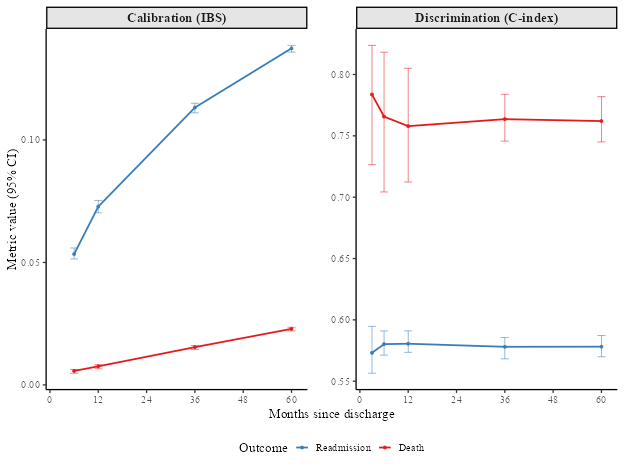

In [22]:
#| label: shap-criteria-dual-cox-plot-python-style-plot-by-time
.t0 <- proc.time()

tnr <- "Times New Roman"
set1_colors <- RColorBrewer::brewer.pal(n = 3, name = "Set1") # Set1 has up to 9 colors, but you only need 2
set1_colors <- rev(set1_colors[1:2])

# Prepare data (ensure proper extraction from results)
time_metrics <- results_shap_py$summary %>%
  filter(Time != "Global") %>%
  mutate(Time_num = as.numeric(as.character(Time)),
         # Ensure proper ordering of Risk factors
         Risk = factor(Risk, levels = c("Readmission", "Death")))

# Split by metric for separate panels or plots
cindex_data <- time_metrics %>% filter(Metric == "Uno's C-Index")
ibs_data <- time_metrics %>% filter(Metric == "IBS")


p_faceted <- time_metrics %>%
  mutate(Metric = ifelse(Metric == "Uno's C-Index", "Discrimination (C-index)", "Calibration (IBS)")) %>%
  ggplot(aes(x = Time_num, y = mean, color = Risk, fill = Risk)) +
  geom_line(linewidth = 1) +
  geom_point(size = 1.5) +
  geom_errorbar(aes(ymin = q025, ymax = q975), width = 2, alpha = 0.6, size = 0.5) +
  facet_wrap(~Metric, scales = "free_y", ncol = 2) +
  scale_color_manual(values = set1_colors) +
  scale_fill_manual(values = set1_colors) +
  scale_x_continuous(breaks = seq(0, 108, by = 12)) +
  labs(x = "Months since discharge",
       y = "Metric value (95% CI)",
       color = "Outcome",
       fill = "Outcome") +
  theme_classic(base_size = 16, base_family= tnr) +
  theme(legend.position = "bottom",
        strip.background = element_rect(fill = "grey90", color = "black"),
        strip.text = element_text(face = "bold", size = 16),
        panel.spacing = unit(2, "lines"))

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-dual-cox-plot-python-style-plot-by-time", .elapsed["elapsed"], .elapsed["elapsed"]/60))

p_faceted

In [14]:
#| label: shap-criteria-gvif
.t0 <- proc.time()

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-gvif", .elapsed["elapsed"], .elapsed["elapsed"]/60))

dplyr::bind_rows(
  rms::vif(survival::coxph(formula_shap_ds_death, data = py_corrected_datasets[[1]])) |>
    as.data.frame() |>
    tibble::rownames_to_column("Variable") |>
    dplyr::rename(Gvif = 2) |>
    dplyr::arrange(dplyr::desc(dplyr::pick(2)[[1]])) |>
    dplyr::filter(Gvif > 10) |>
    dplyr::mutate(Outcome = "Death"),
  rms::vif(survival::coxph(formula_shap_ds_readmit, data = py_corrected_datasets[[1]])) |>
    as.data.frame() |>
    tibble::rownames_to_column("Variable") |>
    dplyr::rename(Gvif = 2) |>
    dplyr::filter(Gvif > 10) |>
    dplyr::mutate(Outcome = "Readmission")
) |>
  knitr::kable("markdown", caption = "GVIF for SHAP-based Cox models, using one imputed dataset")


[chunk: shap-criteria-gvif] 0.0 sec (0.0 min)




Table: GVIF for SHAP-based Cox models, using one imputed dataset

|Variable | Gvif|Outcome |
|:--------|----:|:-------|

In [26]:
formula_shap_ds_readmit_clean

Surv(readmit_time_from_disch_m, readmit_event) ~ primary_sub_mod_cocaine_paste + 
    primary_sub_mod_cocaine_powder + primary_sub_mod_alcohol + 
    primary_sub_mod_others + sex_rec_woman + ethnicity + adm_age_rec3 + 
    eva_consumo_logro_intermedio + eva_consumo_logro_minimo + 
    ed_attainment_corr_2_completed_high_school_or_less + ed_attainment_corr_3_completed_primary_school_or_less + 
    dg_psiq_cie_10_dg + eva_sm_logro_intermedio + eva_sm_logro_minimo + 
    dit_m + occupation_condition_corr24_unemployed + occupation_condition_corr24_inactive + 
    tr_outcome_referral + tr_outcome_dropout + tr_outcome_adm_discharge_rule_violation_undet + 
    tr_outcome_adm_discharge_adm_reasons + polysubstance_strict + 
    strata(plan_type_strata)

In [27]:
formula_shap_ds_death

Surv(death_time_from_disch_m, death_event) ~ adm_age_rec3 + primary_sub_mod_cocaine_paste + 
    primary_sub_mod_cocaine_powder + primary_sub_mod_alcohol + 
    primary_sub_mod_others + occupation_condition_corr24_unemployed + 
    occupation_condition_corr24_inactive + any_phys_dx + prim_sub_freq_rec_2_2_6_days_wk + 
    prim_sub_freq_rec_3_daily + cohabitation_family_of_origin + 
    cohabitation_with_couple_children + cohabitation_others + 
    eva_ocupacion_logro_intermedio + eva_ocupacion_logro_minimo + 
    eva_fisica_logro_intermedio + eva_fisica_logro_minimo + sex_rec_woman + 
    tr_outcome_referral + tr_outcome_dropout + tr_outcome_adm_discharge_rule_violation_undet + 
    tr_outcome_adm_discharge_adm_reasons + adm_motive_sanitary_sector + 
    adm_motive_another_sud_facility_fonodrogas_senda_previene + 
    adm_motive_justice_sector + adm_motive_other + polysubstance_strict + 
    eva_sm_logro_intermedio + eva_sm_logro_minimo + ed_attainment_corr_2_completed_high_school_or_l

In [41]:
#| label: shap-criteria-aicc-for-record
.t0 <- proc.time()

# AICc is FOR RECORD ONLY (never a selection criterion). Selection / keep decisions use
# Uno's C-index + IBS from evaluate_dual_cox_python_style. By design this notebook does
# NOT use cph_evaluate_boot_oob_mi_corrected or evaluate_mi_cv_safe_strata.
# compute_mi_aicc / compare_mi_models_d1 live in calibrate_cscox_aj_grouped_corr.R; source
# it here so they are available before the calibration cell.
if (grepl("Escritorio", project_root)) {
  source(file.path(gsub("Escritorio2025", "Escritorio/", project_root), "cons2025", "_alt_scripts", "calibrate_cscox_aj_grouped_corr.R"))
} else {
  source(file.path(project_root, "cons", "_alt_scripts", "calibrate_cscox_aj_grouped_corr.R"))
}

gc()

aicc_readmit_shap_ds <- compute_mi_aicc(formula_shap_ds_readmit_clean, py_corrected_datasets)
cat(sprintf("\nReadmission (DeepSurv rule) mean AICc: %.2f\n", aicc_readmit_shap_ds$mean_aicc))

aicc_death_shap_ds <- compute_mi_aicc(formula_shap_ds_death, py_corrected_datasets)
cat(sprintf("\nDeath (DeepSurv rule) mean AICc: %.2f\n", aicc_death_shap_ds$mean_aicc))

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-aicc-for-record", .elapsed["elapsed"], .elapsed["elapsed"]/60))



AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  282748.43
Mean AICc: 282748.50
Correction added (Penalty): 0.066474
Parameters (k): 22 | Effective Sample Size (Events): 15247

Readmission (DeepSurv rule) mean AICc: 282748.50

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  53934.07
Mean AICc: 53934.72
Correction added (Penalty): 0.659794
Parameters (k): 31 | Effective Sample Size (Events): 3039

Death (DeepSurv rule) mean AICc: 53934.72

[chunk: shap-criteria-aicc-for-record] 9.0 sec (0.2 min)


In [43]:
#| label: call-functions-for-calibration
.t0 <- proc.time()

# Audited calibration engines (replace the previous inline calibrate_cph_grouped_corr):
#   readmission -> calibrate_cscox_aj_grouped_corr (cause-specific Cox -> Aalen-Johansen CIF,
#                  death as competing risk)
#   death       -> calibrate_death_km_grouped      (1 - KM)++
if (grepl("Escritorio", project_root)) {
  source(file.path(gsub("Escritorio2025", "Escritorio/", project_root), "cons2025", "_alt_scripts", "calibrate_cscox_aj_grouped_corr.R"))
  cat("Sourced: calibrate_cscox_aj_grouped_corr\n")
  source(file.path(gsub("Escritorio2025", "Escritorio/", project_root), "cons2025", "_alt_scripts", "calibrate_death_km_grouped.R"))
  cat("Sourced: calibrate_death_km_grouped\n")  
} else {
  source(file.path(project_root, "cons", "_alt_scripts", "calibrate_cscox_aj_grouped_corr.R"))
  cat("Sourced: calibrate_cscox_aj_grouped_corr\n")
  source(file.path(project_root, "cons", "_alt_scripts", "calibrate_death_km_grouped.R"))
  cat("Sourced: calibrate_death_km_grouped\n")
}

.cal_print <- function(obj, label = "") {
  s <- obj$pooled_summary
  cat(if (nchar(label) > 0) paste0("\n-- ", label, " --\n") else "\n")
  print(
    data.frame(
      t_m = s$time_months,
      ICI = round(s$ici_mean, 4),
      ECE = round(s$ece_mean, 4),
      `E/O` = round(s$eo_mean, 3),
      check.names = FALSE
    ),
    row.names = FALSE
  )
}

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "call-functions-for-calibration", .elapsed["elapsed"], .elapsed["elapsed"]/60))

Sourced: calibrate_cscox_aj_grouped_corr
Sourced: calibrate_death_km_grouped

[chunk: call-functions-for-calibration] 0.0 sec (0.0 min)


In [111]:
#| label: shap-criteria3
.t0 <- proc.time()

gc()
future::plan(future::sequential)
future::plan(future::multisession, workers = 4, maxSizeOfObjects = 2048 * 1024^2)
options(future.globals.maxSize = 2048 * 1024^2)  # 2 GiB
# --- Readmission: competing-risks calibration (cause-specific Cox -> Aalen-Johansen CIF) ---
cal_readmit_shap_ds <- calibrate_cscox_aj_grouped_corr(
    formula_readmit      = formula_shap_ds_readmit_clean,
    formula_death        = formula_shap_ds_death,
    data                 = py_corrected_datasets,
    times                = c(6, 12, 36, 60, 96),
    seed                 = 2125L,
    validation           = "cv",
    n_repeats            = 20L,
    compute_ici          = TRUE,
    ici_times            = 60,
    make_plots           = TRUE,
    parallel_cv          = TRUE,
    parallel_calibration = TRUE,
    future_scheduling    = 2,
    debug_fit            = TRUE
)
.cal_print(cal_readmit_shap_ds, "Readmit (DeepSurv rule) -- AJ CIF")

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria3", .elapsed["elapsed"], .elapsed["elapsed"]/60))

# --- Death: KM-based calibration (1 - KM) ---
cal_death_shap_ds <- calibrate_death_km_grouped(
    formula     = formula_shap_ds_death,
    data        = py_corrected_datasets,
    times       = c(6, 12, 36, 60, 96),
    seed        = 2125L,
    validation  = "cv",
    n_repeats   = 20L,
    parallel_cv = TRUE,
    verbose     = TRUE
)
.cal_print(cal_death_shap_ds, "Death (DeepSurv rule) -- 1-KM")

Using 5 imputed dataset(s).
Validation: cv
Repetitions: 20 | same fold split across imputations within each repetition.
ICI: enabled at horizons 60.
Running CV predictions in parallel across 100 repetition x fold tasks... done
Calibrating 20 repetitions in parallel... done


There were 16 warnings (use warnings() to see them)



-- Readmit (DeepSurv rule) -- AJ CIF --
 t_m    ICI    ECE   E/O
   6     NA 0.0025 0.993
  12     NA 0.0030 0.993
  36     NA 0.0038 0.991
  60 0.0099 0.0051 0.988
  96     NA 0.0039 0.984

[chunk: shap-criteria3] 1126.0 sec (18.8 min)

calibrate_death_km_grouped: 20 repeats x 5 folds x 5 imputations = 500 fits (100 tasks)
  Pre-flight: running task 1 sequentially...
  Pre-flight OK: risk_mat dim=14105x5
  Pooling repetition 20/20

  Pooled calibration summary:
  time_months    ici_mean        ici_sd     ece_mean  eo_mean
1           6 0.001506556 0.00005742340 0.0005755440 1.006971
2          12 0.002385873 0.00006430667 0.0009792192 1.008541
3          36 0.006317482 0.00010018338 0.0023488378 1.010146
4          60 0.008850603 0.00007581618 0.0026456446 1.018044
5          96 0.013006431 0.00016163161 0.0030422617 1.054765

-- Death (DeepSurv rule) -- 1-KM --
 t_m    ICI    ECE   E/O
   6 0.0015 0.0006 1.007
  12 0.0024 0.0010 1.009
  36 0.0063 0.0023 1.010
  60 0.0089 0.0026 1.01

~60 minutes

In [15]:
#| label: shap-criteria-nph-readm
.t0 <- proc.time()

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-nph-readm", .elapsed["elapsed"], .elapsed["elapsed"]/60))

cox.zph(coxph(formula_shap_ds_readmit_clean, data= py_corrected_datasets[[1]]))


[chunk: shap-criteria-nph-readm] 0.0 sec (0.0 min)


                                                         chisq df       p
primary_sub_mod_cocaine_paste                           0.0956  1 0.75714
primary_sub_mod_cocaine_powder                          0.0687  1 0.79325
primary_sub_mod_alcohol                                 0.2741  1 0.60058
primary_sub_mod_others                                  3.4304  1 0.06401
sex_rec_woman                                           1.0309  1 0.30994
ethnicity                                               4.3883  1 0.03619
adm_age_rec3                                            5.5196  1 0.01880
eva_consumo_logro_intermedio                            1.4248  1 0.23261
eva_consumo_logro_minimo                                6.3522  1 0.01172
ed_attainment_corr_2_completed_high_school_or_less      7.8582  1 0.00506
ed_attainment_corr_3_completed_primary_school_or_less  11.5096  1 0.00069
dg_psiq_cie_10_dg                                       0.4018  1 0.52614
eva_sm_logro_intermedio               

In [16]:
#| label: shap-criteria-nph2-death
.t0 <- proc.time()

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-nph2-death", .elapsed["elapsed"], .elapsed["elapsed"]/60))

cox.zph(coxph(formula_shap_ds_death, data= py_corrected_datasets[[1]]))


[chunk: shap-criteria-nph2-death] 0.0 sec (0.0 min)


                                                              chisq df       p
adm_age_rec3                                                0.00936  1  0.9229
primary_sub_mod_cocaine_paste                               0.46281  1  0.4963
primary_sub_mod_cocaine_powder                              0.73791  1  0.3903
primary_sub_mod_alcohol                                     0.43614  1  0.5090
primary_sub_mod_others                                      0.01292  1  0.9095
occupation_condition_corr24_unemployed                      1.62479  1  0.2024
occupation_condition_corr24_inactive                        0.02227  1  0.8814
any_phys_dx                                                15.31075  1 9.1e-05
prim_sub_freq_rec_2_2_6_days_wk                             0.91987  1  0.3375
prim_sub_freq_rec_3_daily                                   1.67704  1  0.1953
cohabitation_family_of_origin                               4.45883  1  0.0347
cohabitation_with_couple_children                   


[chunk: shap-criteria-nph4-plot-readm] 3.1 sec (0.1 min)


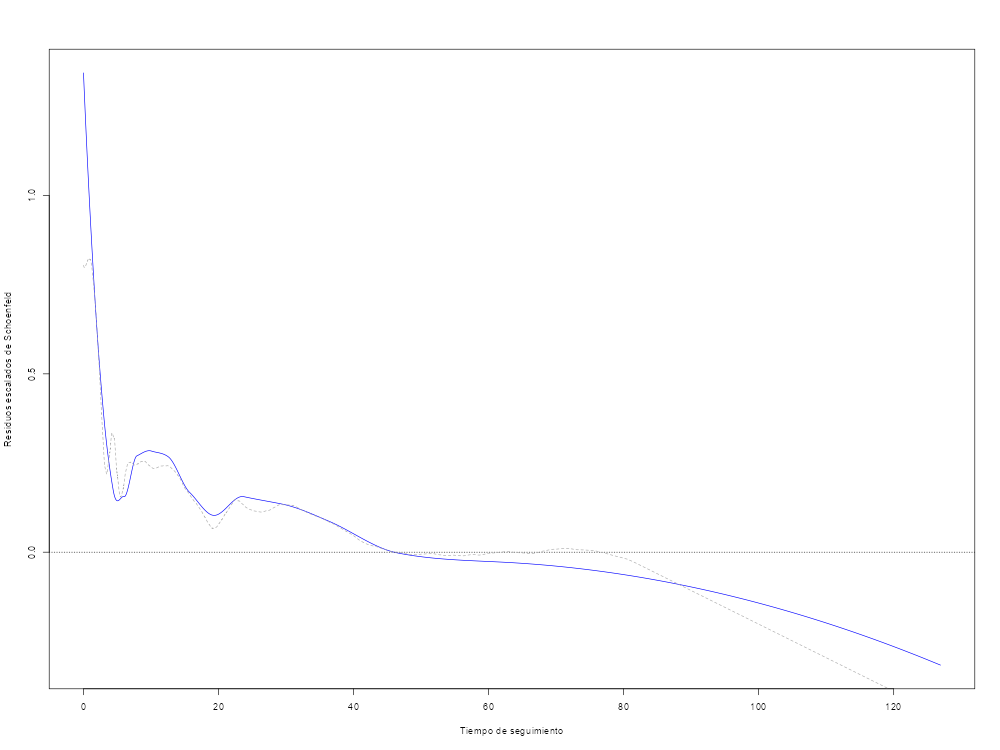

In [35]:
#| label: shap-criteria-nph4-plot-readm
.t0 <- proc.time()

res_ds <- resid(coxph(formula_shap_ds_readmit_clean, data = py_corrected_datasets[[1]]),
                "scaledsch")

time <- as.numeric(rownames(res_ds))
y_ds <- res_ds[, "tr_outcome_adm_discharge_rule_violation_undet"]

z2_ds <- loess(y_ds ~ time, span = 0.50)
ord <- order(time)

plot(time[ord], fitted(z2_ds)[ord], type = "l", col = "blue",
     xlab = "Tiempo de seguimiento",
     ylab = "Residuos escalados de Schoenfeld")
abline(h = 0, lty = 3)

ss_ds <- supsmu(time, y_ds)
lines(ss_ds$x, ss_ds$y, lty = 2, col = "darkgray")

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-nph4-plot-readm", .elapsed["elapsed"], .elapsed["elapsed"]/60))


[chunk: shap-criteria-nph5-plot-death] 1.8 sec (0.0 min)


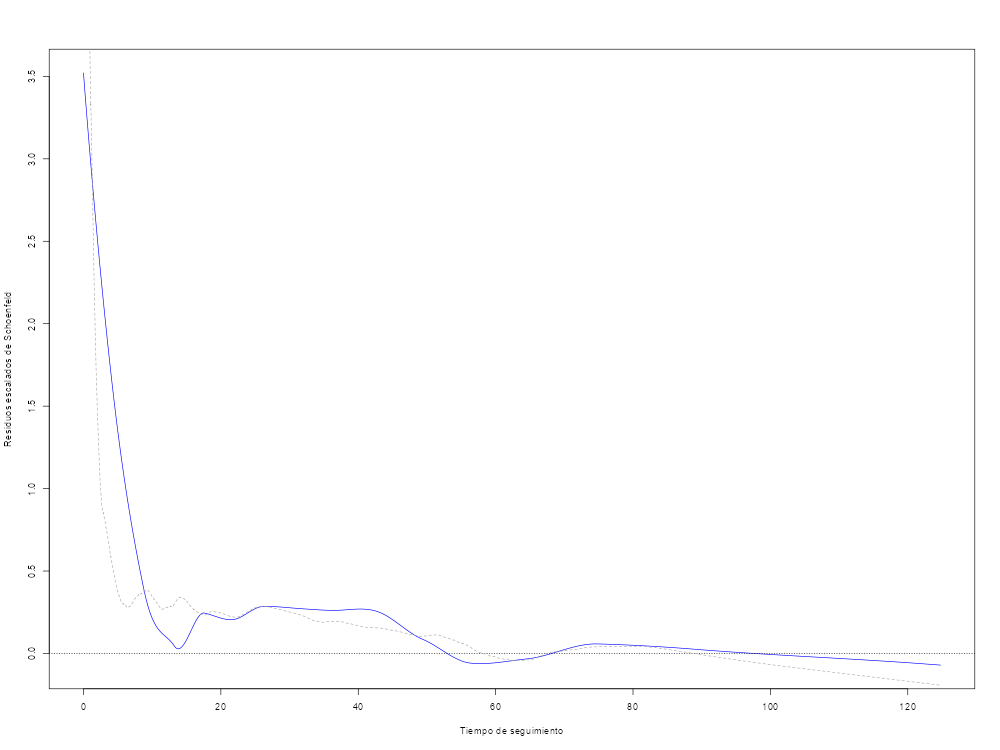

In [36]:
#| label: shap-criteria-nph5-plot-death
.t0 <- proc.time()

res_ds_d <- resid(
  coxph(formula_shap_ds_death, data = py_corrected_datasets[[1]]),
  "scaledsch"
)

time_d <- as.numeric(rownames(res_ds_d))
y_ds_d <- res_ds_d[, "tr_outcome_adm_discharge_rule_violation_undet"]

z2_ds <- loess(y_ds_d ~ time_d, span = 0.50)
ord_d <- order(time_d)

plot(time_d[ord_d], fitted(z2_ds)[ord_d], type = "l", col = "blue",
     xlab = "Tiempo de seguimiento",
     ylab = "Residuos escalados de Schoenfeld")
abline(h = 0, lty = 3)

ss_ds_d <- supsmu(time_d, y_ds_d)
lines(ss_ds_d$x, ss_ds_d$y, lty = 2, col = "darkgray")

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-nph5-plot-death", .elapsed["elapsed"], .elapsed["elapsed"]/60))

### Add strata

In [17]:
#| label: shap-criteria-upd-formula-additional-strata-readm
.t0 <- proc.time()

formula_shap_ds_readmit_clean_updated <- update(
  formula_shap_ds_readmit_clean,
  . ~ . - tr_outcome_adm_discharge_rule_violation_undet + strata(tr_outcome_adm_discharge_rule_violation_undet)
)

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-upd-formula-additional-strata-readm", .elapsed["elapsed"], .elapsed["elapsed"]/60))

formula_shap_ds_readmit_clean_updated


[chunk: shap-criteria-upd-formula-additional-strata-readm] 0.0 sec (0.0 min)


Surv(readmit_time_from_disch_m, readmit_event) ~ primary_sub_mod_cocaine_paste + 
    primary_sub_mod_cocaine_powder + primary_sub_mod_alcohol + 
    primary_sub_mod_others + sex_rec_woman + ethnicity + adm_age_rec3 + 
    eva_consumo_logro_intermedio + eva_consumo_logro_minimo + 
    ed_attainment_corr_2_completed_high_school_or_less + ed_attainment_corr_3_completed_primary_school_or_less + 
    dg_psiq_cie_10_dg + eva_sm_logro_intermedio + eva_sm_logro_minimo + 
    dit_m + occupation_condition_corr24_unemployed + occupation_condition_corr24_inactive + 
    tr_outcome_referral + tr_outcome_dropout + tr_outcome_adm_discharge_adm_reasons + 
    polysubstance_strict + strata(plan_type_strata) + strata(tr_outcome_adm_discharge_rule_violation_undet)

In [18]:
#| label: shap-criteria-upd-formula-additional-strata-death
.t0 <- proc.time()

# NOTE (verify against cox.zph above, cell shap-criteria-nph2-death): the rule is to
# stratify ONLY the single worst-by-far PH violator, then re-check the GLOBAL test.
# tr_outcome_adm_discharge_rule_violation_undet is used as the default worst term for
# BOTH outcomes; if cox.zph shows any_phys_dx (or another term) dominates for death,
# stratify that term instead here and in the residual plot (cell shap-criteria-nph5-plot-death).

formula_shap_ds_death_updated <- update(
  formula_shap_ds_death,
  . ~ . - tr_outcome_adm_discharge_rule_violation_undet + strata(tr_outcome_adm_discharge_rule_violation_undet)
)

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-upd-formula-additional-strata-death", .elapsed["elapsed"], .elapsed["elapsed"]/60))

formula_shap_ds_death_updated


[chunk: shap-criteria-upd-formula-additional-strata-death] 0.0 sec (0.0 min)


Surv(death_time_from_disch_m, death_event) ~ adm_age_rec3 + primary_sub_mod_cocaine_paste + 
    primary_sub_mod_cocaine_powder + primary_sub_mod_alcohol + 
    primary_sub_mod_others + occupation_condition_corr24_unemployed + 
    occupation_condition_corr24_inactive + any_phys_dx + prim_sub_freq_rec_2_2_6_days_wk + 
    prim_sub_freq_rec_3_daily + cohabitation_family_of_origin + 
    cohabitation_with_couple_children + cohabitation_others + 
    eva_ocupacion_logro_intermedio + eva_ocupacion_logro_minimo + 
    eva_fisica_logro_intermedio + eva_fisica_logro_minimo + sex_rec_woman + 
    tr_outcome_referral + tr_outcome_dropout + tr_outcome_adm_discharge_adm_reasons + 
    adm_motive_sanitary_sector + adm_motive_another_sud_facility_fonodrogas_senda_previene + 
    adm_motive_justice_sector + adm_motive_other + polysubstance_strict + 
    eva_sm_logro_intermedio + eva_sm_logro_minimo + ed_attainment_corr_2_completed_high_school_or_less + 
    ed_attainment_corr_3_completed_primary_sch

In [19]:
#| label: shap-criteria-nph-recheck
.t0 <- proc.time()

# Re-check PH after stratifying the single worst-by-far term. The rule is NOT to stratify
# every term with cox.zph p<0.05 (large-sample chi-square inflates p): stratify only the
# dominant violator, then confirm the GLOBAL test is no longer significant.
cat("Readmission -- post-stratification cox.zph:\n")
print(cox.zph(coxph(formula_shap_ds_readmit_clean_updated, data = py_corrected_datasets[[1]])))
cat("\nDeath -- post-stratification cox.zph:\n")
print(cox.zph(coxph(formula_shap_ds_death_updated, data = py_corrected_datasets[[1]])))

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-nph-recheck", .elapsed["elapsed"], .elapsed["elapsed"]/60))


Readmission -- post-stratification cox.zph:
                                                          chisq df       p
primary_sub_mod_cocaine_paste                           0.42536  1 0.51428
primary_sub_mod_cocaine_powder                          0.00543  1 0.94127
primary_sub_mod_alcohol                                 0.63872  1 0.42417
primary_sub_mod_others                                  3.39486  1 0.06540
sex_rec_woman                                           1.25774  1 0.26208
ethnicity                                               4.12735  1 0.04220
adm_age_rec3                                            7.16768  1 0.00742
eva_consumo_logro_intermedio                            0.36254  1 0.54710
eva_consumo_logro_minimo                                6.03587  1 0.01402
ed_attainment_corr_2_completed_high_school_or_less      7.52578  1 0.00608
ed_attainment_corr_3_completed_primary_school_or_less  10.85096  1 0.00099
dg_psiq_cie_10_dg                                       

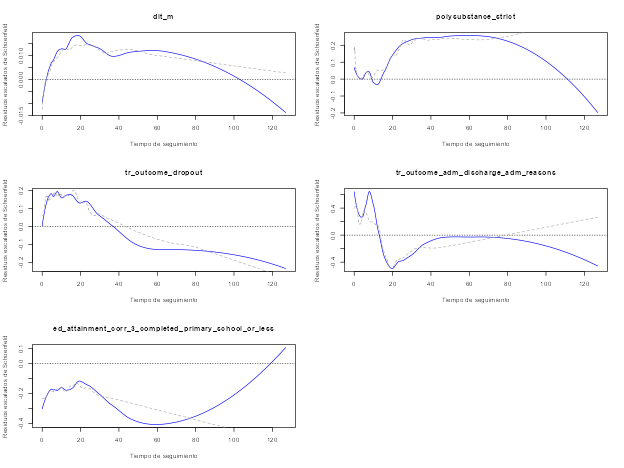


[chunk: shap-criteria-nph-plot-readm-extra] 4.7 sec (0.1 min)


In [29]:
#| label: shap-criteria-nph-plot-readm-extra
.t0 <- proc.time()

res_ds <- resid(coxph(formula_shap_ds_readmit_clean, data = py_corrected_datasets[[1]]),
                "scaledsch")

time <- as.numeric(rownames(res_ds))
ord <- order(time)

vars_nph <- c(
  "dit_m",
  "polysubstance_strict",
  "tr_outcome_dropout",
  "tr_outcome_adm_discharge_adm_reasons",
  "ed_attainment_corr_3_completed_primary_school_or_less"
)

par(mfrow = c(3, 2))

for (v in vars_nph) {
  y_ds <- res_ds[, v]

  z2_ds <- loess(y_ds ~ time, span = 0.50)

  plot(time[ord], fitted(z2_ds)[ord], type = "l", col = "blue",
       xlab = "Tiempo de seguimiento",
       ylab = "Residuos escalados de Schoenfeld",
       main = v)
  abline(h = 0, lty = 3)

  ss_ds <- supsmu(time, y_ds)
  lines(ss_ds$x, ss_ds$y, lty = 2, col = "darkgray")
}

par(mfrow = c(1, 1))

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n",
            "shap-criteria-nph-plot-readm-extra",
            .elapsed["elapsed"], .elapsed["elapsed"]/60))

Inspection of the scaled Schoenfeld residual smooths showed clear evidence that the proportional hazards assumption was not equally violated across the entire follow-up period, but rather in variable-specific time windows. Overall, the observed patterns suggest genuine time-varying effects rather than simple misspecification of the functional form of the covariates.

For `dit_m`, the smoothed residual pattern indicated a strong positive deviation early in follow-up, reaching its maximum during approximately the first 20 months. Thereafter, the effect declined in a largely monotonic fashion, crossed the null line after roughly 60 months, and became clearly negative toward the end of follow-up. This supports the interpretation of an early effect that progressively fades and eventually reverses over time. Importantly, this pattern is consistent with non-proportionality in the regression coefficient itself, rather than non-linearity in the covariate. This is also consistent with the fact that transforming `dit_m` did not attenuate the proportional hazards violation and instead increased the `cox.zph` statistic.

For `polysubstance_strict`, the residual smooth was close to zero or slightly negative at the beginning of follow-up, then increased and stabilized at a positive plateau from approximately 30 to 90 months. The curve declined again in the final part of follow-up. This suggests that the association between polysubstance use and readmission is not strongest immediately after discharge, but emerges more clearly during the medium-term follow-up period. The upward time trend is therefore compatible with a real non-proportional effect, in which the excess hazard associated with polysubstance use becomes more apparent after the early post-discharge period.

For `tr_outcome_dropout`, the plot showed the clearest and most interpretable violation. The residual smooth rose rapidly to a high positive level during the first 20 months, then declined steadily, crossed the null line around 60 to 70 months, and remained negative at longer follow-up times. This pattern indicates that dropout is a strong predictor of early readmission, but that its effect progressively weakens over time. The shape is coherent with a clinically meaningful time-varying effect rather than random instability.

For `tr_outcome_adm_discharge_adm_reasons`, the non-proportionality appeared concentrated almost entirely in the very early follow-up period. The smoothed residuals were markedly positive during the first months, dropped sharply between approximately 10 and 20 months, and then remained close to the null line for much of the subsequent follow-up. This suggests an acute, transient effect: admission/discharge-related reasons are associated with readmission risk mainly in the immediate post-discharge window, while the effect becomes approximately proportional or negligible after the early phase.

For `ed_attainment_corr_3_completed_primary_school_or_less`, the residual pattern was comparatively stable during the first 20 months, became increasingly negative between approximately 50 and 90 months, and then rose sharply after 100 months. This indicates that the deviation from proportionality is concentrated in the long-term follow-up period. However, because this occurs late in follow-up, when the number of individuals still at risk is likely smaller, this pattern should be interpreted more cautiously. The late upward swing may reflect a genuine delayed change in the association between low educational attainment and readmission, but it may also be more sensitive to sparse risk sets and wider uncertainty in the tail of the follow-up distribution.

Taken together, these plots indicate that the proportional hazards violations are not uniform artifacts. Instead, they reflect substantively interpretable time-dependent associations. `dit_m` and `tr_outcome_dropout` show early effects that decay and eventually reverse, `polysubstance_strict` shows a medium-term emerging effect, `tr_outcome_adm_discharge_adm_reasons` shows an acute early effect, and `ed_attainment_corr_3_completed_primary_school_or_less` shows a late-follow-up deviation that should be interpreted with caution due to the likely sparsity of events and individuals at risk at longer times.

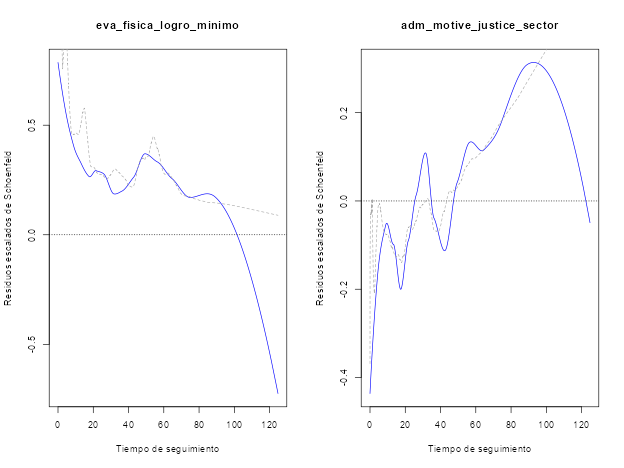


[chunk: shap-criteria-nph-plot-death-extra] 2.2 sec (0.0 min)


In [31]:
#| label: shap-criteria-nph-plot-death-extra
.t0 <- proc.time()

res_ds <- resid(coxph(formula_shap_ds_death_updated, data = py_corrected_datasets[[1]]),
                "scaledsch")

time <- as.numeric(rownames(res_ds))
ord <- order(time)

vars_nph <- c(
  "eva_fisica_logro_minimo",
  "adm_motive_justice_sector"
)

par(mfrow = c(1, 2))

for (v in vars_nph) {
  y_ds <- res_ds[, v]

  z2_ds <- loess(y_ds ~ time, span = 0.50)

  plot(time[ord], fitted(z2_ds)[ord], type = "l", col = "blue",
       xlab = "Tiempo de seguimiento",
       ylab = "Residuos escalados de Schoenfeld",
       main = v)
  abline(h = 0, lty = 3)

  ss_ds <- supsmu(time, y_ds)
  lines(ss_ds$x, ss_ds$y, lty = 2, col = "darkgray")
}

par(mfrow = c(1, 1))

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n",
            "shap-criteria-nph-plot-death-extra",
            .elapsed["elapsed"], .elapsed["elapsed"]/60))

In [32]:
df <- data.frame( Candidate = c( 'ANCLA (2 strata)', 'D_str_fis (phys_eval->strata)', 'D_str_phys (any_phys_dx->strata)', 'R_dit_ns3 (ns(dit_m,3))', 'R_dit_log (log1p(dit_m))', 'ANCLA (2 strata)', 'R_str_ed (ed_attainment->strata)', 'R_str_poly (polysubstance->strata)', 'R_str_tro (tr_outcome->strata)' ), Outcome = c('Death', 'Death', 'Death', 'Readm', 'Readm', 'Readm', 'Readm', 'Readm', 'Readm'), C = c(0.7423, 0.7393, 0.7304, 0.5747, 0.5745, 0.5738, 0.5707, 0.5707, 0.5693), dC = c('', '-0.0030', '-0.0120', '+0.0009', '+0.0007', '', '-0.0030', '-0.0031', '-0.0045'), dIBS = c('', '0', '0', '+0.0001', '+0.0001', '', '0', '0', '+0.0001'), zph_global = c(59.6, 47.5, 44.8, 108.1, 107.1, 100.4, 88.2, 80.1, 62.6), zph_term = c(13.8, NA, NA, 27.8, 28.1, 19.7, NA, NA, NA), n_strata = c(10L, 30L, 20L, 10L, 10L, 10L, 30L, 20L, 25L), min_events_stratum = c(15L, 2L, 2L, 79L, 79L, 79L, 14L, 10L, NA), stringsAsFactors = FALSE ) 

knitr::kable(df, "markdown", caption= "Test of different (2 imp, 3-fold), eval times= 3/6/12/36/60")



Table: Test of different (2 imp, 3-fold), eval times= 3/6/12/36/60

|Candidate                          |Outcome |      C|dC      |dIBS    | zph_global| zph_term| n_strata| min_events_stratum|
|:----------------------------------|:-------|------:|:-------|:-------|----------:|--------:|--------:|------------------:|
|ANCLA (2 strata)                   |Death   | 0.7423|        |        |       59.6|     13.8|       10|                 15|
|D_str_fis (phys_eval->strata)      |Death   | 0.7393|-0.0030 |0       |       47.5|         |       30|                  2|
|D_str_phys (any_phys_dx->strata)   |Death   | 0.7304|-0.0120 |0       |       44.8|         |       20|                  2|
|R_dit_ns3 (ns(dit_m,3))            |Readm   | 0.5747|+0.0009 |+0.0001 |      108.1|     27.8|       10|                 79|
|R_dit_log (log1p(dit_m))           |Readm   | 0.5745|+0.0007 |+0.0001 |      107.1|     28.1|       10|                 79|
|ANCLA (2 strata)                   |Readm   | 0.5738| 

In the transition models, covariate proportionality was retained, stratifying only by plan type and by administrative discharge or rule violation. Proportionality deviations persisted in some covariates, assessed by the magnitude of the Schoenfeld residuals rather than their statistical significance, since the sample size renders even minor differences significant. As a sensitivity analysis, an additional stratum was introduced for the terms with the greatest deviation (in readmission, dropout, polysubstance use, and schooling; in mortality, physical comorbidity and physical evaluation at discharge), and treatment duration was transformed. None of these alternatives improved discrimination or prediction error (changes in Uno's C-index were below 0.001 with transformation and between −0.003 and −0.012 with stratification, with no change in the IBS), and every additional stratum fragmented the baseline combinations to the point of leaving cells with 0 to 2 events, producing unstable transition probability estimates. Transformations of treatment duration did not reduce the proportionality deviation, indicating a time-varying effect rather than a functional form problem, which the Aalen-Johansen estimator via probtrans cannot accommodate without time-dependent coefficients. For consistency and parsimony, the specification with two strata was retained, and the hazard ratios are interpreted as effects averaged over follow-up. Given the descriptive and exploratory nature of these models, aimed at describing the joint dynamics of the trajectories rather than primary prediction, this decision does not compromise the objectives of the analysis.

For `eva_fisica_logro_minimo`, the smoothed scaled Schoenfeld residuals showed a clearly positive effect at the beginning of follow-up, with the time-varying coefficient starting at approximately β = 0.8 during the first months. The curve then declined over time, although not perfectly linearly, with small secondary peaks, including a visible rebound around 50 months. Despite these fluctuations, the effect remained mostly positive through the medium-term follow-up, crossed the null line around 90 to 100 months, and then dropped sharply into negative values after approximately 110 months. This pattern supports a real non-proportional effect with a predominantly descending trend. Substantively, achieving only a minimal physical evaluation level at discharge appears to act as an early vulnerability marker for mortality: it is strongly associated with mortality risk soon after discharge, but this association attenuates as follow-up progresses. The sharp negative drop at the far right tail should be interpreted cautiously, as it occurs where the number of individuals still at risk is likely very small. Thus, the main interpretable signal is the strong early effect and its gradual attenuation, rather than the unstable extreme-tail behavior.

For `adm_motive_justice_sector`, the residual smooth began below zero, at approximately β = -0.45, and showed several oscillations around the null line during the first 50 months. The curve then increased into a positive plateau between approximately 80 and 100 months before declining again toward the end of follow-up. Compared with the other variables, this pattern was less clean and less clinically structured. The apparent violation seems to be driven by a combination of early jitter and a later positive rebound, rather than by a consistent monotonic trend or a clearly localized early effect. This is consistent with its borderline `cox.zph` result, with a chi-square statistic around 8.2. Visually, this appears closer to instability or weak non-proportionality than to a robust time-varying

### Additional strata

Multi-state model transitions were specified with proportional baseline hazards for the covariates, stratifying only by type of program and by administrative discharge or rule violation. After this stratification, deviations from proportionality persisted for some covariates (for readmission: treatment duration, dropout, polysubstance use, and schooling; for mortality: physical comorbidity and physical assessment at discharge). These deviations were evaluated by the magnitude of the Schoenfeld residuals and not solely by statistical significance, since the sample size renders even minor differences significant. Because the aim of these models is descriptive and exploratory—intended to uncover the joint dynamics of the trajectories rather than to serve as the primary prediction tool—and because the transition probability estimator (Aalen–Johansen via probtrans) requires a specification with fixed covariates, we chose not to introduce additional strata or time-dependent coefficients: additional strata fragmented the baseline strata and reduced events per cell without improving discrimination or prediction error [complete with ΔC and ΔIBS from the table]. Hazard ratios are therefore interpreted as average effects over the follow-up period.

In [35]:
#| label: shap-criteria-additional-strata2-dual-python-style
.t0 <- proc.time()

results_ds_shap_py_upd <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_ds_readmit_clean_updated,
  formula_death = formula_shap_ds_death_updated,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3, 6, 12, 36, 60)
)

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-additional-strata2-dual-python-style", .elapsed["elapsed"], .elapsed["elapsed"]/60))

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....

[chunk: shap-criteria-additional-strata2-dual-python-style] 140.4 sec (2.3 min)


In [36]:
#| label: shap-criteria-strata-decision
.t0 <- proc.time()

results_ds_shap_py<-results_shap_py
rm("results_shap_py")

# Stratifying the single worst-by-far PH violator is adopted for PH CORRECTNESS, not for a
# C/IBS gain (pred22 showed strata leave discrimination ~unchanged). The conservative check
# here only confirms the strata model does not MATERIALLY worsen C/IBS vs the no-extra-strata
# rule model; calibration is verified in the calibration cell.
.decide_dualcox(results_ds_shap_py, results_ds_shap_py_upd,
                anchor_label = "rule (no extra strata)", cand_label = "rule + NPH strata")

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-strata-decision", .elapsed["elapsed"], .elapsed["elapsed"]/60))



=== Decision: rule + NPH strata  vs  rule (no extra strata)   (Time = Global) ===
  Readmission  Uno's C 0.5771 -> 0.5741 (dC -0.0030) | IBS 0.1374 -> 0.1374 (improve +0.0000)  [~tie]
  Death        Uno's C 0.7415 -> 0.7423 (dC +0.0008) | IBS 0.0229 -> 0.0229 (improve +0.0000)  [~tie]
  -> KEEP ANCHOR (gains < 0.01; default to the simpler / approved model)
     (Calibration is a separate guardrail; AICc is for record only.)

[chunk: shap-criteria-strata-decision] 0.0 sec (0.0 min)


In [ ]:
#| label: shap-criteria-additional-strata2-summ-python-style
.t0 <- proc.time()

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-additional-strata2-summ-python-style", .elapsed["elapsed"], .elapsed["elapsed"]/60))

results_ds_shap_py_upd$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, updated formulas with additional strata")


[chunk: shap-criteria-dual-cox-upd-plot-python-style-plot-by-time] 0.0 sec (0.0 min)


Warning messages:
1: Removed 2 rows containing missing values or values outside the scale range
(`geom_line()`). 
2: Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`). 


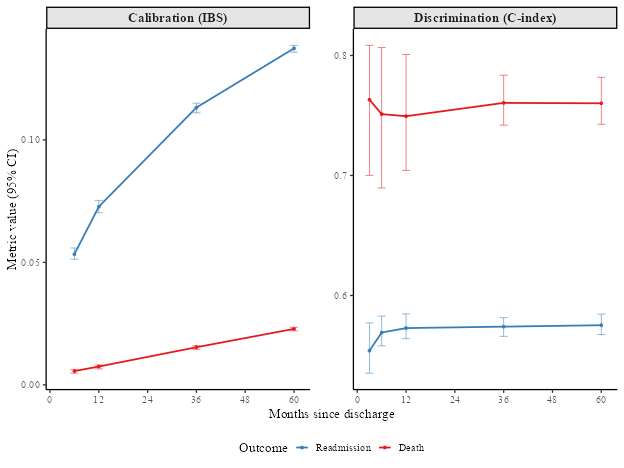

In [37]:
#| label: shap-criteria-dual-cox-upd-plot-python-style-plot-by-time
.t0 <- proc.time()

# Prepare data (ensure proper extraction from results)
time_metrics <- results_ds_shap_py_upd$summary %>%
  filter(Time != "Global") %>%
  mutate(Time_num = as.numeric(as.character(Time)),
         # Ensure proper ordering of Risk factors
         Risk = factor(Risk, levels = c("Readmission", "Death")))
# Split by metric for separate panels or plots
cindex_data <- time_metrics %>% filter(Metric == "Uno's C-Index")
ibs_data <- time_metrics %>% filter(Metric == "IBS")

p_faceted_upd <- time_metrics %>%
  mutate(Metric = ifelse(Metric == "Uno's C-Index", "Discrimination (C-index)", "Calibration (IBS)")) %>%
  ggplot(aes(x = Time_num, y = mean, color = Risk, fill = Risk)) +
  geom_line(linewidth = 1) +
  geom_point(size = 1.5) +
  geom_errorbar(aes(ymin = q025, ymax = q975), width = 2, alpha = 0.6, size = 0.5) +
  facet_wrap(~Metric, scales = "free_y", ncol = 2) +
  scale_color_manual(values = set1_colors) +
  scale_fill_manual(values = set1_colors) +
  scale_x_continuous(breaks = seq(0, 108, by = 12)) +
  labs(x = "Months since discharge",
       y = "Metric value (95% CI)",
       color = "Outcome",
       fill = "Outcome") +
  theme_classic(base_size = 16, base_family= tnr) +
  theme(legend.position = "bottom",
        strip.background = element_rect(fill = "grey90", color = "black"),
        strip.text = element_text(face = "bold", size = 16),
        panel.spacing = unit(2, "lines"))

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-dual-cox-upd-plot-python-style-plot-by-time", .elapsed["elapsed"], .elapsed["elapsed"]/60))

p_faceted_upd

We chose the UPDATED model because it is conceptually stronger when the proportional hazards (PH) assumption does not hold for that variable. While the CLEAN model can be more informative for cross-validation (CV) if the goal is to assess performance across the entire population, the UPDATED specification avoids imposing PH restrictions. To make this choice consistent, the CV procedure must not filter out those cases-for example, by applying strata() only to plan_type_strata and treating the variable as a covariate, or by using a CV approach that allows empty strata in the test folds.
**Conservative rule applied here:** stratification of the single worst-by-far PH violator is adopted for *PH correctness*, not for a discrimination gain; the `.decide_dualcox()` check above only confirms it does not materially worsen Uno's C or IBS (and calibration is checked separately). When a strata change neither fixes a substantial PH violation nor improves C/IBS, the simpler model is kept.


In [38]:
#| label: shap-criteria-strata-aicc-readm
.t0 <- proc.time()

gc()
# cph_evaluate_boot_oob_mi_corrected / evaluate_mi_cv_safe_strata intentionally NOT used.
# AICc for record only; the strata decision is judged on C-index/IBS (dual-cox cell above)
# and on PH correctness (cox.zph), not on AICc.
aicc_readmit_upd1_shap <- compute_mi_aicc(
  as.formula(gsub("strat\\(", "strata(", paste(deparse(formula_shap_ds_readmit_clean_updated), collapse = " "))),
  py_corrected_datasets
)
cat(sprintf("\nReadmission (+strata) mean AICc: %.2f\n", aicc_readmit_upd1_shap$mean_aicc))

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-strata-aicc-readm", .elapsed["elapsed"], .elapsed["elapsed"]/60))



AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272616.09
Mean AICc: 272616.15
Correction added (Penalty): 0.060690
Parameters (k): 21 | Effective Sample Size (Events): 15247

Readmission (+strata) mean AICc: 272616.15

[chunk: shap-criteria-strata-aicc-readm] 4.9 sec (0.1 min)


In [39]:
#| label: shap-criteria-strata-aicc-death
.t0 <- proc.time()

gc()
# AICc for record only (see note above).
aicc_death_upd1_shap <- compute_mi_aicc(
  as.formula(gsub("strat\\(", "strata(", paste(deparse(formula_shap_ds_death_updated), collapse = " "))),
  py_corrected_datasets
)
cat(sprintf("\nDeath (+strata) mean AICc: %.2f\n", aicc_death_upd1_shap$mean_aicc))

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-strata-aicc-death", .elapsed["elapsed"], .elapsed["elapsed"]/60))



AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51500.72
Mean AICc: 51501.34
Correction added (Penalty): 0.618351
Parameters (k): 30 | Effective Sample Size (Events): 3039

Death (+strata) mean AICc: 51501.34

[chunk: shap-criteria-strata-aicc-death] 5.2 sec (0.1 min)


In [44]:
#| label: shap-criteria-additional-strata23
.t0 <- proc.time()

gc()
future::plan(future::sequential)
future::plan(future::multisession, workers = 6, maxSizeOfObjects = 2048 * 1024^2)
options(future.globals.maxSize = 2048 * 1024^2)  # 2 GiB

cal_readmit_shap2_ds <- calibrate_cscox_aj_grouped_corr(
    formula_readmit      = formula_shap_ds_readmit_clean_updated,
    formula_death        = formula_shap_ds_death_updated,
    data                 = py_corrected_datasets,
    times                = c(6, 12, 36, 60, 96),
    seed                 = 2125L,
    validation           = "cv",
    n_repeats            = 20L,
    compute_ici          = TRUE,
    ici_times            = 60,
    make_plots           = TRUE,
    parallel_cv          = TRUE,
    parallel_calibration = TRUE,
    future_scheduling    = 2,
    debug_fit            = TRUE
)
.cal_print(cal_readmit_shap2_ds, "Readmit (+strata) -- AJ CIF")

cal_death_shap2_ds <- calibrate_death_km_grouped(
    formula     = formula_shap_ds_death_updated,
    data        = py_corrected_datasets,
    times       = c(6, 12, 36, 60, 96),
    seed        = 2125L,
    validation  = "cv",
    n_repeats   = 20L,
    parallel_cv = TRUE,
    verbose     = TRUE
)
.cal_print(cal_death_shap2_ds, "Death (+strata) -- 1-KM")

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-additional-strata23", .elapsed["elapsed"], .elapsed["elapsed"]/60))

Using 5 imputed dataset(s).
Validation: cv
Repetitions: 20 | same fold split across imputations within each repetition.
ICI: enabled at horizons 60.
Running CV predictions in parallel across 100 repetition x fold tasks... done
Calibrating 20 repetitions in parallel... done


There were 24 warnings (use warnings() to see them)



-- Readmit (+strata) -- AJ CIF --
 t_m    ICI    ECE   E/O
   6     NA 0.0026 0.992
  12     NA 0.0025 0.992
  36     NA 0.0039 0.991
  60 0.0099 0.0050 0.989
  96     NA 0.0039 0.985

calibrate_death_km_grouped: 20 repeats x 5 folds x 5 imputations = 500 fits (100 tasks)
  Pre-flight: running task 1 sequentially...
  Pre-flight OK: risk_mat dim=14105x5
  Pooling repetition 20/20

  Pooled calibration summary:
  time_months    ici_mean        ici_sd     ece_mean  eo_mean
1           6 0.002280837 0.00005268846 0.0006027663 1.005681
2          12 0.002866716 0.00004712451 0.0009763237 1.007990
3          36 0.006345629 0.00011345588 0.0020686634 1.011830
4          60 0.008872620 0.00010344381 0.0024007633 1.021960
5          96 0.013163747 0.00021299234 0.0036084672 1.068228

-- Death (+strata) -- 1-KM --
 t_m    ICI    ECE   E/O
   6 0.0023 0.0006 1.006
  12 0.0029 0.0010 1.008
  36 0.0063 0.0021 1.012
  60 0.0089 0.0024 1.022
  96 0.0132 0.0036 1.068

[chunk: shap-criteria-additiona

~ 34 minutes


With stratification, individuals in different strata have different baseline hazards, and therefore different predicted survival probabilities. This creates some discrimination purely from the stratum membership.

For the Wald test (D1) to be valid, the 'Reduced' model must be a perfect subset of the 'Full' model. You cannot change the underlying structure (strata).


## Interactions

Regardless of the specific matrix decomposition, the integrity of the categorical representation relies on treating the derived dummy variables as an indivisible family. We adddressed to the strict preservation of the "whole family" of dummy variables in main effects, the absolute necessity of entire "family-by-family" interaction matrices, and the precise execution of "grouped-family" expansions when categorical levels are collapsed or shortlisted.

To correctly parameterize the system, the model must incorporate the complete Cartesian product of the un-omitted dummy variables. The degrees of freedom required to estimate this whole family-by-family interaction equal $(a-1) \times (b-1)$. Because interactions consume degrees of freedom at a multiplicative rate, they pose a severe and constant risk of overfitting the model to the training sample.

Empirical searches for interactions are unreliable, as the vast number of possible product terms often yields spurious results. Instead, interactions should be pre-specified based on subject-matter knowledge, following Harrell's (2015, sec. 2.7.2) guidance on sensible choices.

Sources: Harrell, Frank E. 2015. Regression Modeling Strategies, with Applications to Linear Models, Logistic and Ordinal Regression, and Survival Analysis. Second edition. New York: Springer. https://doi.org/10.1007/978-3-319-19425-7.


$p$ should be less than $\frac{m}{15}$ (Harrell et al., 1984, 1985; Peduzzi et al., 1995, 1996; Smith et al., 1992; van der Ploeg et al., 2014; Vittinghoff & McCulloch, 2006) where m is the effective sample size (events) and p is the number of parameters (https://hbiostat.org/rmsc/multivar)

In [45]:
if (grepl("Escritorio", project_root)) {
  rootpath<-file.path(gsub("Escritorio2025", "Escritorio/", project_root), "cons2025", "_out")
} else {
  rootpath<-file.path(project_root, "cons", "_out")
}
gc()

             used   (Mb) gc trigger    (Mb)   max used    (Mb)
Ncells    7760430  414.5   13458395   718.8   13458395   718.8
Vcells 1154277021 8806.5 1766429740 13476.8 1766426930 13476.8

In [48]:
#| label: shap-criteria-int-selection
.t0 <- proc.time()

gc()

# ------------------------------------------------------------------------------
# read from csv if you have not loaded the objects yet
# ------------------------------------------------------------------------------
global_ds_df <- read_csv(
  find_latest_file(
    rootpath,
    "ds72_dual_interactions_global_top_enriched"),
  show_col_types = FALSE
)
time_dep_ds_df <- read_csv(
  find_latest_file(
    rootpath, 
    "ds72_dual_interactions_time_dependent"),
  show_col_types = FALSE
)
# ------------------------------------------------------------------------------
# USER-SETTINGS: tune these if you want more or fewer interactions
# ------------------------------------------------------------------------------
corr_cut <- 0.10
smd_cut  <- 0.15
top_n_per_outcome <- 20
junk_regex <- stringr::regex(
  "other|unknown|missing|instudy|in.study",
  ignore_case = TRUE
)
admin_regex <- stringr::regex(
  "national_foreign|urbanicity|another_sud_facility_fonodrogas_senda_previene",
  ignore_case = TRUE
)
# ------------------------------------------------------------------------------
# SAFETY CHECKS
# ------------------------------------------------------------------------------
req_global <- c(
  "outcome", "main_feature", "interactor",
  "signif_fdr_0.01", "abs_corr", "smd_q4_q1", "smd_binarized"
)
req_time <- c(
  "outcome", "main_feature", "interactor",
  "rank_range", "abs_corr_delta", "direction_flip_any"
)
missing_global <- setdiff(req_global, names(global_ds_df))
missing_time   <- setdiff(req_time, names(time_dep_ds_df))
if (length(missing_global) > 0) {
  stop("global_ds_df is missing columns: ", paste(missing_global, collapse = ", "))
}
if (length(missing_time) > 0) {
  stop("time_dep_ds_df is missing columns: ", paste(missing_time, collapse = ", "))
}
# ------------------------------------------------------------------------------
# HELPER: collapse variables into broader families
# ------------------------------------------------------------------------------
get_family <- function(x) {
  dplyr::case_when(
    stringr::str_detect(x, "^plan_type_corr_")       ~ "plan_type",
    stringr::str_detect(x, "^adm_motive_")           ~ "adm_motive",
    stringr::str_detect(x, "^tr_outcome_")           ~ "tr_outcome",
    stringr::str_detect(x, "^primary_sub_mod_")      ~ "primary_sub_mod",
    stringr::str_detect(x, "^first_sub_used_")       ~ "first_sub_used",
    stringr::str_detect(x, "^marital_status_")       ~ "marital_status",
    stringr::str_detect(x, "^occupation_condition_") ~ "occupation_condition",
    stringr::str_detect(x, "^cohabitation_")         ~ "cohabitation",
    stringr::str_detect(x, "^tipo_de_vivienda_")     ~ "tipo_vivienda",
    stringr::str_detect(x, "^dx_")                   ~ "dx_psiq",
    stringr::str_detect(x, "^dg_psiq_")              ~ "dg_psiq",
    stringr::str_detect(x, "^eva_")                  ~ "eva",
    stringr::str_detect(x, "^sub_dep_icd10_")        ~ "sub_dep",
    stringr::str_detect(x, "^prim_sub_freq")         ~ "prim_sub_freq",
    stringr::str_detect(x, "^ed_attainment")         ~ "education",
    stringr::str_detect(x, "^tenure_status")         ~ "tenure",
    stringr::str_detect(x, "^sex_rec_")              ~ "sex",
    stringr::str_detect(x, "^adm_age")               ~ "age",
    stringr::str_detect(x, "^dit_m$")                ~ "dit_m",
    stringr::str_detect(x, "^ethnicity$")            ~ "ethnicity",
    stringr::str_detect(x, "^polysubstance")         ~ "polysubstance",
    stringr::str_detect(x, "^any_phys_dx$")          ~ "any_phys_dx",
    TRUE                                             ~ x
  )
}
# ------------------------------------------------------------------------------
# 1) de-duplicate time-dependent table before join
# ------------------------------------------------------------------------------
time_dep_u <- time_dep_ds_df %>%
  dplyr::distinct(outcome, main_feature, interactor, .keep_all = TRUE)
time_dep_duplicates <- time_dep_ds_df %>%
  dplyr::count(outcome, main_feature, interactor, name = "n_matches") %>%
  dplyr::filter(n_matches > 1)
# ------------------------------------------------------------------------------
# 2) build strong effect-size summary in the global table
# ------------------------------------------------------------------------------
global_pre <- global_ds_df %>%
  dplyr::mutate(
    effect_size = dplyr::case_when(
      is.na(smd_q4_q1) & is.na(smd_binarized) ~ NA_real_,
      TRUE ~ pmax(abs(smd_q4_q1), abs(smd_binarized), na.rm = TRUE)
    )
  )
# ------------------------------------------------------------------------------
# 3) strict global filter
# ------------------------------------------------------------------------------
global_core <- global_pre %>%
  dplyr::filter(
    signif_fdr_0.01 == TRUE,
    abs_corr >= corr_cut,
    !is.na(effect_size),
    effect_size >= smd_cut
  )
# ------------------------------------------------------------------------------
# 4) add time-stability information
# ------------------------------------------------------------------------------
stable_core <- global_core %>%
  dplyr::left_join(
    time_dep_u %>%
      dplyr::select(
        outcome, main_feature, interactor,
        rank_range, abs_corr_delta, direction_flip_any
      ),
    by = c("outcome", "main_feature", "interactor")
  ) %>%
  dplyr::filter(
    #is.na(direction_flip_any) | direction_flip_any == FALSE,
    is.na(rank_range) | rank_range <= 8,
    is.na(abs_corr_delta) | abs_corr_delta <= 0.05
  )
# ------------------------------------------------------------------------------
# 5) substantive pruning
# ------------------------------------------------------------------------------
stable_pruned <- stable_core %>%
  dplyr::mutate(
    fam_main = get_family(main_feature),
    fam_int  = get_family(interactor),
    score    = abs_corr * effect_size
  ) %>%
  dplyr::filter(
    fam_main != fam_int#,
    #!stringr::str_detect(main_feature, junk_regex),
    #!stringr::str_detect(interactor,  junk_regex)
    #!stringr::str_detect(main_feature, admin_regex),
    #!stringr::str_detect(interactor,  admin_regex)
  )
# ------------------------------------------------------------------------------
# 6) keep only the single best interactor for each main_feature within outcome
# ------------------------------------------------------------------------------

best_per_main <- stable_pruned %>%
  dplyr::group_by(outcome, main_feature) %>%
  dplyr::slice_max(order_by = score, n = 1, with_ties = FALSE) %>%
  dplyr::ungroup()
# ------------------------------------------------------------------------------
# 7) final shortlist: top N strongest interactions per outcome
# ------------------------------------------------------------------------------
top_interactions <- best_per_main %>%
  dplyr::group_by(outcome) %>%
  dplyr::slice_max(order_by = score, n = top_n_per_outcome, with_ties = FALSE) %>%
  dplyr::ungroup() %>%
  dplyr::arrange(outcome, dplyr::desc(score)) %>%
  dplyr::select(
    outcome,
    main_feature,
    interactor,
    abs_corr,
    smd_q4_q1,
    smd_binarized,
    effect_size,
    score,
    rank_range,
    abs_corr_delta,
    direction_flip_any
  )
# ------------------------------------------------------------------------------
# 8) optional: one reserve interaction per outcome
# ------------------------------------------------------------------------------
reserve_interactions <- best_per_main %>%
  dplyr::group_by(outcome) %>%
  dplyr::slice_max(order_by = score, n = top_n_per_outcome + 1, with_ties = FALSE) %>%
  dplyr::slice_tail(n = 1) %>%
  dplyr::ungroup() %>%
  dplyr::arrange(outcome, dplyr::desc(score)) %>%
  dplyr::select(
    outcome,
    main_feature,
    interactor,
    abs_corr,
    smd_q4_q1,
    smd_binarized,
    effect_size,
    score,
    rank_range,
    abs_corr_delta,
    direction_flip_any
  )
# ------------------------------------------------------------------------------
# 9) quick diagnostics
# ------------------------------------------------------------------------------
cat("\n------------------------------\n")
cat("N in global_ds_df:              ", nrow(global_ds_df), "\n")
cat("N in time_dep_ds_df:            ", nrow(time_dep_ds_df), "\n")
cat("Duplicate keys in time_dep:     ", nrow(time_dep_duplicates), "\n")
cat("After strict global filter:     ", nrow(global_core), "\n")
cat("After time stability filter:    ", nrow(stable_core), "\n")
cat("After substantive pruning:      ", nrow(stable_pruned), "\n")
cat("After best-per-main reduction:  ", nrow(best_per_main), "\n")
cat("Final shortlist:                ", nrow(top_interactions), "\n")
cat("------------------------------\n\n")
cat("Final shortlist:\n")
knitr::kable(rbind.data.frame(cbind.data.frame(status= "Main interactions", top_interactions), 
cbind.data.frame(status="In reserve", reserve_interactions)),caption= "Top interactions shortlisted for further investigation")

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-int-selection", .elapsed["elapsed"], .elapsed["elapsed"]/60))


------------------------------
N in global_ds_df:               400 
N in time_dep_ds_df:             2160 
Duplicate keys in time_dep:      0 
After strict global filter:      301 
After time stability filter:     301 
After substantive pruning:       289 
After best-per-main reduction:   37 
Final shortlist:                 37 
------------------------------

Final shortlist:

[chunk: shap-criteria-int-selection] 0.7 sec (0.0 min)


take the SHAP/CV-shortlisted interaction candidates, then manually reinsert some missing parent terms when needed to build the interaction model.

In [49]:
#| label: shap-criteria-int2
.t0 <- proc.time()

# Build interaction formulas PROGRAMMATICALLY from the ds72 shortlist `top_interactions`
# (cell shap-criteria-int-selection), not from a hand-curated list. Strong hierarchy
# (Lim & Hastie, 2015): both main effects of every kept interaction are forced in.
# Variables used in stratification are ineligible for interactions: plan_type (always a
# stratum) and the NPH-stratified term tr_outcome_adm_discharge_rule_violation_undet.
# Only terms that exist as columns in the data are added (guards against family-stem names).

.cols_ds  <- names(py_corrected_datasets[[1]])
.strata_excluded <- c("tr_outcome_adm_discharge_rule_violation_undet")
.is_strata_var <- function(v) startsWith(v, "plan_type") || (v %in% .strata_excluded)

.build_interactions <- function(base_formula, rows) {
  if (is.null(rows) || nrow(rows) == 0) return(base_formula)
  add_terms <- character(0)
  for (i in seq_len(nrow(rows))) {
    a <- as.character(rows$main_feature[i]); b <- as.character(rows$interactor[i])
    if (.is_strata_var(a) || .is_strata_var(b)) next          # strata vars are ineligible
    if (!(a %in% .cols_ds) || !(b %in% .cols_ds)) next        # only real model columns
    add_terms <- c(add_terms, a, b, paste(a, b, sep = ":"))   # hierarchy main effects + interaction
  }
  add_terms <- unique(add_terms)
  if (!length(add_terms)) return(base_formula)
  f <- stats::update(base_formula,
                     stats::as.formula(paste(". ~ . +", paste(add_terms, collapse = " + "))))
  stats::as.formula(gsub("strat\\(", "strata(", paste(deparse(f), collapse = " ")))
}

.short_readmit <- dplyr::filter(top_interactions, outcome == "Readmission")
.short_death   <- dplyr::filter(top_interactions, outcome == "Death")

formula_shap_ds_readmit_interact <- .build_interactions(formula_shap_ds_readmit_clean_updated, .short_readmit)
formula_shap_ds_death_interact   <- .build_interactions(formula_shap_ds_death_updated,        .short_death)

cat("Readmission interactions added (from ds72 shortlist):\n")
if (nrow(.short_readmit)) print(.short_readmit[, c("main_feature", "interactor", "abs_corr", "effect_size", "score")]) else cat("  (none)\n")
cat("\nDeath interactions added (from ds72 shortlist):\n")
if (nrow(.short_death)) print(.short_death[, c("main_feature", "interactor", "abs_corr", "effect_size", "score")]) else cat("  (none)\n")

print(formula_shap_ds_readmit_interact)
print(formula_shap_ds_death_interact)

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-int2", .elapsed["elapsed"], .elapsed["elapsed"]/60))


Readmission interactions added (from ds72 shortlist):
# A tibble: 17 × 5
   main_feature                           interactor abs_corr effect_size  score
   <chr>                                  <chr>         <dbl>       <dbl>  <dbl>
 1 plan_type_corr_m_pr                    adm_motiv…    0.683       0.862 0.589 
 2 ethnicity                              tr_outcom…    0.602       0.767 0.462 
 3 plan_type_corr_pg_pr                   adm_motiv…    0.393       0.845 0.332 
 4 tr_outcome_adm_discharge_rule_violati… dx_f3_mood    0.399       0.562 0.224 
 5 primary_sub_mod_cocaine_powder         plan_type…    0.276       0.721 0.199 
 6 eva_consumo                            dx_f_any_…    0.295       0.646 0.190 
 7 adm_age_rec3                           dx_f_any_…    0.292       0.568 0.166 
 8 tr_outcome_dropout                     eva_sm        0.189       0.855 0.162 
 9 polysubstance_strict                   ethnicity     0.250       0.442 0.110 
10 sex_rec_woman                    

In [52]:
#| label: shap-criteria-int-gvif2
.t0 <- proc.time()

# Collinearity guardrail for the interaction models. NOTE: product/interaction terms inflate
# GVIF by construction, so focus on MAIN-effect families. Rule: if a MAIN-effect category has
# GVIF >= 10 (alongside unstable SEs / non-convergence), drop that SPECIFIC category (not the
# whole family) and re-check -- do not discard the family automatically.
for (.nm in c("readmit", "death")) {
  .f <- if (.nm == "readmit") formula_shap_ds_readmit_interact else formula_shap_ds_death_interact
  .fit <- try(survival::coxph(.f, data = py_corrected_datasets[[1]]), silent = TRUE)
  if (inherits(.fit, "try-error")) { cat(sprintf("\n[%s interactions] model not evaluable\n", .nm)); next }
  .v <- try(rms::vif(.fit), silent = TRUE)
  if (inherits(.v, "try-error")) { cat(sprintf("\n[%s interactions] vif() failed\n", .nm)); next }
  hi <- .v[.v >= 10]
  cat(sprintf("\n[%s interactions] terms with GVIF >= 10 (%d):\n", .nm, length(hi)))
  if (length(hi)) print(round(sort(hi, decreasing = TRUE), 2)) else cat("  none\n")
}

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-int-gvif", .elapsed["elapsed"], .elapsed["elapsed"]/60))



[readmit interactions] terms with GVIF >= 10 (4):
                                 dx_f_any_severe_mentalTRUE 
                                                      11.41 
                    adm_age_rec3:dx_f_any_severe_mentalTRUE 
                                                      11.37 
                                     primary_sub_mod_others 
                                                      10.98 
primary_sub_mod_others:sub_dep_icd10_status_drug_dependence 
                                                      10.73 

[death interactions] terms with GVIF >= 10 (4):
             primary_sub_mod_cocaine_paste 
                                     19.54 
adm_age_rec3:primary_sub_mod_cocaine_paste 
                                     14.94 
                          national_foreign 
                                     12.66 
             adm_age_rec3:national_foreign 
                                     12.63 

[chunk: shap-criteria-int-gvif] 1.7 sec (0.0 min)


In [51]:
# #| label: shap-criteria-int-funcform-promotion-gate
# # =============================================================================
# # Cell label suggestion: shap-criteria-int-funcform-promotion-gate
# # Place AFTER `shap-criteria-int2` (formula_shap_ds_*_interact already built)
# # and around the +interactions evaluation (results_shap_py_upd_int, ~L2282).
# #
# # Purpose: downstream SENSITIVITY step only. Evaluate interaction / functional-
# # form candidates against the FROZEN main-effect anchors, on the CANONICAL grid,
# # and apply the pre-specified promotion threshold. Main-effect selection is NOT
# # reopened here.
# # =============================================================================

# # ---- 0. Canonical settings (do NOT change; eval_times trap) -----------------
# EVAL_TIMES_CANON <- c(3, 6, 12, 36, 60)   # canonical manuscript grid
# K_FOLDS          <- 5L                    # matches pred24 CV setting
# DELTA_FLOOR      <- 0.01                  # minimal important difference (FLOOR)

# # Frozen anchors (main-effect, PH-repaired). These are the baselines.
# anchor_readmit <- formula_shap_ds_readmit_clean_updated
# anchor_death   <- formula_shap_ds_death_updated

# # Evaluation data: list of imputed datasets used by the dual-cox evaluator.
# # [VERIFICAR] pred24 uses py_corrected_datasets_boot for func-form candidates
# # (bootstrap-augmented spline/poly columns) and py_corrected_datasets elsewhere.
# eval_data_main <- py_corrected_datasets        # plain interactions
# eval_data_boot <- py_corrected_datasets   # functional-form candidates

# # ---- 1. Strata-exclusion + marginality guards (enforced in code) ------------
# # [VERIFICAR] confirm this list matches the strata terms in the *_updated formulas.
# STRATA_VARS <- c(
#   "plan_type_strata",
#   "tr_outcome_adm_discharge_rule_violation_undet"
#   # add any_phys_dx here if it is in strata in the ds death branch [VERIFICAR]
# )

# # Reject a candidate if any interaction term touches a strata variable.
# .has_strata_in_interaction <- function(formula, strata_vars) {
#   trms  <- attr(stats::terms(formula), "term.labels")
#   inter <- trms[grepl(":", trms, fixed = TRUE)]
#   if (!length(inter)) return(FALSE)
#   any(vapply(inter, function(t) {
#     sides <- strsplit(t, ":", fixed = TRUE)[[1]]
#     any(vapply(strata_vars, function(sv) any(startsWith(sides, sv)), logical(1)))
#   }, logical(1)))
# }

# # Marginality (strong hierarchy): every interaction main effect must be present.
# .violates_marginality <- function(formula) {
#   trms  <- attr(stats::terms(formula), "term.labels")
#   inter <- trms[grepl(":", trms, fixed = TRUE)]
#   if (!length(inter)) return(FALSE)
#   mains <- setdiff(trms, inter)
#   any(vapply(inter, function(t) {
#     sides <- strsplit(t, ":", fixed = TRUE)[[1]]
#     !all(sides %in% mains)
#   }, logical(1)))
# }

# .guard_ok <- function(formula) {
#   if (.has_strata_in_interaction(formula, STRATA_VARS)) {
#     message("  [GUARD] dropped: interaction touches a strata variable"); return(FALSE)
#   }
#   if (.violates_marginality(formula)) {
#     message("  [GUARD] dropped: marginality / strong-hierarchy violation"); return(FALSE)
#   }
#   TRUE
# }

# # ---- 2. Candidate registry --------------------------------------------------
# # Each candidate swaps ONE side for a variant, keeping the other at its frozen
# # anchor, so dual-cox global metrics stay comparable.
# candidates <- list(
#   list(label = "INT_readmit", side = "readmit",
#        formula = formula_shap_ds_readmit_interact, data = eval_data_main,
#        note = "ds72 interactions on frozen readmit anchor"),
#   list(label = "INT_death", side = "death",
#        formula = formula_shap_ds_death_interact, data = eval_data_main,
#        note = "ds72 interactions on frozen death anchor")
#   # ,list(label = "FF_readmit_age_ns3", side = "readmit",
#   #       formula = form_readmit_ds_age_ns3, data = eval_data_boot,
#   #       note = "natural spline df=3 on adm_age_rec3")
#   # [VERIFICAR] add ds8 death functional-form constructors if defined
# )

# # ---- 3. Helper: extract Global C and Global IBS for a given risk ------------
# # [VERIFICAR] exact value column name and Metric/Risk labels in eval$summary.
# .extract_global <- function(eval_obj, risk) {
#   s <- eval_obj$summary
#   s <- s[s$Time == "Global" & s$Risk == risk, ]
#   val_col <- intersect(c("Value", "Estimate", "value"), names(s))[1]   # [VERIFICAR]
#   cidx <- s[s$Metric == "C-index", val_col][1]                         # [VERIFICAR]
#   ibs  <- s[s$Metric == "IBS",     val_col][1]                         # [VERIFICAR]
#   c(C = as.numeric(cidx), IBS = as.numeric(ibs))
# }

# # ---- 4. Baseline (anchor) metrics, computed ONCE on canonical grid ----------
# res_anchor <- evaluate_dual_cox_python_style(
#   formula_readmit = anchor_readmit, formula_death = anchor_death,
#   imputed_list = eval_data_main, eval_times = EVAL_TIMES_CANON, k_folds = K_FOLDS
# )
# base_readmit <- .extract_global(res_anchor, "Readmission")   # [VERIFICAR] Risk label
# base_death   <- .extract_global(res_anchor, "Death")         # [VERIFICAR] Risk label

# # ---- 5. Evaluate each candidate, apply guards + promotion threshold ---------
# evaluate_candidate <- function(cand) {
#   message(sprintf("[CANDIDATE] %s — %s", cand$label, cand$note))

#   if (!.guard_ok(cand$formula)) {
#     return(data.frame(label = cand$label, decision = "DROP_GUARD",
#                       dC = NA, dIBS = NA, stringsAsFactors = FALSE))
#   }

#   f_readmit <- if (cand$side == "readmit") cand$formula else anchor_readmit
#   f_death   <- if (cand$side == "death")   cand$formula else anchor_death

#   res <- evaluate_dual_cox_python_style(
#     formula_readmit = f_readmit, formula_death = f_death,
#     imputed_list = cand$data,
#     eval_times = EVAL_TIMES_CANON,   # NEVER change grid (eval_times trap)
#     k_folds = K_FOLDS
#   )

#   risk <- if (cand$side == "readmit") "Readmission" else "Death"   # [VERIFICAR]
#   base <- if (cand$side == "readmit") base_readmit else base_death
#   g    <- .extract_global(res, risk)

#   dC   <- g["C"]   - base["C"]      # higher C is better
#   dIBS <- base["IBS"] - g["IBS"]    # lower IBS is better -> sign flipped to "gain"

#   # Promotion threshold (FLOOR, not sufficient). Passes the gate only if one
#   # metric gains >= floor and the other is not materially worse. Bootstrap CI
#   # and calibration are required downstream before any real promotion.
#   passes_floor <- (dC >= DELTA_FLOOR && dIBS >= -DELTA_FLOOR) ||
#                   (dIBS >= DELTA_FLOOR && dC  >= -DELTA_FLOOR)

#   decision <- if (passes_floor) "PASS_FLOOR_RUN_CALIB" else "KEEP_SIMPLER"
#   message(sprintf("  dC = %+.4f | dIBS(gain) = %+.4f | %s", dC, dIBS, decision))

#   data.frame(label = cand$label, decision = decision,
#              dC = as.numeric(dC), dIBS = as.numeric(dIBS),
#              stringsAsFactors = FALSE)
# }

# gate_table <- do.call(rbind, lapply(candidates, evaluate_candidate))
# print(knitr::kable(gate_table, "markdown", digits = 4))

# # ---- 6. Calibration ONLY for survivors (expensive; guardrail, not afterthought)
# survivors <- gate_table[gate_table$decision == "PASS_FLOOR_RUN_CALIB", "label"]

# for (lab in survivors) {
#   cand <- candidates[[which(vapply(candidates, function(x) x$label, "") == lab)]]
#   message(sprintf("[CALIBRATE] %s (%s)", lab, cand$side))
#   if (cand$side == "readmit") {
#     cal <- calibrate_cscox_aj_grouped_corr(
#       formula_readmit = cand$formula, formula_death = anchor_death,
#       data = cand$data, times = c(12, 36, 60), validation = "cv", folds = 5L
#     )
#   } else {
#     cal <- calibrate_death_km_grouped(
#       formula = cand$formula, data = cand$data,
#       times = c(6, 12, 36, 60), validation = "cv", folds = 5L
#     )
#   }
#   assign(paste0("cal_gate_", lab), cal)   # [VERIFICAR] follow pred24 naming convention
# }

# # ---- 7. Final decision note -------------------------------------------------
# # Promotion is NOT automatic even if PASS_FLOOR: promote only if dC (and dIBS)
# # reach 0.01 AND the bootstrap 95% CI of the difference excludes 0, corroborated
# # by calibration/DCA/reclassification. Otherwise KEEP the simpler / approved
# # anchor. AICc (compute_mi_aicc) is reported for transparency only, never drives.
# # =============================================================================


Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: ...

: [1m[33mError[39m:[22m
[33m![39m object 'res_anchor' not found

In [53]:
#| label: shap-criteria-int-gvif
.t0 <- proc.time()

# Collinearity guardrail for the interaction models. NOTE: product/interaction terms inflate
# GVIF by construction, so focus on MAIN-effect families. Rule: if a MAIN-effect category has
# GVIF >= 10 (alongside unstable SEs / non-convergence), drop that SPECIFIC category (not the
# whole family) and re-check -- do not discard the family automatically.
for (.nm in c("readmit", "death")) {
  .f <- if (.nm == "readmit") formula_shap_ds_readmit_interact else formula_shap_ds_death_interact
  .fit <- try(survival::coxph(.f, data = py_corrected_datasets[[1]]), silent = TRUE)
  if (inherits(.fit, "try-error")) { cat(sprintf("\n[%s interactions] model not evaluable\n", .nm)); next }
  .v <- try(rms::vif(.fit), silent = TRUE)
  if (inherits(.v, "try-error")) { cat(sprintf("\n[%s interactions] vif() failed\n", .nm)); next }
  hi <- .v[.v >= 10]
  cat(sprintf("\n[%s interactions] terms with GVIF >= 10 (%d):\n", .nm, length(hi)))
  if (length(hi)) print(round(sort(hi, decreasing = TRUE), 2)) else cat("  none\n")
}

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-int-gvif", .elapsed["elapsed"], .elapsed["elapsed"]/60))



[readmit interactions] terms with GVIF >= 10 (4):
                                 dx_f_any_severe_mentalTRUE 
                                                      11.41 
                    adm_age_rec3:dx_f_any_severe_mentalTRUE 
                                                      11.37 
                                     primary_sub_mod_others 
                                                      10.98 
primary_sub_mod_others:sub_dep_icd10_status_drug_dependence 
                                                      10.73 

[death interactions] terms with GVIF >= 10 (4):
             primary_sub_mod_cocaine_paste 
                                     19.54 
adm_age_rec3:primary_sub_mod_cocaine_paste 
                                     14.94 
                          national_foreign 
                                     12.66 
             adm_age_rec3:national_foreign 
                                     12.63 

[chunk: shap-criteria-int-gvif] 1.6 sec (0.0 min)


In [57]:
#| label: shap-criteria-int-gvif-prune
GVIF_THR        <- 10
MIN_CELL_EVENTS <- 10L   # ~10 events per parameter (Peduzzi 1996); avoids sparse-data bias (Greenland 2016)

.is_continuous <- function(x) is.numeric(x) && length(unique(x[!is.na(x)])) > 2L

.match_label <- function(coef_name, term_labels) {        # "a:b" -> label (order-robust)
  parts <- strsplit(coef_name, ":", fixed = TRUE)[[1]]
  hit <- vapply(term_labels, function(t) {
    tp <- strsplit(t, ":", fixed = TRUE)[[1]]
    length(tp) == length(parts) && setequal(tp, parts)
  }, logical(1))
  if (any(hit)) term_labels[hit][1] else NA_character_
}
.vif_for_term <- function(fit, parts) {                   # GVIF (max) for the term
  v <- try(rms::vif(fit), silent = TRUE)
  if (inherits(v, "try-error") || !length(v)) return(NA_real_)
  m <- vapply(names(v), function(cn) {
    tp <- strsplit(cn, ":", fixed = TRUE)[[1]]
    length(tp) == length(parts) && setequal(tp, parts)
  }, logical(1))
  if (any(m)) max(v[m]) else NA_real_
}
.rebuild <- function(f, keep_labels) as.formula(
  paste(paste(deparse(f[[2]]), collapse = ""), "~", paste(keep_labels, collapse = " + ")),
  env = environment(f))

prune_interactions_collinearity <- function(f, data, event_col,
                                            thr = GVIF_THR, min_cell_events = MIN_CELL_EVENTS,
                                            max_iter = 200L, label = "") {
  logs <- list(); spared <- character(0)
  for (it in seq_len(max_iter)) {
    fit <- try(survival::coxph(f, data = data), silent = TRUE)
    if (inherits(fit, "try-error")) { cat(sprintf("[%s] model not evaluable; stopping.\n", label)); break }
    v <- try(rms::vif(fit), silent = TRUE)
    if (inherits(v, "try-error") || !length(v)) { cat(sprintf("[%s] vif() failed; stopping.\n", label)); break }

    tl <- attr(terms(f), "term.labels")
    v_int <- v[grepl(":", names(v), fixed = TRUE)]
    v_int <- v_int[is.finite(v_int) & v_int >= thr]
    if (length(v_int)) {
      labs <- vapply(names(v_int), .match_label, character(1), term_labels = tl)
      v_int <- v_int[!is.na(labs) & !(labs %in% spared)]
    }
    if (!length(v_int)) break

    worst_name <- names(v_int)[which.max(v_int)]; worst_val <- max(v_int)
    drop_lab <- .match_label(worst_name, tl); parts <- strsplit(drop_lab, ":", fixed = TRUE)[[1]]
    if (!all(parts %in% names(data))) {
      spared <- c(spared, drop_lab)
      logs[[length(logs)+1]] <- data.frame(term=drop_lab, type="non-evaluable", gvif_raw=round(worst_val,2),
        gvif_test=NA_real_, cell_events=NA_integer_, action="KEEP (missing components)", stringsAsFactors=FALSE)
      next
    }
    cont_parts <- parts[vapply(parts, function(p) .is_continuous(data[[p]]), logical(1))]

    if (length(cont_parts)) {                             # continuous: center ONLY as a test
      data_c <- data
      for (p in cont_parts) data_c[[p]] <- data_c[[p]] - mean(data_c[[p]], na.rm = TRUE)
      fit_c <- try(survival::coxph(f, data = data_c), silent = TRUE)
      gvif_c <- if (inherits(fit_c, "try-error")) NA_real_ else .vif_for_term(fit_c, parts)
      if (is.finite(gvif_c) && gvif_c >= thr) {
        f <- .rebuild(f, setdiff(tl, drop_lab)); action <- "REMOVE (continuous: collinearity persists after centering)"
      } else { spared <- c(spared, drop_lab); action <- "KEEP (continuous: GVIF drops after centering = product-marginal artifact)" }
      logs[[length(logs)+1]] <- data.frame(term=drop_lab, type="continuous", gvif_raw=round(worst_val,2),
        gvif_test=round(gvif_c,2), cell_events=NA_integer_, action=action, stringsAsFactors=FALSE)
    } else {                                              # dummy x dummy: sparse cross-cell
      ok <- rep(TRUE, nrow(data)); for (p in parts) ok <- ok & (as.numeric(data[[p]]) == 1)
      e <- as.numeric(data[[event_col]]); e[is.na(e)] <- 0
      n_ev <- sum(e[ok] == 1); n_cell <- sum(ok, na.rm = TRUE)
      if (n_ev < min_cell_events) {
        f <- .rebuild(f, setdiff(tl, drop_lab)); action <- sprintf("REMOVE (sparse 1x1 cell: %d events / %d obs < %d)", n_ev, n_cell, min_cell_events)
      } else { spared <- c(spared, drop_lab); action <- sprintf("KEEP (cell OK: %d events / %d obs)", n_ev, n_cell) }
      logs[[length(logs)+1]] <- data.frame(term=drop_lab, type="dummy:dummy", gvif_raw=round(worst_val,2),
        gvif_test=NA_real_, cell_events=n_ev, action=action, stringsAsFactors=FALSE)
    }
  }
  log_df <- if (length(logs)) do.call(rbind, logs) else
    data.frame(term=character(0), type=character(0), gvif_raw=numeric(0), gvif_test=numeric(0),
               cell_events=integer(0), action=character(0))
  list(formula = f, log = log_df)
}

.specs <- list(readmit = list(f = formula_shap_ds_readmit_interact, ev = "readmit_event"),
               death   = list(f = formula_shap_ds_death_interact,   ev = "death_event"))
res_int_vif <- list()
for (nm in names(.specs)) {
  out <- prune_interactions_collinearity(.specs[[nm]]$f, py_corrected_datasets[[1]],
                                         event_col = .specs[[nm]]$ev, label = nm)
  res_int_vif[[nm]] <- out
  cat(sprintf("\n===== [%s] pruning (GVIF>=%g; cell<%d events) =====\n", nm, GVIF_THR, MIN_CELL_EVENTS))
  if (nrow(out$log)) print(out$log, row.names = FALSE) else cat("No interaction exceeded the threshold.\n")
  ints_left <- grep(":", attr(terms(out$formula), "term.labels"), value = TRUE)
  cat(sprintf("Remaining interactions (%d):\n", length(ints_left)))
  if (length(ints_left)) cat(paste0("  ", ints_left), sep = "\n") else cat("  (none)\n")
}
formula_shap_ds_readmit_interact_vif <- res_int_vif[["readmit"]]$formula
formula_shap_ds_death_interact_vif   <- res_int_vif[["death"]]$formula


===== [readmit] pruning (GVIF>=10; cell<10 events) =====
                                                        term        type
 primary_sub_mod_others:sub_dep_icd10_status_drug_dependence dummy:dummy
 gvif_raw gvif_test cell_events                                action
    10.73        NA         206 KEEP (cell OK: 206 events / 1066 obs)
Remaining interactions (8):
  adm_age_rec3:dx_f_any_severe_mental
  ethnicity:polysubstance_strict
  sex_rec_woman:ethnicity
  primary_sub_mod_cocaine_paste:adm_motive_justice_sector
  primary_sub_mod_others:sub_dep_icd10_status_drug_dependence
  dit_m:first_sub_used_cocaine_powder
  occupation_condition_corr24_unemployed:tr_outcome_dropout
  primary_sub_mod_alcohol:adm_motive_another_sud_facility_fonodrogas_senda_previene

===== [death] pruning (GVIF>=10; cell<10 events) =====
                                       term       type gvif_raw gvif_test
 adm_age_rec3:primary_sub_mod_cocaine_paste continuous    14.94      1.35
              adm_age_rec

In [58]:
formula_shap_ds_readmit_interact_vif

Surv(readmit_time_from_disch_m, readmit_event) ~ primary_sub_mod_cocaine_paste + 
    primary_sub_mod_cocaine_powder + primary_sub_mod_alcohol + 
    primary_sub_mod_others + sex_rec_woman + ethnicity + adm_age_rec3 + 
    eva_consumo_logro_intermedio + eva_consumo_logro_minimo + 
    ed_attainment_corr_2_completed_high_school_or_less + ed_attainment_corr_3_completed_primary_school_or_less + 
    dg_psiq_cie_10_dg + eva_sm_logro_intermedio + eva_sm_logro_minimo + 
    dit_m + occupation_condition_corr24_unemployed + occupation_condition_corr24_inactive + 
    tr_outcome_referral + tr_outcome_dropout + tr_outcome_adm_discharge_adm_reasons + 
    polysubstance_strict + strata(plan_type_strata) + strata(tr_outcome_adm_discharge_rule_violation_undet) + 
    dx_f_any_severe_mental + adm_motive_justice_sector + sub_dep_icd10_status_drug_dependence + 
    first_sub_used_cocaine_powder + adm_motive_another_sud_facility_fonodrogas_senda_previene + 
    adm_age_rec3:dx_f_any_severe_mental + ethn

In [59]:
formula_shap_ds_death_interact_vif

Surv(death_time_from_disch_m, death_event) ~ adm_age_rec3 + primary_sub_mod_cocaine_paste + 
    primary_sub_mod_cocaine_powder + primary_sub_mod_alcohol + 
    primary_sub_mod_others + occupation_condition_corr24_unemployed + 
    occupation_condition_corr24_inactive + any_phys_dx + prim_sub_freq_rec_2_2_6_days_wk + 
    prim_sub_freq_rec_3_daily + cohabitation_family_of_origin + 
    cohabitation_with_couple_children + cohabitation_others + 
    eva_ocupacion_logro_intermedio + eva_ocupacion_logro_minimo + 
    eva_fisica_logro_intermedio + eva_fisica_logro_minimo + sex_rec_woman + 
    tr_outcome_referral + tr_outcome_dropout + tr_outcome_adm_discharge_adm_reasons + 
    adm_motive_sanitary_sector + adm_motive_another_sud_facility_fonodrogas_senda_previene + 
    adm_motive_justice_sector + adm_motive_other + polysubstance_strict + 
    eva_sm_logro_intermedio + eva_sm_logro_minimo + ed_attainment_corr_2_completed_high_school_or_less + 
    ed_attainment_corr_3_completed_primary_sch

For the DeepSurv sensitivity models, no interactions were removed. GVIF values above 10 did not indicate substantive collinearity.

In the readmission model, one dummy-by-dummy interaction had GVIF = 10.73, but its joint cell was well supported, with 206 events among 1,066 observations. It was therefore retained.

In the mortality model, two age interactions had elevated GVIFs, 14.94 and 12.63. After centering age, these dropped to 1.35 and 1.05, showing that the inflation was only a product-term artifact. Both were retained.

Overall, the GVIF diagnostics supported keeping all interactions. The DeepSurv interaction models remain sensitivity analyses for other reasons, not because of collinearity.

In [60]:
#| label: shap-criteria-int3-cox-zph-interactions
.t0 <- proc.time()

# Fit Cox model with the interaction formula
cox_shap_ds_death_int <- coxph(
  formula = formula_shap_ds_death_interact_vif,
  data = py_corrected_datasets[[1]],   # replace with your actual death dataset
  ties = "efron",
  x = TRUE
)

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-int3-cox-zph-interactions", .elapsed["elapsed"], .elapsed["elapsed"]/60))

# Proportional hazards test
zph_shap_ds_death_int <- cox.zph(
  cox_shap_ds_death_int,
  transform = "km",
  terms = TRUE,
  global = TRUE
)


[chunk: shap-criteria-int3-cox-zph-interactions] 0.9 sec (0.0 min)


In [61]:
.t0 <- proc.time()

# Optional: table format
zph_ds_death_int_table <- as.data.frame(zph_shap_ds_death_int$table)
zph_ds_death_int_table$term <- rownames(zph_ds_death_int_table)

zph_ds_death_int_table <- zph_ds_death_int_table[, c("term", "chisq", "df", "p")]
zph_ds_death_int_table |> 
  dplyr::arrange(desc(chisq)) |>
  knitr::kable("markdown", caption = "Proportional Hazards Test for Cox Model with Interactions - Death Outcome") |> print()


if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "int-table-format", .elapsed["elapsed"], .elapsed["elapsed"]/60))



[chunk: int-table-format] 0.0 sec (0.0 min)


In [64]:
#| label: shap-criteria-int22-dual-cox-python-style2
.t0 <- proc.time()

results_ds_shap_py_upd_int <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_ds_readmit_interact_vif,
  formula_death = formula_shap_ds_death_interact_vif,
  imputed_list = py_corrected_datasets,
  k_folds = 5,
  eval_times = c(3, 6, 12, 36, 60)
)

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-int22-dual-cox-python-style", .elapsed["elapsed"], .elapsed["elapsed"]/60))

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....

[chunk: shap-criteria-int22-dual-cox-python-style] 185.6 sec (3.1 min)


In [66]:
#| label: shap-criteria-int-decision
.t0 <- proc.time()

# Conservative keep/drop for interactions: ADOPT only with >= 0.01 C or IBS gain and no material
# worsening; otherwise keep the simpler (no-interaction) model. Interactions are NOT kept just
# because SHAP/ds72 suggested them or AICc improved. Calibration is verified in the next cell.
.decide_dualcox(results_ds_shap_py_upd, results_ds_shap_py_upd_int,
                anchor_label = "no interactions (+strata)", cand_label = "+ interactions")

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-int-decision", .elapsed["elapsed"], .elapsed["elapsed"]/60))



=== Decision: + interactions  vs  no interactions (+strata)   (Time = Global) ===
  Readmission  Uno's C 0.5741 -> 0.5751 (dC +0.0010) | IBS 0.1374 -> 0.1374 (improve +0.0000)  [~tie]
  Death        Uno's C 0.7423 -> 0.7368 (dC -0.0055) | IBS 0.0229 -> 0.0229 (improve +0.0000)  [~tie]
  -> KEEP ANCHOR (gains < 0.01; default to the simpler / approved model)
     (Calibration is a separate guardrail; AICc is for record only.)

[chunk: shap-criteria-int-decision] 0.0 sec (0.0 min)


In [68]:
#| label: shap-criteria-int22-dual-cox-python-style3
.t0 <- proc.time()

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-int22-dual-cox-python-style", .elapsed["elapsed"], .elapsed["elapsed"]/60))

results_ds_shap_py_upd_int$summary |> 
  dplyr::filter( Time %in% c("Global", "6", "12", "36", "60")) |> 
  dplyr::arrange(desc(Risk)) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, updated formulas with interactions, stratified and with interactions")


[chunk: shap-criteria-int22-dual-cox-python-style] 0.0 sec (0.0 min)




Table: Global C-index and IBS summary, updated formulas with interactions, stratified and with interactions

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Readmission |IBS           |6      | 0.0533486| 0.0014367| 0.0513394| 0.0558603| 25|
|Readmission |IBS           |12     | 0.0727518| 0.0013930| 0.0702414| 0.0753060| 25|
|Readmission |IBS           |36     | 0.1131913| 0.0010593| 0.1110520| 0.1149437| 25|
|Readmission |IBS           |60     | 0.1373633| 0.0008097| 0.1357628| 0.1385688| 25|
|Readmission |IBS           |Global | 0.1373633| 0.0008097| 0.1357628| 0.1385688| 25|
|Readmission |Uno's C-Index |6      | 0.5676387| 0.0095606| 0.5542584| 0.5833453| 25|
|Readmission |Uno's C-Index |12     | 0.5719777| 0.0070799| 0.5604805| 0.5858574| 25|
|Readmission |Uno's C-Index |36     | 0.5743045| 0.0051848| 0.5649577| 0.5831960| 25|
|Readmission |Uno's C-Index |


[chunk: shap-criteria-int22-dual-cox-python-style-plot-by-time] 0.0 sec (0.0 min)


Warning messages:
1: Removed 2 rows containing missing values or values outside the scale range
(`geom_line()`). 
2: Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`). 


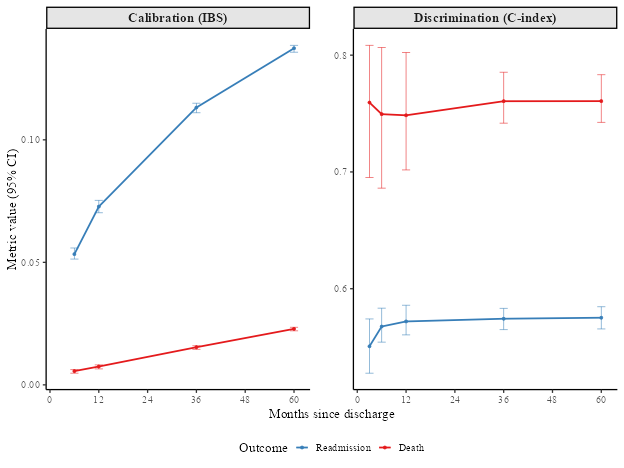

In [69]:
#| label: shap-criteria-int22-dual-cox-python-style-plot-by-time
.t0 <- proc.time()

# Prepare data (ensure proper extraction from results)
time_metrics <- results_ds_shap_py_upd_int$summary %>%
  dplyr::filter(Time != "Global") %>%
  dplyr::mutate(Time_num = as.numeric(as.character(Time)),
         # Ensure proper ordering of Risk factors
         Risk = factor(Risk, levels = c("Readmission", "Death")))

# Split by metric for separate panels or plots
cindex_data <- time_metrics %>% dplyr::filter(Metric == "Uno's C-Index")
ibs_data <- time_metrics %>% dplyr::filter(Metric == "IBS")

p_faceted_upd_int <- time_metrics %>%
  dplyr::mutate(Metric = ifelse(Metric == "Uno's C-Index", "Discrimination (C-index)", "Calibration (IBS)")) %>%
  ggplot(aes(x = Time_num, y = mean, color = Risk, fill = Risk)) +
  geom_line(linewidth = 1) +
  geom_point(size = 1.5) +
  geom_errorbar(aes(ymin = q025, ymax = q975), width = 2, alpha = 0.6, size = 0.5) +
  facet_wrap(~Metric, scales = "free_y", ncol = 2) +
  scale_color_manual(values = set1_colors) +
  scale_fill_manual(values = set1_colors) +
  scale_x_continuous(breaks = seq(0, 108, by = 12)) +
  labs(x = "Months since discharge",
       y = "Metric value (95% CI)",
       color = "Outcome",
       fill = "Outcome") +
  theme_classic(base_size = 16, base_family= tnr) +
  theme(legend.position = "bottom",
        strip.background = element_rect(fill = "grey90", color = "black"),
        strip.text = element_text(face = "bold", size = 16),
        panel.spacing = unit(2, "lines"))

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-int22-dual-cox-python-style-plot-by-time", .elapsed["elapsed"], .elapsed["elapsed"]/60))

p_faceted_upd_int

In [70]:
#| label: shap-criteria-int42-oob-ibs
.t0 <- proc.time()

gc()

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-int42-oob-ibs", .elapsed["elapsed"], .elapsed["elapsed"]/60))

# cph_evaluate_boot_oob_mi_corrected intentionally NOT used. AICc for record only.
aicc_readmit_shap_int_ds <- compute_mi_aicc(formula_shap_ds_readmit_interact_vif, py_corrected_datasets)
print(aicc_readmit_shap_int_ds)
aicc_death_shap_int_ds <- compute_mi_aicc(formula_shap_ds_death_interact_vif, py_corrected_datasets)
print(aicc_death_shap_int_ds)


[chunk: shap-criteria-int42-oob-ibs] 0.7 sec (0.0 min)

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272572.36
Mean AICc: 272572.51
Correction added (Penalty): 0.156455
Parameters (k): 34 | Effective Sample Size (Events): 15247
$mean_aicc
[1] 272572.5

$full_results
       aic correction     aicc  k n_events
1 272574.0  0.1564554 272574.1 34    15247
2 272572.3  0.1564554 272572.5 34    15247
3 272571.1  0.1564554 272571.3 34    15247
4 272571.7  0.1564554 272571.9 34    15247
5 272572.6  0.1564554 272572.8 34    15247


AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51489.19
Mean AICc: 51490.34
Correction added (Penalty): 1.149149
Parameters (k): 41 | Effective Sample Size (Events): 3039
$mean_aicc
[1] 51490.34

$full_results
       aic correction     aicc  k n_events
1 51484.78   1.149149 51485.93 41     3039
2 51492.25   1.149149 51493.40 41     3039
3 51491.46   1.149149 51492.61 41     3039
4 51489.53   1.149149 51490.68 41     3039
5 51487.94   1.149149 51489.09 41    

In [71]:
#| label: shap-criteria-int5-d1
.t0 <- proc.time()

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-int5-d1", .elapsed["elapsed"], .elapsed["elapsed"]/60))

compare_mi_models_d1(formula_shap_ds_readmit_interact_vif, formula_shap_ds_readmit_clean_updated, py_corrected_datasets)
compare_mi_models_d1(formula_shap_ds_death_interact_vif, formula_shap_ds_death_updated, py_corrected_datasets)


[chunk: shap-criteria-int5-d1] 0.0 sec (0.0 min)
Fitting the FULL model on 5 imputations...
Fitting the REDUCED model on 5 imputations...
Executing the Wald Test (D1)...

MODEL COMPARISON RESULT (D1 Statistic)
   test statistic df1      df2 dfcom      p.value        riv
 1 ~~ 2  4.991398  13 13747.43 15213 7.284592e-09 0.01794915
Fitting the FULL model on 5 imputations...
Fitting the REDUCED model on 5 imputations...
Executing the Wald Test (D1)...

MODEL COMPARISON RESULT (D1 Statistic)
   test statistic df1      df2 dfcom     p.value        riv
 1 ~~ 2   2.78817  11 2893.727  2998 0.001295259 0.02116442


In [72]:
#| label: shap-criteria-int6-calibrate
.t0 <- proc.time()

gc()
future::plan(future::sequential)
future::plan(future::multisession, workers = 6, maxSizeOfObjects = 2048 * 1024^2)
options(future.globals.maxSize = 2048 * 1024^2)  # 2 GiB

cal_readmit_shap_int_ds <- calibrate_cscox_aj_grouped_corr(
    formula_readmit      = formula_shap_ds_readmit_interact_vif,
    formula_death        = formula_shap_ds_death_interact_vif,
    data                 = py_corrected_datasets,
    times                = c(6, 12, 36, 60, 96),
    seed                 = 2125L,
    validation           = "cv",
    n_repeats            = 20L,
    compute_ici          = TRUE,
    ici_times            = 60,
    make_plots           = TRUE,
    parallel_cv          = TRUE,
    parallel_calibration = TRUE,
    future_scheduling    = 2,
    debug_fit            = TRUE
)
.cal_print(cal_readmit_shap_int_ds, "Readmit (interactions) -- AJ CIF")

cal_death_shap_int_ds <- calibrate_death_km_grouped(
    formula     = formula_shap_ds_death_interact_vif,
    data        = py_corrected_datasets,
    times       = c(6, 12, 36, 60, 96),
    seed        = 2125L,
    validation  = "cv",
    n_repeats   = 20L,
    parallel_cv = TRUE,
    verbose     = TRUE
)
.cal_print(cal_death_shap_int_ds, "Death (interactions) -- 1-KM")

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-int6-calibrate", .elapsed["elapsed"], .elapsed["elapsed"]/60))

Using 5 imputed dataset(s).
Validation: cv
Repetitions: 20 | same fold split across imputations within each repetition.
ICI: enabled at horizons 60.
Running CV predictions in parallel across 100 repetition x fold tasks... done
Calibrating 20 repetitions in parallel... done


There were 24 warnings (use warnings() to see them)



-- Readmit (interactions) -- AJ CIF --
 t_m    ICI    ECE   E/O
   6     NA 0.0030 0.991
  12     NA 0.0033 0.992
  36     NA 0.0043 0.991
  60 0.0099 0.0052 0.989
  96     NA 0.0047 0.984

calibrate_death_km_grouped: 20 repeats x 5 folds x 5 imputations = 500 fits (100 tasks)
  Pre-flight: running task 1 sequentially...
  Pre-flight OK: risk_mat dim=14105x5
  Pooling repetition 20/20

  Pooled calibration summary:
  time_months    ici_mean        ici_sd     ece_mean  eo_mean
1           6 0.002317434 0.00006384775 0.0006335618 1.006315
2          12 0.002973017 0.00008324012 0.0010149173 1.008689
3          36 0.006416955 0.00010558120 0.0018683698 1.012891
4          60 0.009056543 0.00013188584 0.0021097590 1.023397
5          96 0.013458686 0.00026950220 0.0035582559 1.070150

-- Death (interactions) -- 1-KM --
 t_m    ICI    ECE   E/O
   6 0.0023 0.0006 1.006
  12 0.0030 0.0010 1.009
  36 0.0064 0.0019 1.013
  60 0.0091 0.0021 1.023
  96 0.0135 0.0036 1.070

[chunk: shap-criteria


## Functional forms



[chunk: shap-criteria-func-form-get-shap-values] 1.8 sec (0.0 min)


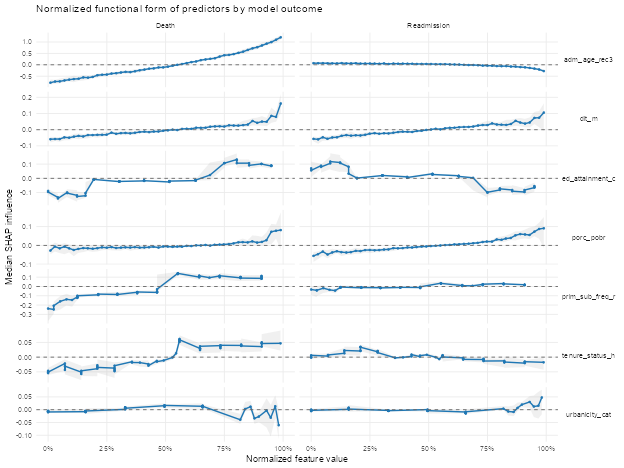

In [79]:
#| label: shap-criteria-func-form-get-shap-values
.t0 <- proc.time()


if (grepl("Escritorio", project_root)) {
    fx_form_path<-
      find_latest_file(
        file.path(gsub("Escritorio2025", "Escritorio", project_root), "cons2025", "_out"),
                    "ds8_functional_forms_dual_multih", "xlsx"
      )
} else {
  fx_form_path<-
  find_latest_file(
    file.path(project_root, "cons", "_out"),
                      "ds8_functional_forms_dual_multih", "xlsx"
  )
}

# -------------------------------------------------------------------------
# 1. Identify D_60m_* and R_60m_* sheets
# -------------------------------------------------------------------------
all_sheets    <- readxl::excel_sheets(fx_form_path)
target_sheets <- all_sheets[stringr::str_detect(all_sheets, "^[DR]_60m_")]

# -------------------------------------------------------------------------
# 2. Map truncated sheet names back to full Predictor names
# -------------------------------------------------------------------------
summary_df <- readxl::read_excel(fx_form_path, sheet = "Effects_Summary_Horizon")

sheet_to_predictor <- purrr::map_chr(target_sheets, function(sheet) {
  suffix     <- stringr::str_remove(sheet, "^[DR]_60m_")
  candidates <- summary_df$Predictor[startsWith(summary_df$Predictor, suffix)]
  if (length(candidates) == 1) candidates else suffix
})
names(sheet_to_predictor) <- target_sheets

# -------------------------------------------------------------------------
# 3. Read all target sheets and stack into one long data frame
# -------------------------------------------------------------------------
spc_tbl_ <- purrr::map_dfr(target_sheets, function(sheet) {
  outcome <- if (stringr::str_starts(sheet, "D_60m_")) "Death" else "Readmission"
  
  readxl::read_excel(fx_form_path, sheet = sheet) |>
    dplyr::mutate(
      Outcome   = outcome,
      Predictor = sheet_to_predictor[[sheet]],
      .before   = 1
    )
})

# -------------------------------------------------------------------------
# 4. Normalization / binning / summary (exact logic you provided)
# -------------------------------------------------------------------------
shap_norm <- spc_tbl_ |>
  dplyr::filter(
    is.finite(Feature_Value),
    is.finite(SHAP_Impact)
  ) |>
  dplyr::group_by(Predictor) |>
  dplyr::mutate(
    n_unique = dplyr::n_distinct(Feature_Value),
    Feature_Value_norm = dplyr::case_when(
      n_unique <= 1 ~ 0.5,
      n_unique <= 10 ~ (dplyr::dense_rank(Feature_Value) - 1) / (n_unique - 1),
      TRUE ~ dplyr::percent_rank(Feature_Value)
    )
  ) |>
  dplyr::ungroup()

shap_curve_norm <- shap_norm |>
  dplyr::group_by(Outcome, Predictor) |>
  dplyr::mutate(value_bin = dplyr::ntile(Feature_Value_norm, 50)) |>
  dplyr::group_by(Outcome, Predictor, value_bin) |>
  dplyr::summarise(
    x_norm       = median(Feature_Value_norm, na.rm = TRUE),
    x_raw_median = median(Feature_Value, na.rm = TRUE),
    shap_median  = median(SHAP_Impact, na.rm = TRUE),
    shap_q25     = quantile(SHAP_Impact, 0.25, na.rm = TRUE),
    shap_q75     = quantile(SHAP_Impact, 0.75, na.rm = TRUE),
    .groups      = "drop"
  )

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-func-form-get-shap-values", .elapsed["elapsed"], .elapsed["elapsed"]/60))

# -------------------------------------------------------------------------
# 5. Plot (exact ggplot code you provided)
# -------------------------------------------------------------------------
ggplot2::ggplot(dplyr::filter(shap_curve_norm, !grepl("eva_*",Predictor)), 
ggplot2::aes(x = x_norm, y = shap_median)) +
  ggplot2::geom_ribbon(
    ggplot2::aes(ymin = shap_q25, ymax = shap_q75),
    alpha = 0.2, fill = "grey70"
  ) +
  ggplot2::geom_line(linewidth = 0.8, colour = "#1f77b4") +
  ggplot2::geom_point(size = 0.8, colour = "#1f77b4") +
  ggplot2::geom_hline(yintercept = 0, linetype = "dashed", colour = "grey40") +
  ggplot2::facet_grid(Predictor ~ Outcome, scales = "free_y") +
  ggplot2::scale_x_continuous(
    labels = scales::percent_format(),
    limits = c(0, 1)
  ) +
  ggplot2::labs(
    x = "Normalized feature value",
    y = "Median SHAP influence",
    title = "Normalized functional form of predictors by model outcome"
  ) +
  ggplot2::theme_minimal(base_size = 11) +
  ggplot2::theme(
    strip.text.y   = ggplot2::element_text(angle = 0),
    panel.grid.minor = ggplot2::element_blank()
  )


[chunk: shap-criteria-func-form-get-shap-values2] 0.0 sec (0.0 min)


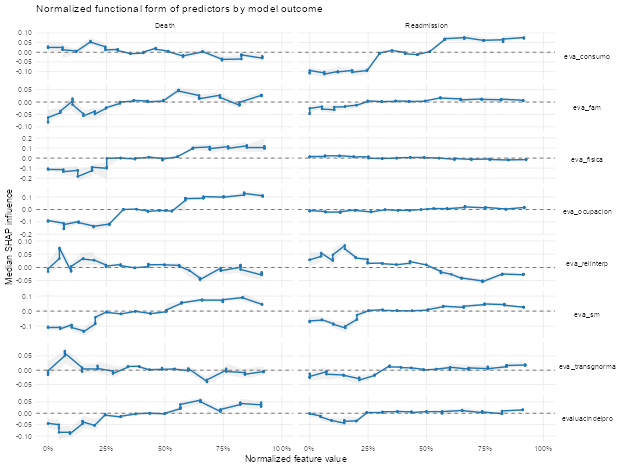

In [80]:
#| label: shap-criteria-func-form-get-shap-values2
.t0 <- proc.time()

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-func-form-get-shap-values2", .elapsed["elapsed"], .elapsed["elapsed"]/60))

ggplot2::ggplot(dplyr::filter(shap_curve_norm, grepl("eva_*",Predictor)), 
ggplot2::aes(x = x_norm, y = shap_median)) +
  ggplot2::geom_ribbon(
    ggplot2::aes(ymin = shap_q25, ymax = shap_q75),
    alpha = 0.2, fill = "grey70"
  ) +
  ggplot2::geom_line(linewidth = 0.8, colour = "#1f77b4") +
  ggplot2::geom_point(size = 0.8, colour = "#1f77b4") +
  ggplot2::geom_hline(yintercept = 0, linetype = "dashed", colour = "grey40") +
  ggplot2::facet_grid(Predictor ~ Outcome, scales = "free_y") +
  ggplot2::scale_x_continuous(
    labels = scales::percent_format(),
    limits = c(0, 1)
  ) +
  ggplot2::labs(
    x = "Normalized feature value",
    y = "Median SHAP influence",
    title = "Normalized functional form of predictors by model outcome"
  ) +
  ggplot2::theme_minimal(base_size = 11) +
  ggplot2::theme(
    strip.text.y   = ggplot2::element_text(angle = 0),
    panel.grid.minor = ggplot2::element_blank()
  )

Predictores en datos sin etiqueta (no graficados): ed_attainment_c, evaluacindelpro, prim_sub_freq_r, tenure_status_h
Etiquetas sin datos (revisar nombre exacto): ed_attainment_corr, evaluacindelprocesoteraputico, prim_sub_freq_rec, tenure_status_household
Functional forms of SHAP influences by predictor and outcome using normalized values. Note. Lines represent the median SHAP impact on the log-hazard for each outcome; shaded bands indicate the interquartile range (IQR, 25th to 75th percentiles). Blue lines: readmission; red lines: mortality. The X-axis reflects the relative position of the predictor value; ordinal values are grouped into 50 equally spaced values (0%, numerically lowest category; 100%, highest category). Interpretive anchors: housing situation, 0% owned/provided/paying mortgage to 100% irregular occupation; urbanization, 0% urban to 100% rural; educational attainment, 0% above secondary education to 100% primary education or less; substance use frequency, 0% one day o

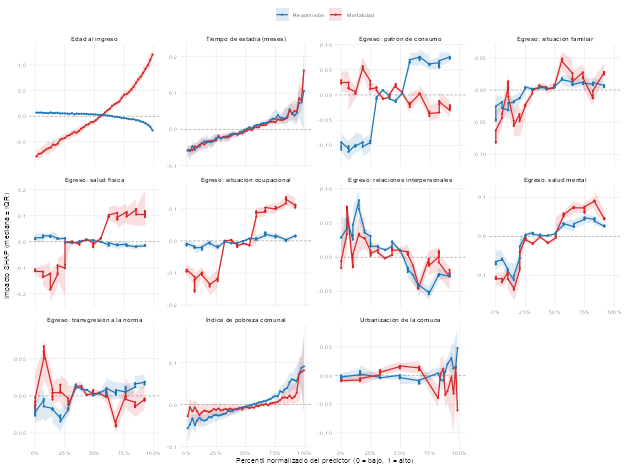

In [119]:
#| label: shap-criteria-func-form-plot-combined
#| fig-width: 11
#| fig-height: 7
#| fig-cap: "Formas funcionales"

.t0 <- proc.time()

## 1. Etiquetas en español y orden de los paneles (igual a la figura) ----
.lab_pred <- c(
  adm_age_rec3                  = "Edad al ingreso",
  dit_m                         = "Tiempo de estadía (meses)",
  ed_attainment_corr            = "Escolaridad",
  eva_consumo                   = "Egreso: patrón de consumo",
  eva_fam                       = "Egreso: situación familiar",
  eva_fisica                    = "Egreso: salud física",
  eva_ocupacion                 = "Egreso: situación ocupacional",
  eva_relinterp                 = "Egreso: relaciones interpersonales",
  eva_sm                        = "Egreso: salud mental",
  eva_transgnorma               = "Egreso: transgresión a la norma",
  evaluacindelprocesoteraputico = "Egreso: proceso terapéutico",
  porc_pobr                     = "Índice de pobreza comunal",
  prim_sub_freq_rec             = "Frecuencia de consumo al ingreso",
  tenure_status_household       = "Situación de vivienda",
  urbanicity_cat                = "Urbanización de la comuna"
)

## diagnóstico: avisa si algún nombre no calza con shap_curve_norm
.missing <- setdiff(unique(shap_curve_norm$Predictor), names(.lab_pred))
if (length(.missing)) message("Predictores en datos sin etiqueta (no graficados): ", paste(.missing, collapse = ", "))
.absent  <- setdiff(names(.lab_pred), unique(shap_curve_norm$Predictor))
if (length(.absent))  message("Etiquetas sin datos (revisar nombre exacto): ", paste(.absent, collapse = ", "))

.plot_df <- shap_curve_norm |>
  dplyr::filter(Predictor %in% names(.lab_pred)) |>
  dplyr::mutate(
    Predictor_lab = factor(.lab_pred[Predictor], levels = unname(.lab_pred)),
    Desenlace     = factor(dplyr::recode(Outcome,
                              Readmission = "Readmisión",
                              Death       = "Mortalidad"),
                           levels = c("Readmisión", "Mortalidad"))
  )

## 2. Figura ----
.cols <- c("Readmisión" = "#1f77b4", "Mortalidad" = "#d62728")

p_funcform <- ggplot2::ggplot(.plot_df,
    ggplot2::aes(x = x_norm, y = shap_median, colour = Desenlace, fill = Desenlace)) +
  ggplot2::geom_hline(yintercept = 0, linetype = "dashed", colour = "grey55", linewidth = 0.3) +
  ggplot2::geom_ribbon(ggplot2::aes(ymin = shap_q25, ymax = shap_q75),
                       alpha = 0.15, colour = NA) +
  ggplot2::geom_line(linewidth = 0.7) +
  ggplot2::geom_point(size = 0.7) +
  ggplot2::facet_wrap(~ Predictor_lab, ncol = 4, nrow=3, scales = "free_y") +
  ggplot2::scale_x_continuous(labels = scales::percent_format(accuracy = 1),
                              limits = c(0, 1), breaks = c(0, .25, .5, .75, 1)) +
  ggplot2::scale_colour_manual(values = .cols) +
  ggplot2::scale_fill_manual(values = .cols) +
  ggplot2::labs(
    x = "Percentil normalizado del predictor (0 = bajo, 1 = alto)",
    y = "Impacto SHAP (mediana ± IQR)",
    colour = NULL, fill = NULL
  ) +
  ggplot2::theme_minimal(base_size = 9) +
  ggplot2::theme(
    legend.position  = "top",
    strip.text       = ggplot2::element_text(size = 7.5, face = "bold"),
    panel.grid.minor = ggplot2::element_blank(),
    panel.spacing    = ggplot2::unit(0.6, "lines")
  )

p_funcform

message(paste0("Functional forms of SHAP influences by predictor and outcome using normalized values. Note. Lines represent the median SHAP impact on the log-hazard for each outcome; shaded bands indicate the interquartile range (IQR, 25th to 75th percentiles). Blue lines: readmission; red lines: mortality. The X-axis reflects the relative position of the predictor value; ordinal values are grouped into 50 equally spaced values (0%, numerically lowest category; 100%, highest category). Interpretive anchors: housing situation, 0% owned/provided/paying mortgage to 100% irregular occupation; urbanization, 0% urban to 100% rural; educational attainment, 0% above secondary education to 100% primary education or less; substance use frequency, 0% one day or less per week to 100% daily; discharge assessments (therapeutic process, substance use, family, occupational, interpersonal relationships, mental health, physical health, transgression), 0% high achievement to 100% minimal achievement. Continuous variables (age, communal poverty, length of stay) were normalized by percentiles, where 0% and 100% approximate the observed minimum and maximum."))

## 3. Exportar para la tesis (descomenta) ----
# ggplot2::ggsave("_out/fig_shap_funcform_norm.png", p_funcform, width = 11, height = 7, dpi = 320)
# ggplot2::ggsave("_out/fig_shap_funcform_norm.pdf", p_funcform, width = 11, height = 7)

.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec\n", "shap-criteria-func-form-plot-combined", .elapsed["elapsed"]))


In [81]:
#| label: shap-criteria-func-form-linear-terms-and-scores
.t0 <- proc.time()

# helper: 3-level ordinal score (0 ref, 1 intermedio, 2 minimo)
make_3level_score <- function(intermedio, minimo) {
  dplyr::case_when(
    minimo == 1 ~ 2,
    intermedio == 1 ~ 1,
    TRUE ~ 0
  )
}
add_boot_linear_terms <- function(df) {
  df %>%
    dplyr::mutate(
      eva_consumo_score     = eva_consumo_logro_intermedio * 1 + eva_consumo_logro_minimo * 2,
      eva_ocupacion_score   = eva_ocupacion_logro_intermedio * 1 + eva_ocupacion_logro_minimo * 2,
      eva_fisica_score      = eva_fisica_logro_intermedio * 1 + eva_fisica_logro_minimo * 2,
      eva_relinterp_score   = eva_relinterp_logro_intermedio * 1 + eva_relinterp_logro_minimo * 2,
      eva_sm_score          = eva_sm_logro_intermedio * 1 + eva_sm_logro_minimo * 2,
      eva_transgnorma_score = eva_transgnorma_logro_intermedio * 1 + eva_transgnorma_logro_minimo * 2,
      eva_fam_score         = eva_fam_logro_intermedio * 1 + eva_fam_logro_minimo * 2,
      ed_attainment_score   = ed_attainment_corr_2_completed_high_school_or_less * 1 +
                              ed_attainment_corr_3_completed_primary_school_or_less * 2,
      prim_sub_freq_score   = prim_sub_freq_rec_2_2_6_days_wk * 1 + prim_sub_freq_rec_3_daily * 2
    )
}
py_corrected_datasets_boot <- lapply(py_corrected_datasets, add_boot_linear_terms)

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-func-form-linear-terms-and-scores", .elapsed["elapsed"], .elapsed["elapsed"]/60))



[chunk: shap-criteria-func-form-linear-terms-and-scores] 0.1 sec (0.0 min)


In [82]:
formula_shap_ds_readmit_clean_updated

Surv(readmit_time_from_disch_m, readmit_event) ~ primary_sub_mod_cocaine_paste + 
    primary_sub_mod_cocaine_powder + primary_sub_mod_alcohol + 
    primary_sub_mod_others + sex_rec_woman + ethnicity + adm_age_rec3 + 
    eva_consumo_logro_intermedio + eva_consumo_logro_minimo + 
    ed_attainment_corr_2_completed_high_school_or_less + ed_attainment_corr_3_completed_primary_school_or_less + 
    dg_psiq_cie_10_dg + eva_sm_logro_intermedio + eva_sm_logro_minimo + 
    dit_m + occupation_condition_corr24_unemployed + occupation_condition_corr24_inactive + 
    tr_outcome_referral + tr_outcome_dropout + tr_outcome_adm_discharge_adm_reasons + 
    polysubstance_strict + strata(plan_type_strata) + strata(tr_outcome_adm_discharge_rule_violation_undet)

In [83]:
#| label: shap-criteria-func-form-readmit-constructors
.t0 <- proc.time()
gc()
# Functional-form candidates for the ds63-SELECTED continuous readmission predictors ONLY:
# age (adm_age_rec3) and treatment duration (dit_m). porc_pobr is NOT in the DeepSurv readmit
# model, so no poverty functional form is tested. Built on the post-NPH base WITHOUT
# interaction crossings (interactions are handled in the Interactions section).
# PRIORITY: clear concave curve (quad_gain 0.18)
form_readmit_ds_age_poly2 <- update(formula_shap_ds_readmit_clean_updated, . ~ . - adm_age_rec3 + poly(adm_age_rec3, 2))
form_readmit_ds_age_ns3   <- update(formula_shap_ds_readmit_clean_updated, . ~ . - adm_age_rec3 + splines::ns(adm_age_rec3, df = 3))
# dit_m casi lineal: solo cola derecha -> probar log/ns, esperar nada (xgb3 ya las empeoró)
form_readmit_ds_dit_log   <- update(formula_shap_ds_readmit_clean_updated, . ~ . - dit_m + log(dit_m + 1))
form_readmit_ds_dit_ns3   <- update(formula_shap_ds_readmit_clean_updated, . ~ . - dit_m + splines::ns(dit_m, df = 3))

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-func-form-readmit-constructors", .elapsed["elapsed"], .elapsed["elapsed"]/60))



[chunk: shap-criteria-func-form-readmit-constructors] 0.8 sec (0.0 min)


### Age at admission

In [84]:
#| label: shap-criteria-func-form-linear-terms-vs-ns-readmit-test
.t0 <- proc.time()

cat("\nComparing linear age terms vs. polynomial and spline age terms for readmission:\n")
compute_mi_aicc(formula_shap_ds_readmit_clean_updated  , py_corrected_datasets)
compute_mi_aicc(form_readmit_ds_age_poly2  , py_corrected_datasets_boot)
compute_mi_aicc(form_readmit_ds_age_ns3  , py_corrected_datasets_boot)

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-func-form-linear-terms-vs-ns-readmit-test", .elapsed["elapsed"], .elapsed["elapsed"]/60))


Comparing linear age terms vs. polynomial and spline age terms for readmission:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272616.09
Mean AICc: 272616.15
Correction added (Penalty): 0.060690
Parameters (k): 21 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272546.57
Mean AICc: 272546.63
Correction added (Penalty): 0.066474
Parameters (k): 22 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272553.79
Mean AICc: 272553.86
Correction added (Penalty): 0.072522
Parameters (k): 23 | Effective Sample Size (Events): 15247

[chunk: shap-criteria-func-form-linear-terms-vs-ns-readmit-test] 13.4 sec (0.2 min)


In [85]:
#| label: shap-criteria-func-form-linear-terms-vs-ns-readm-test
.t0 <- proc.time()

gc()

results_shap_py_int_readm_ds_age_poly2 <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_ds_age_poly2,#formula_shap_ds_readmit_interact,
  formula_death = formula_shap_ds_death_updated,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3, 6, 12, 36, 60)
)
results_shap_py_int_readm_ds_age_ns3 <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_ds_age_ns3,#formula_shap_ds_readmit_interact,
  formula_death = formula_shap_ds_death_updated,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3, 6, 12, 36, 60)
)

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-func-form-linear-terms-vs-ns-readm-test", .elapsed["elapsed"], .elapsed["elapsed"]/60))

rbind.data.frame(
  cbind(model= "Linear", results_shap_py_upd$summary),
  cbind.data.frame(model= "Poly df=2", results_shap_py_int_readm_ds_age_poly2$summary), 
  cbind.data.frame(model= "Age spline df=3", results_shap_py_int_readm_ds_age_ns3$summary)
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Readmission") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, readmission model with spline age terms")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....

[chunk: shap-criteria-func-form-linear-terms-vs-ns-readm-test] 350.8 sec (5.8 min)




Table: Global C-index and IBS summary, readmission model with spline age terms

|model           |Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:---------------|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear          |Readmission |IBS           |Global | 0.1373792| 0.0007864| 0.1358191| 0.1386139| 25|
|Poly df=2       |Readmission |IBS           |Global | 0.1373348| 0.0007754| 0.1358543| 0.1385252| 25|
|Age spline df=3 |Readmission |IBS           |Global | 0.1373419| 0.0007748| 0.1358596| 0.1385293| 25|
|Linear          |Readmission |Uno's C-Index |Global | 0.5741441| 0.0074333| 0.5604630| 0.5862024| 25|
|Poly df=2       |Readmission |Uno's C-Index |Global | 0.5756965| 0.0069630| 0.5633669| 0.5861635| 25|
|Age spline df=3 |Readmission |Uno's C-Index |Global | 0.5758337| 0.0070011| 0.5632707| 0.5864903| 25|

#### Death

In [86]:
formula_shap_ds_death_updated 

Surv(death_time_from_disch_m, death_event) ~ adm_age_rec3 + primary_sub_mod_cocaine_paste + 
    primary_sub_mod_cocaine_powder + primary_sub_mod_alcohol + 
    primary_sub_mod_others + occupation_condition_corr24_unemployed + 
    occupation_condition_corr24_inactive + any_phys_dx + prim_sub_freq_rec_2_2_6_days_wk + 
    prim_sub_freq_rec_3_daily + cohabitation_family_of_origin + 
    cohabitation_with_couple_children + cohabitation_others + 
    eva_ocupacion_logro_intermedio + eva_ocupacion_logro_minimo + 
    eva_fisica_logro_intermedio + eva_fisica_logro_minimo + sex_rec_woman + 
    tr_outcome_referral + tr_outcome_dropout + tr_outcome_adm_discharge_adm_reasons + 
    adm_motive_sanitary_sector + adm_motive_another_sud_facility_fonodrogas_senda_previene + 
    adm_motive_justice_sector + adm_motive_other + polysubstance_strict + 
    eva_sm_logro_intermedio + eva_sm_logro_minimo + ed_attainment_corr_2_completed_high_school_or_less + 
    ed_attainment_corr_3_completed_primary_sch

In [87]:
#| label: shap-criteria-func-form-linear-terms-vs-ns-death
.t0 <- proc.time()

# Age functional form for death, built on the post-NPH base WITHOUT interaction crossings.
form_death_ds_age_linear <- formula_shap_ds_death_updated
form_death_ds_age_ns3 <- update(formula_shap_ds_death_updated,
                                . ~ . - adm_age_rec3 + splines::ns(adm_age_rec3, df = 3))
form_death_ds_age_poly2 <- update(formula_shap_ds_death_updated, . ~ . - adm_age_rec3 + poly(adm_age_rec3, 2))              # cheaper (1 gl)

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-func-form-linear-terms-vs-ns-death", .elapsed["elapsed"], .elapsed["elapsed"]/60))



[chunk: shap-criteria-func-form-linear-terms-vs-ns-death] 0.0 sec (0.0 min)


In [88]:
#| label: shap-criteria-func-form-linear-terms-vs-ns-death-aicc
.t0 <- proc.time()

cat("\nComparing linear age terms vs. spline age terms for death:\n")
compute_mi_aicc(form_death_ds_age_linear, py_corrected_datasets_boot)
compute_mi_aicc(form_death_ds_age_ns3, py_corrected_datasets_boot)
compute_mi_aicc(form_death_ds_age_poly2, py_corrected_datasets_boot)

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-func-form-linear-terms-vs-ns-death-aicc", .elapsed["elapsed"], .elapsed["elapsed"]/60))


Comparing linear age terms vs. spline age terms for death:

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51500.72
Mean AICc: 51501.34
Correction added (Penalty): 0.618351
Parameters (k): 30 | Effective Sample Size (Events): 3039

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51483.11
Mean AICc: 51483.81
Correction added (Penalty): 0.702595
Parameters (k): 32 | Effective Sample Size (Events): 3039

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51484.65
Mean AICc: 51485.31
Correction added (Penalty): 0.659794
Parameters (k): 31 | Effective Sample Size (Events): 3039

[chunk: shap-criteria-func-form-linear-terms-vs-ns-death-aicc] 20.0 sec (0.3 min)


In [89]:
#| label: shap-criteria-func-form-linear-terms-vs-ns-death-test
.t0 <- proc.time()

gc()

results_shap_py_int_death_ds_age_ns3 <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_ds_readmit_clean_updated,#formula_shap_ds_readmit_interact,
  formula_death = form_death_ds_age_ns3,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3, 6, 12, 36, 60)
)

results_shap_py_int_death_ds_age_poly2 <- evaluate_dual_cox_python_style(
  formula_readmit = formula_shap_ds_readmit_clean_updated,#formula_shap_ds_readmit_interact,
  formula_death = form_death_ds_age_poly2,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3, 6, 12, 36, 60)
)


if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-func-form-linear-terms-vs-ns-death-test", .elapsed["elapsed"], .elapsed["elapsed"]/60))

rbind.data.frame(
  cbind(model= "Linear", results_shap_py_upd$summary),
  cbind.data.frame(model= "Age spline df=3", results_shap_py_int_death_ds_age_ns3$summary),
  cbind.data.frame(model= "Cuadratic age", results_shap_py_int_death_ds_age_poly2$summary)
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Death") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, readmission model with spline age terms")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....

[chunk: shap-criteria-func-form-linear-terms-vs-ns-death-test] 354.1 sec (5.9 min)




Table: Global C-index and IBS summary, readmission model with spline age terms

|model           |Risk  |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:---------------|:-----|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear          |Death |IBS           |Global | 0.0228523| 0.0003863| 0.0220559| 0.0235118| 25|
|Age spline df=3 |Death |IBS           |Global | 0.0228361| 0.0003862| 0.0220243| 0.0234895| 25|
|Cuadratic age   |Death |IBS           |Global | 0.0228376| 0.0003858| 0.0220303| 0.0234905| 25|
|Linear          |Death |Uno's C-Index |Global | 0.7422588| 0.0112509| 0.7239413| 0.7609696| 25|
|Age spline df=3 |Death |Uno's C-Index |Global | 0.7427962| 0.0111208| 0.7241600| 0.7609039| 25|
|Cuadratic age   |Death |Uno's C-Index |Global | 0.7424344| 0.0114611| 0.7237520| 0.7608815| 25|

### Treatment duration

In [90]:
#| label: shap-criteria-func-form-dit-linear-terms-vs-log-ns-readm
.t0 <- proc.time()

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-func-form-dit-linear-terms-vs-log-ns-readm", .elapsed["elapsed"], .elapsed["elapsed"]/60))

compute_mi_aicc(formula_shap_ds_readmit_clean_updated, py_corrected_datasets_boot)
compute_mi_aicc(form_readmit_ds_dit_log, py_corrected_datasets_boot)
compute_mi_aicc(form_readmit_ds_dit_ns3, py_corrected_datasets_boot)


[chunk: shap-criteria-func-form-dit-linear-terms-vs-log-ns-readm] 0.0 sec (0.0 min)

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272616.09
Mean AICc: 272616.15
Correction added (Penalty): 0.060690
Parameters (k): 21 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272591.21
Mean AICc: 272591.27
Correction added (Penalty): 0.060690
Parameters (k): 21 | Effective Sample Size (Events): 15247

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272588.28
Mean AICc: 272588.35
Correction added (Penalty): 0.072522
Parameters (k): 23 | Effective Sample Size (Events): 15247


$mean_aicc
[1] 272588.3

$full_results
       aic correction     aicc  k n_events
1 272589.2 0.07252184 272589.3 23    15247
2 272587.1 0.07252184 272587.2 23    15247
3 272588.8 0.07252184 272588.9 23    15247
4 272587.8 0.07252184 272587.8 23    15247
5 272588.5 0.07252184 272588.5 23    15247


In [91]:
#| label: shap-criteria-func-form-dit-linear-terms-vs-ns-readm-test
.t0 <- proc.time()

gc()

results_shap_py_int_readm_ds_dit_log <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_ds_dit_log,#formula_shap_ds_readmit_interact,
  formula_death = formula_shap_ds_death_updated,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3, 6, 12, 36, 60)
)
results_shap_py_int_readm_ds_dit_ns3 <- evaluate_dual_cox_python_style(
  formula_readmit = form_readmit_ds_dit_ns3,#formula_shap_ds_readmit_interact,
  formula_death = formula_shap_ds_death_updated,
  imputed_list = py_corrected_datasets_boot,
  k_folds = 5,
  eval_times = c(3, 6, 12, 36, 60)
)

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-func-form-dit-linear-terms-vs-ns-readm-test", .elapsed["elapsed"], .elapsed["elapsed"]/60))

rbind.data.frame(
  cbind(model= "Linear", results_shap_py_upd$summary),
  cbind.data.frame(model= "Log", results_shap_py_int_readm_ds_dit_log$summary), 
  cbind.data.frame(model= "DIT spline df=3", results_shap_py_int_readm_ds_dit_ns3$summary)
) |> 
  dplyr::filter( Time %in% c("Global"), Risk=="Readmission") |> 
  dplyr::arrange( Metric) |>
  knitr::kable("markdown", caption= "Global C-index and IBS summary, readmission model with log & spline DIT terms")

Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....

[chunk: shap-criteria-func-form-dit-linear-terms-vs-ns-readm-test] 353.4 sec (5.9 min)




Table: Global C-index and IBS summary, readmission model with log & spline DIT terms

|model           |Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|
|:---------------|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|
|Linear          |Readmission |IBS           |Global | 0.1373792| 0.0007864| 0.1358191| 0.1386139| 25|
|Log             |Readmission |IBS           |Global | 0.1373257| 0.0007897| 0.1357489| 0.1385661| 25|
|DIT spline df=3 |Readmission |IBS           |Global | 0.1373285| 0.0008024| 0.1357248| 0.1385875| 25|
|Linear          |Readmission |Uno's C-Index |Global | 0.5741441| 0.0074333| 0.5604630| 0.5862024| 25|
|Log             |Readmission |Uno's C-Index |Global | 0.5748703| 0.0071586| 0.5615354| 0.5859209| 25|
|DIT spline df=3 |Readmission |Uno's C-Index |Global | 0.5749280| 0.0070588| 0.5616774| 0.5852002| 25|

### Test of categorical vs. continuous transformation

In [95]:
#| label: shap-criteria-func-form-cat-vs-cont
.t0 <- proc.time()

if (grepl("Escritorio", project_root)) {
  source(paste0(gsub("Escritorio2025", "Escritorio/", project_root), "/cons2025/_alt_scripts/replace_cat_with_continuous.R"))
} else {
  source(paste0(project_root, "/cons/_alt_scripts/replace_cat_with_continuous.R"))
}

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-func-form-cat-vs-cont", .elapsed["elapsed"], .elapsed["elapsed"]/60))


[chunk: shap-criteria-func-form-cat-vs-cont] 0.0 sec (0.0 min)


In [96]:
#| label: shap-criteria-func-form-eva-consumo-cont-vs-cat-readm
.t0 <- proc.time()

# Ordinal (0/1/2) vs categorical-dummy test, ONE predictor at a time, for the ds63-SELECTED
# ordinal families in the readmission model: eva_consumo, eva_sm, ed_attainment.
# Decision is on C-index/IBS (eval_times-matched baseline); AICc is for record only.
score_map <- list(
  eva_consumo = list(
    cont = "eva_consumo_score",
    cat  = c("eva_consumo_logro_intermedio", "eva_consumo_logro_minimo")
  ),
  eva_sm = list(
    cont = "eva_sm_score",
    cat  = c("eva_sm_logro_intermedio", "eva_sm_logro_minimo")
  ),
  ed_attainment = list(
    cont = "ed_attainment_score",
    cat  = c(
      "ed_attainment_corr_2_completed_high_school_or_less",
      "ed_attainment_corr_3_completed_primary_school_or_less"
    )
  )
)
base_readmit <- formula_shap_ds_readmit_clean_updated
base_death   <- formula_shap_ds_death_updated

aic_cat <- compute_mi_aicc(base_readmit, py_corrected_datasets_boot)
aic_cat_val <- aic_cat$mean_aicc
cat("Base categorical AICc:", aic_cat_val, "\n\n")

results_list <- list()
for (nm in names(score_map)) {
  m <- score_map[[nm]]
  cat("\n>>> Processing:", nm, "<<<\n")
  f_readmit_cont <- replace_cat_with_continuous(base_readmit, m$cat, m$cont)
  aic_cont <- compute_mi_aicc(f_readmit_cont, py_corrected_datasets_boot)
  aic_cont_val <- aic_cont$mean_aicc
  cat("  AICc categorical:", aic_cat_val, "| continuous:", aic_cont_val,
      "| delta:", round(aic_cont_val - aic_cat_val, 3), "\n")
  gc()
  res <- evaluate_dual_cox_python_style(
    formula_readmit = f_readmit_cont,
    formula_death   = base_death,
    imputed_list    = py_corrected_datasets_boot,
    k_folds         = 5,
    eval_times      = c(3, 6, 12, 36, 60)
  )
  results_list[[nm]] <- list(result = res, aic_cat = aic_cat_val,
                             aic_cont = aic_cont_val, aic_delta = aic_cont_val - aic_cat_val)
  cat("  Done.\n")
}

summary_df <- dplyr::bind_rows(lapply(names(results_list), function(nm) {
  entry <- results_list[[nm]]
  entry$result$summary |>
    dplyr::filter(Time == "Global") |>
    dplyr::mutate(model = nm, aic_cat = entry$aic_cat,
                  aic_cont = entry$aic_cont, aic_delta = entry$aic_delta)
}))

if (exists("results_shap_py_upd")) {
  base_df <- results_shap_py_upd$summary |>
    dplyr::filter(Time == "Global") |>
    dplyr::mutate(model = "categorical_base", aic_cat = aic_cat_val,
                  aic_cont = NA_real_, aic_delta = NA_real_)
  summary_df <- dplyr::bind_rows(base_df, summary_df)
}

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-func-form-eva-consumo-cont-vs-cat-readm", .elapsed["elapsed"], .elapsed["elapsed"]/60))

summary_df |>
  dplyr::arrange(Risk, Metric, model) |>
  dplyr::filter(Risk == "Readmission") |>
  knitr::kable("markdown", caption = "Dual-Cox: one-at-a-time continuous replacement (readmission, ds63-selected ordinals)")



AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272616.09
Mean AICc: 272616.15
Correction added (Penalty): 0.060690
Parameters (k): 21 | Effective Sample Size (Events): 15247
Base categorical AICc: 272616.2 


>>> Processing: eva_consumo <<<

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272620.02
Mean AICc: 272620.08
Correction added (Penalty): 0.055169
Parameters (k): 20 | Effective Sample Size (Events): 15247
  AICc categorical: 272616.2 | continuous: 272620.1 | delta: 3.922 
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
  Done.

>>> Processing: eva_sm <<<

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  272622.19
Mean AICc: 272622.25
Correction added (Penalty): 0.055169
Parameters (k): 20 | Effective Sample Size (Events): 15247
  AICc categorical: 272616.2 | continuous: 272622.2 | delta: 6.093 
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: 



Table: Dual-Cox: one-at-a-time continuous replacement (readmission, ds63-selected ordinals)

|Risk        |Metric        |Time   |      mean|        sd|      q025|      q975|  n|model            |  aic_cat| aic_cont| aic_delta|
|:-----------|:-------------|:------|---------:|---------:|---------:|---------:|--:|:----------------|--------:|--------:|---------:|
|Readmission |IBS           |Global | 0.1373792| 0.0007864| 0.1358191| 0.1386139| 25|categorical_base | 272616.2|         |          |
|Readmission |IBS           |Global | 0.1373780| 0.0007861| 0.1358373| 0.1386216| 25|ed_attainment    | 272616.2| 272618.1|  1.946676|
|Readmission |IBS           |Global | 0.1373894| 0.0007913| 0.1358185| 0.1386362| 25|eva_consumo      | 272616.2| 272620.1|  3.921928|
|Readmission |IBS           |Global | 0.1373910| 0.0007748| 0.1358553| 0.1386112| 25|eva_sm           | 272616.2| 272622.2|  6.093034|
|Readmission |Uno's C-Index |Global | 0.5741441| 0.0074333| 0.5604630| 0.5862024| 25|categorica

#### Death (mental health evaluation)

In [97]:
#| label: shap-criteria-func-form-cat-vs-cont-death
.t0 <- proc.time()

gc()
future::plan(future::sequential)

base_readmit <- formula_shap_ds_readmit_clean_updated
base_death   <- formula_shap_ds_death_updated

# ds63-SELECTED ordinal families in the death model.
score_map_death <- list(
  eva_sm = list(
    cont = "eva_sm_score",
    cat  = c("eva_sm_logro_intermedio", "eva_sm_logro_minimo")
  ),
  eva_ocupacion = list(
    cont = "eva_ocupacion_score",
    cat  = c("eva_ocupacion_logro_intermedio", "eva_ocupacion_logro_minimo")
  ),
  eva_fisica = list(
    cont = "eva_fisica_score",
    cat  = c("eva_fisica_logro_intermedio", "eva_fisica_logro_minimo")
  ),
  ed_attainment = list(
    cont = "ed_attainment_score",
    cat  = c(
      "ed_attainment_corr_2_completed_high_school_or_less",
      "ed_attainment_corr_3_completed_primary_school_or_less"
    )
  ),
  prim_sub_freq = list(
    cont = "prim_sub_freq_score",
    cat  = c("prim_sub_freq_rec_2_2_6_days_wk", "prim_sub_freq_rec_3_daily")
  )
)

aic_cat <- compute_mi_aicc(base_death, py_corrected_datasets_boot)
aic_cat_val <- aic_cat$mean_aicc
cat("Base categorical AICc (death):", aic_cat_val, "\n\n")

results_list_death <- list()
for (nm in names(score_map_death)) {
  m <- score_map_death[[nm]]
  cat("\n>>> Processing:", nm, "<<<\n")
  f_death_cont <- replace_cat_with_continuous(formula = base_death, cat_vars = m$cat, cont_var = m$cont)
  aic_cont <- compute_mi_aicc(f_death_cont, py_corrected_datasets_boot)
  aic_cont_val <- aic_cont$mean_aicc
  cat("  AICc categorical:", aic_cat_val, "| continuous:", aic_cont_val,
      "| delta:", round(aic_cont_val - aic_cat_val, 3), "\n")
  gc()
  res <- evaluate_dual_cox_python_style(
    formula_readmit = base_readmit,
    formula_death   = f_death_cont,
    imputed_list    = py_corrected_datasets_boot,
    k_folds         = 5,
    eval_times      = c(3, 6, 12, 36, 60)
  )
  results_list_death[[nm]] <- list(result = res, aic_cat = aic_cat_val,
                                   aic_cont = aic_cont_val, aic_delta = aic_cont_val - aic_cat_val)
  cat("  Done.\n")
}

summary_df_death <- dplyr::bind_rows(lapply(names(results_list_death), function(nm) {
  entry <- results_list_death[[nm]]
  entry$result$summary |>
    dplyr::filter(Time == "Global") |>
    dplyr::mutate(model = nm, aic_cat = entry$aic_cat,
                  aic_cont = entry$aic_cont, aic_delta = entry$aic_delta)
}))

if (exists("results_shap_py_upd")) {
  base_df_death <- results_shap_py_upd$summary |>
    dplyr::filter(Time == "Global") |>
    dplyr::mutate(model = "categorical_base", aic_cat = aic_cat_val,
                  aic_cont = NA_real_, aic_delta = NA_real_)
  summary_df_death <- dplyr::bind_rows(base_df_death, summary_df_death)
}

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "shap-criteria-func-form-cat-vs-cont-death", .elapsed["elapsed"], .elapsed["elapsed"]/60))

summary_df_death |>
  dplyr::arrange(Risk, Metric, model) |>
  dplyr::filter(Risk == "Death") |>
  knitr::kable("markdown", caption = "Dual-Cox: one-at-a-time continuous replacement (death, ds63-selected ordinals)")



AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51500.72
Mean AICc: 51501.34
Correction added (Penalty): 0.618351
Parameters (k): 30 | Effective Sample Size (Events): 3039
Base categorical AICc (death): 51501.34 


>>> Processing: eva_sm <<<

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51501.75
Mean AICc: 51502.33
Correction added (Penalty): 0.578265
Parameters (k): 29 | Effective Sample Size (Events): 3039
  AICc categorical: 51501.34 | continuous: 51502.33 | delta: 0.996 
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5: .....
Imp 2/5: .....
Imp 3/5: .....
Imp 4/5: .....
Imp 5/5: .....
  Done.

>>> Processing: eva_ocupacion <<<

AICc ANALYSIS FOR MULTIPLY IMPUTED DATA
Mean AIC:  51499.15
Mean AICc: 51499.73
Correction added (Penalty): 0.578265
Parameters (k): 29 | Effective Sample Size (Events): 3039
  AICc categorical: 51501.34 | continuous: 51499.73 | delta: -1.606 
Starting dual Cox evaluation: 5 imputations x 5 folds = 25 fold pairs
Imp 1/5



Table: Dual-Cox: one-at-a-time continuous replacement (death, ds63-selected ordinals)

|Risk  |Metric        |Time   |      mean|        sd|      q025|      q975|  n|model            |  aic_cat| aic_cont|  aic_delta|
|:-----|:-------------|:------|---------:|---------:|---------:|---------:|--:|:----------------|--------:|--------:|----------:|
|Death |IBS           |Global | 0.0228523| 0.0003863| 0.0220559| 0.0235118| 25|categorical_base | 51501.34|         |           |
|Death |IBS           |Global | 0.0228525| 0.0003887| 0.0220527| 0.0235171| 25|ed_attainment    | 51501.34| 51501.84|  0.5063810|
|Death |IBS           |Global | 0.0228510| 0.0003862| 0.0220555| 0.0235108| 25|eva_fisica       | 51501.34| 51499.33| -2.0074941|
|Death |IBS           |Global | 0.0228513| 0.0003873| 0.0220555| 0.0235106| 25|eva_ocupacion    | 51501.34| 51499.73| -1.6055400|
|Death |IBS           |Global | 0.0228520| 0.0003875| 0.0220492| 0.0235135| 25|eva_sm           | 51501.34| 51502.33|  0.9964043|
|

No transformation is necessary. The original SHAP-selected formulas with categorical dummies and linear continuous terms are already optimally calibrated for predictive performance. Any functional-form "improvement" trades ~0.02% AICc gain for ~8-25% IBS loss. That is a terrible trade.

We explored alternative functional forms for continuous and ordinal predictors, including polynomial, spline, and monotonic transformations, as well as linear-score representations of ordinal variables. Although some transformations improved model fit according to AICc, they consistently worsened predictive performance as measured by the integrated Brier score. Therefore, we retained the original parameterization, favoring predictive accuracy over in-sample fit.**Decision rule:** a functional-form variant replaces the categorical/linear baseline only with a validated **+0.01 Uno's C or +0.01 IBS** gain (eval_times-matched baseline `results_shap_py_upd`) without worsening the other metric or calibration. AICc is reported for transparency only. Here no variant clears the bar, so the simpler specification is retained - complexity must earn its place.


In [121]:
#| label: tbl-functional-form-comparison
#| tbl-cap: "Cross-validated predictive performance and model fit across functional form specifications."
.t0 <- proc.time()

library(dplyr)
library(knitr)

tbl <- tribble(
  ~Outcome, ~Predictor, ~Specification, ~k, ~AICc, ~IBS, ~C_index,
  "Readmission", "-", "Base (categorical dummies + linear terms)", 63, 272541.0, "0.3578 (0.0079)", "0.6050 (0.0056)",
  "Readmission", "Age at admission", "Polynomial (df = 2)", 65, 272477.8, "0.3874 (0.0083)", "0.6063 (0.0052)",
  "Readmission", "Age at admission", "Natural spline (df = 3)", 67, 272485.6, "0.3874 (0.0084)", "0.6062 (0.0052)",
  "Readmission", "Treatment duration (DIT)", "Log-transform", 63, 272520.8, "0.3877 (0.0083)", "0.6056 (0.0054)",
  "Readmission", "Treatment duration (DIT)", "Natural spline (df = 3)", 67, 272514.3, "0.3878 (0.0084)", "0.6058 (0.0052)",
  "Readmission", "eva_ocupacion", "Linear score (0, 1, 2)", 62, 272540.1, "0.3879 (0.0084)", "0.6050 (0.0056)",
  "Readmission", "eva_fisica", "Linear score (0, 1, 2)", 62, 272540.2, "0.3879 (0.0084)", "0.6052 (0.0058)",
  "Readmission", "eva_relinterp", "Linear score (0, 1, 2)", 62, 272539.0, "0.3879 (0.0084)", "0.6050 (0.0056)",
  "Readmission", "ed_attainment", "Linear score (0, 1, 2)", 61, 272541.5, "0.3880 (0.0083)", "0.6049 (0.0057)",
  "Readmission", "prim_sub_freq", "Linear score (0, 1, 2)", 62, 272539.0, "0.3879 (0.0084)", "0.6051 (0.0057)",
  "Death", "-", "Base (categorical dummies + linear terms)", 38, 51483.0, "0.0907 (0.0040)", "0.7371 (0.0202)",
  "Death", "Age at admission", "Polynomial (df = 2)", 31, 51485.3, "0.0228 (0.0004)", "0.7424 (0.0115)",
  "Death", "Age at admission", "Natural spline (df = 3)", 44, 51473.6, "0.1136 (0.0049)", "0.7380 (0.0183)"
)

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "tbl-functional-form-comparison", .elapsed["elapsed"], .elapsed["elapsed"]/60))

tbl |>
  knitr::kable(
    format = "markdown",
    booktabs = TRUE,
    align = c("l", "l", "l", "c", "r", "c", "c"),
    caption = "Cross-validated predictive performance and model fit across functional form specifications for post-discharge readmission and all-cause mortality Cox models."
  ) |>
print()

message(paste(c(
      "Note. AICc = Akaike Information Criterion corrected (lower indicates better parsimony).",
      "IBS = Integrated Brier Score evaluated via 5-fold cross-validation across 5 imputations (lower indicates better calibration and discrimination).",
      "C-index = Uno's concordance index (higher indicates better discrimination).",
      "Values in parentheses are standard deviations across the 25 fold-by-imputation pairs.",
      "The base specification retains categorical dummy variables and linear continuous terms as selected via SHAP-informed variable selection.",
      "Continuous scores for categorical evaluations were constructed as linear composites (0 = reference, 1 = intermediate, 2 = minimum achievement)."
    ), sep="\n"
  )
)


[chunk: tbl-functional-form-comparison] 0.0 sec (0.0 min)


Table: Cross-validated predictive performance and model fit across functional form specifications for post-discharge readmission and all-cause mortality Cox models.

|Outcome     |Predictor                |Specification                             | k  |     AICc|       IBS       |     C_index     |
|:-----------|:------------------------|:-----------------------------------------|:--:|--------:|:---------------:|:---------------:|
|Readmission |-                        |Base (categorical dummies + linear terms) | 63 | 272541.0| 0.3578 (0.0079) | 0.6050 (0.0056) |
|Readmission |Age at admission         |Polynomial (df = 2)                       | 65 | 272477.8| 0.3874 (0.0083) | 0.6063 (0.0052) |
|Readmission |Age at admission         |Natural spline (df = 3)                   | 67 | 272485.6| 0.3874 (0.0084) | 0.6062 (0.0052) |
|Readmission |Treatment duration (DIT) |Log-transform                             | 63 | 272520.8|

Across all functional form alternatives, the original specification with categorical dummy variables and untransformed linear terms yielded the lowest Integrated Brier Score (readmission: 0.3578; death: 0.0907). Although polynomial, spline, log-transformed, and linear-score specifications produced marginally lower AICc values (DeltaAICc = -2 to -64), they consistently degraded cross-validated prediction accuracy, increasing IBS by approximately 0.030 for readmission and 0.023 for mortality. Consequently, the base SHAP-selected specification was retained for all downstream analyses.




# Final SHAP model



In [ ]:
# #| label: calib-shap-ds
# .t0 <- proc.time()

# gc()
# future::plan(future::sequential)
# future::plan(future::multisession, workers = 8, maxSizeOfObjects = 8 * 1024^3)

# # # Final SHAP-DeepSurv model calibration (interaction specification)
# cal_readmit_ds_aj_rcv <- calibrate_cscox_aj_grouped_corr(
#     formula_readmit      = formula_shap_ds_readmit_interact,
#     formula_death        = formula_shap_ds_death_interact,
#     data                 = py_corrected_datasets,
#     times                = c(6, 12, 36, 60),
#     n_imputations        = 5,
#     validation           = "cv",
#     folds                = 5,
#     n_repeats            = 20,
#     compute_ici          = TRUE,
#     ici_times            = 60,
#     make_plots           = TRUE,
#     parallel_cv          = TRUE,
#     parallel_calibration = TRUE,
#     future_scheduling    = 2,
#     g                    = 10,
#     min_bin_n            = 20,
#     seed                 = 2125L
# )
# print(cal_readmit_ds_aj_rcv)

# cal_death_ds_km_rcv <- calibrate_death_km_grouped(
#     formula     = formula_shap_ds_death_interact,
#     data        = py_corrected_datasets,
#     times       = c(6, 12, 36, 60),
#     validation  = "cv",
#     folds       = 5,
#     n_repeats   = 20,
#     parallel_cv = TRUE,
#     seed        = 2125L,
#     verbose     = TRUE
# )
# print(cal_death_ds_km_rcv)

# if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
# .elapsed <- proc.time() - .t0
# cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "calib-shap-ds", .elapsed["elapsed"], .elapsed["elapsed"]/60))



# Session info



In [117]:
#| label: session-info
#| echo: true
#| error: true
#| message: true
#| paged.print: true
.t0 <- proc.time()


message(paste0("R library: ", Sys.getenv("R_LIBS_USER")))
message(paste0("Date: ",withr::with_locale(new = c('LC_TIME' = 'C'), code =Sys.time())))
message(paste0("Editor context: ", path))
cat("quarto version: "); quarto::quarto_version()
sesion_info <- devtools::session_info()

library(htmltools)
tabla <- dplyr::select(
  tibble::as_tibble(sesion_info$packages),
  c(package, loadedversion, source)
) |> 
  knitr::kable("markdown")

print(tabla)
# Leer y mostrar el HTML (copia esto)
#cat(readLines("tabla_packages.html"), sep = "\n")

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "session-info", .elapsed["elapsed"], .elapsed["elapsed"]/60))


R library: C:/Users/homes/OneDrive/Escritorio/cons2025/.conda-env/Lib/R/user-library
Date: 2026-06-18 19:36:34.246838
Editor context: G:/My Drive/Alvacast/SISTRAT 2023/data/20241015_out/251001_c1_1025_df_prev1y.rds
quarto version: 

Warning message:
In system2("quarto", "-V", stdout = TRUE) :
  running command '"quarto" -V' had status 1




|package        |loadedversion |source         |
|:--------------|:-------------|:--------------|
|abind          |1.4-8         |CRAN (R 4.4.3) |
|backports      |1.5.1         |CRAN (R 4.4.3) |
|base64enc      |0.1-6         |CRAN (R 4.4.3) |
|bit            |4.6.0         |CRAN (R 4.4.3) |
|bit64          |4.8.2         |CRAN (R 4.4.3) |
|boot           |1.3-32        |CRAN (R 4.4.3) |
|broom          |1.0.13        |CRAN (R 4.4.3) |
|cachem         |1.1.0         |CRAN (R 4.4.3) |
|car            |3.1-5         |CRAN (R 4.4.3) |
|carData        |3.0-6         |CRAN (R 4.4.3) |
|caret          |7.0-1         |CRAN (R 4.4.3) |
|cellranger     |1.1.0         |CRAN (R 4.4.3) |
|checkmate      |2.3.3         |CRAN (R 4.4.3) |
|class          |7.3-23        |CRAN (R 4.4.3) |
|cli            |3.6.6         |CRAN (R 4.4.3) |
|cluster        |2.1.8.2       |CRAN (R 4.4.3) |
|cmprsk         |2.2-12        |CRAN (R 4.4.3) |
|codetools      |0.2-20        |CRAN (R 4.4.3) |
|colorspace     |2


Save



In [112]:
#| label: save-results-pred24
#| echo: true
#| error: true
#| warning: true
#| message: true
#| results: "hold"
#| eval: true
.t0 <- proc.time()

# ---- output dir & stem ----
if (grepl("Escritorio", project_root)) {
  out_dir  <-file.path(gsub("Escritorio2025", "Escritorio", project_root), "data", "20241015_out")
} else {
  out_dir  <-file.path(project_root, "data", "20241015_out")
}
date_sfx <- format(Sys.Date(), "%Y_%m_%d")
stem     <- paste0("pred24_ndp_", date_sfx)
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

# ---- helpers: individual RDS instead of one big .RData ----
.strip_raw <- function(obj) {
  if (!is.list(obj)) return(obj)
  lapply(obj, function(m) { m$raw_predictions <- NULL; m })
}
.safe_save <- function(obj_name, label = obj_name, strip = FALSE) {
  if (!exists(obj_name, envir = .GlobalEnv, inherits = FALSE)) {
    cat(sprintf("  SKIP  %-42s (not found)\n", label)); return(invisible(NULL))
  }
  obj  <- get(obj_name, envir = .GlobalEnv)
  if (strip) obj <- .strip_raw(obj)
  path <- file.path(out_dir, paste0(stem, "__", label, ".rds"))
  tryCatch({
    saveRDS(obj, path)
    cat(sprintf("  OK    %-42s -> %s\n", label, basename(path)))
  }, error = function(e) {
    cat(sprintf("  ERROR %-42s : %s\n", label, conditionMessage(e)))
  })
}

cat(paste0("\n=== Saving pred24 (DeepSurv sensitivity) results -- ", date_sfx, " ===\n\n"))

# ---- Selected formulas (fixed rule, DeepSurv) ----
.safe_save("sel_rule_ds",                  "sel_rule_ds")
.safe_save("formula_shap_ds_readmit_rule", "formula_readmit_ds_rule")
.safe_save("formula_shap_ds_death_rule",   "formula_death_ds_rule")

# ---- Dual Cox python-style (Uno's C + IBS); strip raw predictions ----
.safe_save("results_ds_shap_py",         "dual_shap_ds_py",      strip = F)   # rule baseline
.safe_save("results_ds_shap_py_upd",     "dual_shap_ds_upd_py",  strip = F)   # +strata
.safe_save("results_ds_shap_py_upd_int", "dual_shap_ds_int_py",  strip = F)   # +interactions

# ---- AICc (for record only) ----
.safe_save("aicc_readmit_shap_ds",     "aicc_readmit_shap_ds")
.safe_save("aicc_death_shap_ds",       "aicc_death_shap_ds")
.safe_save("aicc_readmit_upd1_shap",   "aicc_readmit_shap_ds_strata")
.safe_save("aicc_death_upd1_shap",     "aicc_death_shap_ds_strata")
.safe_save("aicc_readmit_shap_int_ds", "aicc_readmit_shap_ds_int")
.safe_save("aicc_death_shap_int_ds",   "aicc_death_shap_ds_int")

# ---- Calibration results (AJ for readmission, 1-KM for death) ----
.safe_save("cal_readmit_shap_ds",      "cal_readmit_shap_ds")
.safe_save("cal_death_shap_ds",        "cal_death_shap_ds")
.safe_save("cal_readmit_shap2_ds",     "cal_readmit_shap_ds2")
.safe_save("cal_death_shap2_ds",       "cal_death_shap_ds2")
.safe_save("cal_readmit_shap_int_ds",  "cal_readmit_shap_ds_int")
.safe_save("cal_death_shap_int_ds",    "cal_death_shap_ds_int")
# .safe_save("cal_readmit_ds_aj_rcv",    "cal_readmit_ds_final_aj")
# .safe_save("cal_death_ds_km_rcv",      "cal_death_ds_final_km")

cat(sprintf("\nDone. Files in: %s\n", out_dir))
cat(paste0("Prefix: ", stem, "__*.rds\n"))

if (!exists(".t0") || !inherits(.t0, "proc_time")) .t0 <- proc.time()
.elapsed <- proc.time() - .t0
cat(sprintf("\n[chunk: %s] %.1f sec (%.1f min)\n", "save-results-pred24", .elapsed["elapsed"], .elapsed["elapsed"]/60))



=== Saving pred24 (DeepSurv sensitivity) results -- 2026_06_18 ===

  OK    sel_rule_ds                                -> pred24_ndp_2026_06_18__sel_rule_ds.rds
  OK    formula_readmit_ds_rule                    -> pred24_ndp_2026_06_18__formula_readmit_ds_rule.rds
  OK    formula_death_ds_rule                      -> pred24_ndp_2026_06_18__formula_death_ds_rule.rds
  OK    dual_shap_ds_py                            -> pred24_ndp_2026_06_18__dual_shap_ds_py.rds
  OK    dual_shap_ds_upd_py                        -> pred24_ndp_2026_06_18__dual_shap_ds_upd_py.rds
  OK    dual_shap_ds_int_py                        -> pred24_ndp_2026_06_18__dual_shap_ds_int_py.rds
  OK    aicc_readmit_shap_ds                       -> pred24_ndp_2026_06_18__aicc_readmit_shap_ds.rds
  OK    aicc_death_shap_ds                         -> pred24_ndp_2026_06_18__aicc_death_shap_ds.rds
  OK    aicc_readmit_shap_ds_strata                -> pred24_ndp_2026_06_18__aicc_readmit_shap_ds_strata.rds
  OK    aicc_death_s